# Analysis of Student Learning Trajectories using Learning Analytics and Large Language Models

**Master Thesis (TFM) — Marta Aznar Vallés**  
**Master Degree in Big Data Analytics — Universidad Carlos III de Madrid**

This notebook contains the experimental pipeline developed for the Master Thesis. The study analyses student learning trajectories in an introductory programming context by combining traditional Learning Analytics variables, structural code features and semantic features extracted from Java submissions using Large Language Models.

The notebook documents the main steps of the empirical work: data preprocessing, feature construction, LLM-based semantic aggregation, predictive modelling, temporal evaluation and generation of the final tables and figures. It is intended as complementary reproducibility material for the written report, where the formal interpretation and discussion of the results are provided.

## 0. Project overview and research goal

This project studies student learning trajectories using Learning Analytics and Large Language Models (LLMs). The main idea is to combine traditional educational data with semantic information extracted from students’ code submissions.

Traditional Learning Analytics features can describe how students interact with the course. For example, they can show how many attempts a student makes, how many problems they solve, how their score evolves, or how active they are during the course. These features are useful, but they mainly describe external behaviour.

However, code submissions also contain richer information. A student’s code can show how they approach a problem, whether their solution is well structured, whether they use appropriate logic, or whether the code seems complex, incomplete, or error-prone. These aspects are more difficult to capture with simple numerical features.

For this reason, this project uses LLMs to extract semantic features from code submissions. These features are then added to traditional Learning Analytics variables to test whether they improve the prediction of student performance.

The main goal of this notebook is to evaluate whether LLM-based semantic features provide additional value when modelling student learning trajectories.

This work is guided by the following research questions:

1. Can traditional Learning Analytics features predict final student performance?
2. Can semantic features extracted with LLMs improve these predictions?
3. Which prompt design produces the most useful LLM-based features?
4. How does predictive performance change during the learning process?
5. Which variables are most important at different moments of the course?

The analysis follows a step-by-step pipeline:

1. Load and inspect the educational datasets.
2. Build a clean student-level dataset.
3. Extract traditional Learning Analytics features.
4. Extract structural code features.
5. Design and compare different prompts for LLM-based semantic feature extraction.
6. Aggregate semantic features at student level.
7. Compare predictive models using different groups of variables.
8. Evaluate model performance both at a fixed point and across the course timeline.
9. Analyse feature importance to understand which variables contribute most to the predictions.

The main contribution of this project is not only to build predictive models, but to test whether semantic information extracted from students’ code with LLMs can add value beyond traditional Learning Analytics features. In other words, the central question is: Do LLM-based semantic features help us better understand and predict student learning trajectories?

The models developed in this notebook are predictive models. Their goal is to identify patterns and improve prediction, not to prove causal relationships. Therefore, the results should be interpreted as associations between student behaviour, code characteristics, semantic features, and final performance.

## 1. Environment setup

This section prepares the working environment for the analysis.

It imports the main Python libraries, defines a fixed random seed, sets the display options, and creates the main output folders. This helps make the notebook more organised and easier to reproduce.

The project uses common libraries for data analysis, visualisation, and machine learning. More specific functions will be added later when they are needed.

In [1]:
# Basic libraries
import os
import re
import json
import time
import warnings
from pathlib import Path
from datetime import datetime

# Data analysis
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Machine learning
import sklearn
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Ignore non-critical warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display options
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Project paths
PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
LLM_OUTPUT_DIR = OUTPUT_DIR / "llm_features"
MODELS_DIR = OUTPUT_DIR / "models"

# Create folders if they do not exist
for folder in [DATA_DIR, OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, LLM_OUTPUT_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Basic plot settings
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

print("Environment ready.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Environment ready.
Project root: /Users/martaaznar__/Documents/GitHub/TFM-Marta
Pandas version: 3.0.2
NumPy version: 2.4.4
Scikit-learn version: 1.8.0


## 2. Data loading and initial inspection

This section loads the main datasets used in the project and performs a first inspection of their structure.

The project works with several data sources:

- `MainTable`: event-level information about student activity.
- `CodeStates`: code snapshots associated with programming events.
- `early`: aggregated information from earlier course activity.
- `late`: aggregated information from later course activity.
- `Subject`: student-level information, including the final grade.
- `DatasetMetadata`: general information about the dataset design.

At this stage, the goal is not to clean or transform the data yet. The goal is to understand what each table contains, check its size, inspect the columns, and confirm that the files have been loaded correctly.

In [2]:
# Expected input files inside the data folder
expected_files = {
    "main": "MainTable.csv",
    "code_states": "CodeStates.csv",
    "early": "early.csv",
    "late": "late.csv",
    "subjects": "Subject.csv",
    "metadata": "DatasetMetadata.csv"
}

# Build full paths assuming all files are stored in DATA_DIR
file_paths = {
    name: DATA_DIR / filename
    for name, filename in expected_files.items()
}

# Check that all files exist
missing_files = [str(path) for path in file_paths.values() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "The following files were not found in the data folder:\n"
        + "\n".join(missing_files)
    )

# Load datasets
main = pd.read_csv(file_paths["main"])
code_states = pd.read_csv(file_paths["code_states"])
early = pd.read_csv(file_paths["early"])
late = pd.read_csv(file_paths["late"])
subjects = pd.read_csv(file_paths["subjects"])
metadata = pd.read_csv(file_paths["metadata"])

# Store datasets in a dictionary for easier inspection
datasets = {
    "MainTable": main,
    "CodeStates": code_states,
    "early": early,
    "late": late,
    "Subject": subjects,
    "DatasetMetadata": metadata
}

print("Datasets loaded successfully.\n")

for name, path in file_paths.items():
    print(f"{name}: {path}")

Datasets loaded successfully.

main: /Users/martaaznar__/Documents/GitHub/TFM-Marta/data/MainTable.csv
code_states: /Users/martaaznar__/Documents/GitHub/TFM-Marta/data/CodeStates.csv
early: /Users/martaaznar__/Documents/GitHub/TFM-Marta/data/early.csv
late: /Users/martaaznar__/Documents/GitHub/TFM-Marta/data/late.csv
subjects: /Users/martaaznar__/Documents/GitHub/TFM-Marta/data/Subject.csv
metadata: /Users/martaaznar__/Documents/GitHub/TFM-Marta/data/DatasetMetadata.csv


In [3]:
# Basic overview of each dataset
overview_rows = []

for name, df in datasets.items():
    overview_rows.append({
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicated_rows": df.duplicated().sum(),
        "total_missing_values": df.isna().sum().sum()
    })

overview = pd.DataFrame(overview_rows)
overview

,dataset,rows,columns,duplicated_rows,total_missing_values
0,MainTable,360176,17,0,1097086
1,CodeStates,125578,2,0,7
2,early,14317,6,0,0
3,late,9386,6,0,0
4,Subject,506,2,0,0
5,DatasetMetadata,5,2,0,0


In [4]:
# Inspect columns and first rows
for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    print(f"Shape: {df.shape}")
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)
    print("\nFirst rows:")
    display(df.head())
    print("\n")

MainTable
Shape: (360176, 17)

Columns:
['SubjectID', 'ToolInstances', 'ServerTimestamp', 'ServerTimezone', 'CourseID', 'AssignmentID', 'ProblemID', 'CodeStateID', 'IsEventOrderingConsistent', 'EventType', 'Score', 'Compile.Result', 'CompileMessageType', 'CompileMessageData', 'EventID', 'Order', 'ParentEventID']

Data types:
SubjectID                        str
ToolInstances                    str
ServerTimestamp                  str
ServerTimezone                 int64
CourseID                         str
AssignmentID                   int64
ProblemID                      int64
CodeStateID                      str
IsEventOrderingConsistent       bool
EventType                        str
Score                        float64
Compile.Result                   str
CompileMessageType               str
CompileMessageData               str
EventID                        int64
Order                          int64
ParentEventID                float64
dtype: object

First rows:


,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,AssignmentID,ProblemID,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,Order,ParentEventID
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:43:31,0,CS 1,439,1,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,True,Run.Program,1.0000,NaN,NaN,NaN,11161,11161,NaN
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:43:31,0,CS 1,439,1,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,True,Compile,NaN,Success,NaN,NaN,11162,11162,11161.0000
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:46:46,0,CS 1,439,3,53e05b92cf3e024e5b8c4858d8e02ccd724e1283d53cde...,True,Run.Program,0.0000,NaN,NaN,NaN,11163,11163,NaN
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:46:46,0,CS 1,439,3,53e05b92cf3e024e5b8c4858d8e02ccd724e1283d53cde...,True,Compile,NaN,Error,NaN,NaN,11164,11164,11163.0000
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:46:46,0,CS 1,439,3,53e05b92cf3e024e5b8c4858d8e02ccd724e1283d53cde...,True,Compile.Error,NaN,NaN,SyntaxError,line 3: error: cannot find symbol: variable Ou...,11165,11165,11164.0000




CodeStates
Shape: (125578, 2)

Columns:
['CodeStateID', 'Code']

Data types:
CodeStateID    str
Code           str
dtype: object

First rows:


,CodeStateID,Code
0,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,"public int caughtSpeeding(int speed, boolean i..."
1,cdfe99579672f04db808aa7343826bf3c71751dfba129d...,"public int caughtSpeeding(int speed, boolean i..."
2,511eeec6958a4d834c7419dc55b4831655b13aa6d343ac...,"public int caughtSpeeding(int speed, boolean i..."
3,4c09d5ddc005e6104a8f58f76ee1020eb0adc109b13cb0...,"public int caughtSpeeding(int speed, boolean i..."
4,71514451fe4c010093a06f9f58eced6ae9de98a13edae7...,"public int caughtSpeeding(int speed, boolean i..."




early
Shape: (14317, 6)

Columns:
['SubjectID', 'AssignmentID', 'ProblemID', 'Attempts', 'CorrectEventually', 'Label']

Data types:
SubjectID              str
AssignmentID         int64
ProblemID            int64
Attempts             int64
CorrectEventually     bool
Label                 bool
dtype: object

First rows:


...

,SubjectID,AssignmentID,ProblemID,Attempts,CorrectEventually,Label
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,494,41,2,True,True
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,494,43,17,True,False
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,494,44,3,True,True
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,494,46,14,True,False
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,494,49,1,True,True




Subject
Shape: (506, 2)

Columns:
['SubjectID', 'X-Grade']

Data types:
SubjectID        str
X-Grade      float64
dtype: object

First rows:


,SubjectID,X-Grade
0,80b79645be384d8162597a76b28062cd35ea1019db9344...,48.5000
1,f2c0c481d6d6af0b83c418cd9a25d31dc1ffd303019b7c...,87.1500
2,c24802aafcbbb5d0d9f4ff58778800955e3c56280ac703...,44.0000
3,b83f22b6c073f282fc8e9556f47e3cb0ecb74d95097383...,52.0300
4,fa57bd66cb6354a6d8af1e7b47b28589e586bf1303a908...,48.0000




DatasetMetadata
Shape: (5, 2)

Columns:
['Property', 'Value']

Data types:
Property    str
Value       str
dtype: object

First rows:


,Property,Value
0,Version,6
1,IsEventOrderingConsistent,TRUE
2,EventOrderScope,Restricted
3,EventOrderScopeColumns,SubjectID;AssignmentID;ProblemID
4,CodeStateRepresentation,Table


In [5]:
# Quick check of key identifiers and target variable
print("Number of students in Subject table:", subjects["SubjectID"].nunique())

if "X-Grade" in subjects.columns:
    print("\nFinal grade summary:")
    display(subjects["X-Grade"].describe())

if "SubjectID" in main.columns:
    print("\nNumber of students in MainTable:", main["SubjectID"].nunique())

if "CodeStateID" in code_states.columns:
    print("Number of code states:", code_states["CodeStateID"].nunique())

Number of students in Subject table: 506

Final grade summary:


count   506.0000
mean     60.5773
std      19.8857
min       0.0000
25%      48.4325
50%      61.1900
75%      75.1575
max     100.0000
Name: X-Grade, dtype: float64


Number of students in MainTable: 506
Number of code states: 125578


### 2.1 Description of the loaded datasets

The project uses six main datasets. They do not all represent the same level of information. Some tables are at event level, others are at code-state level, problem level, student level, or dataset level. Understanding this structure is important before creating the final modelling dataset.

| Dataset | Level of analysis | What it contains | Role in this project |
|---|---|---|---|
| `MainTable` | Event level | Each row represents one event generated by a student in the programming platform. Events include actions such as running a program, compiling code, or getting a compile error. | This is the main source for reconstructing student activity, attempts, scores, timestamps, and behavioural patterns. |
| `CodeStates` | Code-state level | Each row contains a specific version of code identified by `CodeStateID`. The table links code identifiers with the actual Java code written by students. | This table is used to analyse students’ code and to extract both structural code features and LLM-based semantic features. |
| `early` | Student-problem level | Each row represents a student working on a specific problem in the early part of the course. It includes the number of attempts and whether the student eventually solved the problem. | This table provides already aggregated information about early performance and can be useful for temporal analysis. |
| `late` | Student-problem level | Each row represents a student working on a specific problem in the later part of the course. It has the same structure as `early`, but for later activity. | This table is useful to compare early and late behaviour and to study how student performance changes over time. |
| `Subject` | Student level | Each row represents one student. It contains the student identifier and the final grade (`X-Grade`). | This is the target table. The final grade is used as the main outcome variable for the prediction task. |
| `DatasetMetadata` | Dataset level | This table contains general information about the dataset, such as the version, event ordering consistency, and code representation format. | This table helps document the dataset and confirms how the event order and code states should be interpreted. |

The main table is `MainTable`, with 360,176 events from 506 students. The `Subject` table also contains 506 students, which confirms that the activity data and the final grade data refer to the same student population.

The `CodeStates` table contains 125,578 code states. This means that many student events are linked to a specific version of code. This is especially important for this project, because the code is the source used to extract semantic information with LLMs.

The `early` and `late` tables are already aggregated at student-problem level. They do not contain raw events, but summaries of how each student worked on each problem during two different moments of the course. These tables are useful for analysing the temporal dimension of learning trajectories.

The `Subject` table is the final student-level table. It contains the outcome variable `X-Grade`, which will be used as the main target for regression models. Later, this grade will also be transformed into a binary pass/fail target for classification models.

The missing values in `MainTable` are expected because not all columns apply to all event types. For example, score-related columns are mainly relevant for program execution events, while compile message columns are mainly relevant for compile errors. Therefore, these missing values do not necessarily indicate a data quality problem.

### 2.2 Relationship between events and code states

In [6]:
# Relationship between events and code states
main_with_code = main[main["CodeStateID"].notna()].copy()

print("Rows in MainTable:", len(main))
print("Rows in MainTable with CodeStateID:", len(main_with_code))
print("Unique CodeStateID in MainTable:", main_with_code["CodeStateID"].nunique())
print("Rows in CodeStates:", len(code_states))

# How many events can refer to the same code state?
events_per_code_state = (
    main_with_code
    .groupby("CodeStateID")
    .size()
    .describe()
)

print("\nNumber of events per code state:")
display(events_per_code_state)

Rows in MainTable: 360176
Rows in MainTable with CodeStateID: 360176
Unique CodeStateID in MainTable: 125578
Rows in CodeStates: 125578

Number of events per code state:


count   125578.0000
mean         2.8681
std          2.4414
min          2.0000
25%          2.0000
50%          2.0000
75%          3.0000
max        102.0000
dtype: float64

`MainTable` and `CodeStates` have different sizes because they represent different levels of information.

- `MainTable` is an event-level table. Each row represents one action made by a student in the platform, such as running a program, compiling code, or receiving a compile error.

- `CodeStates` is a code-state-level table. Each row represents one specific version of code, identified by `CodeStateID`.

The results above show that all rows in `MainTable` have a `CodeStateID`, but several events can refer to the same code state. On average, each code state appears in around 2.87 events. This means that the same code version can be linked to multiple actions, for example a run event, a compile event, and possibly a compile error event.

Therefore, it is expected that `MainTable` has more rows than `CodeStates`. This is not a data quality problem. It simply reflects the difference between actions performed by students and unique versions of code.

## 3. Data consistency and student population

Before creating features, it is important to check that the different datasets are consistent with each other.

This section verifies that the student identifiers match across tables, that the code identifiers in `MainTable` can be linked to `CodeStates`, that the event ordering is reliable, and that the final target variable is available for the students included in the analysis.

These checks help define the final student population used in the modelling part of the project.

In [7]:
# Student identifiers in each table
student_sets = {
    "Subject": set(subjects["SubjectID"].unique()),
    "MainTable": set(main["SubjectID"].unique()),
    "early": set(early["SubjectID"].unique()),
    "late": set(late["SubjectID"].unique())
}

student_summary = pd.DataFrame({
    "dataset": list(student_sets.keys()),
    "n_students": [len(s) for s in student_sets.values()]
})

student_summary

,dataset,n_students
0,Subject,506
1,MainTable,506
2,early,494
3,late,490


In [9]:
# Compare student coverage between tables
subject_students = student_sets["Subject"]
main_students = student_sets["MainTable"]
early_students = student_sets["early"]
late_students = student_sets["late"]

student_coverage = pd.DataFrame([
    {
        "comparison": "Subject and MainTable",
        "common_students": len(subject_students & main_students),
        "only_first_table": len(subject_students - main_students),
        "only_second_table": len(main_students - subject_students)
    },
    {
        "comparison": "Subject and early",
        "common_students": len(subject_students & early_students),
        "only_first_table": len(subject_students - early_students),
        "only_second_table": len(early_students - subject_students)
    },
    {
        "comparison": "Subject and late",
        "common_students": len(subject_students & late_students),
        "only_first_table": len(subject_students - late_students),
        "only_second_table": len(late_students - subject_students)
    },
    {
        "comparison": "early and late",
        "common_students": len(early_students & late_students),
        "only_first_table": len(early_students - late_students),
        "only_second_table": len(late_students - early_students)
    }
])

student_coverage

,comparison,common_students,only_first_table,only_second_table
0,Subject and MainTable,506,0,0
1,Subject and early,494,12,0
2,Subject and late,490,16,0
3,early and late,490,4,0


In [10]:
# Define the initial modelling population
final_student_ids = sorted(list(subject_students & main_students))

print(f"Students with final grade and activity data: {len(final_student_ids)}")
print(f"Students only in Subject table: {len(subject_students - main_students)}")
print(f"Students only in MainTable: {len(main_students - subject_students)}")

Students with final grade and activity data: 506
Students only in Subject table: 0
Students only in MainTable: 0


In [11]:
# Check target availability
target_check = subjects.copy()

target_summary = pd.DataFrame({
    "metric": [
        "number_of_students",
        "missing_X_Grade",
        "minimum_X_Grade",
        "mean_X_Grade",
        "median_X_Grade",
        "maximum_X_Grade"
    ],
    "value": [
        target_check["SubjectID"].nunique(),
        target_check["X-Grade"].isna().sum(),
        target_check["X-Grade"].min(),
        target_check["X-Grade"].mean(),
        target_check["X-Grade"].median(),
        target_check["X-Grade"].max()
    ]
})

target_summary

,metric,value
0,number_of_students,506.0000
1,missing_X_Grade,0.0000
2,minimum_X_Grade,0.0000
3,mean_X_Grade,60.5773
4,median_X_Grade,61.1900
5,maximum_X_Grade,100.0000


In [12]:
# Check CodeStateID coverage between MainTable and CodeStates
main_code_ids = set(main["CodeStateID"].dropna().unique())
code_state_ids = set(code_states["CodeStateID"].dropna().unique())

code_coverage = pd.DataFrame([
    {
        "check": "Unique CodeStateID in MainTable",
        "value": len(main_code_ids)
    },
    {
        "check": "Unique CodeStateID in CodeStates",
        "value": len(code_state_ids)
    },
    {
        "check": "CodeStateID present in both tables",
        "value": len(main_code_ids & code_state_ids)
    },
    {
        "check": "CodeStateID in MainTable but missing in CodeStates",
        "value": len(main_code_ids - code_state_ids)
    },
    {
        "check": "CodeStateID in CodeStates but not used in MainTable",
        "value": len(code_state_ids - main_code_ids)
    }
])

code_coverage

,check,value
0,Unique CodeStateID in MainTable,125578
1,Unique CodeStateID in CodeStates,125578
2,CodeStateID present in both tables,125578
3,CodeStateID in MainTable but missing in CodeSt...,0
4,CodeStateID in CodeStates but not used in Main...,0


In [13]:
# Check event ordering consistency
ordering_summary = main["IsEventOrderingConsistent"].value_counts(dropna=False).reset_index()
ordering_summary.columns = ["IsEventOrderingConsistent", "n_events"]
ordering_summary["percentage"] = ordering_summary["n_events"] / len(main) * 100

ordering_summary

,IsEventOrderingConsistent,n_events,percentage
0,True,360176,100.0000


In [14]:
# Convert timestamps and inspect the time range
main["ServerTimestamp_dt"] = pd.to_datetime(main["ServerTimestamp"], errors="coerce")

timestamp_summary = pd.DataFrame({
    "metric": [
        "missing_timestamps",
        "minimum_timestamp",
        "maximum_timestamp",
        "number_of_days"
    ],
    "value": [
        main["ServerTimestamp_dt"].isna().sum(),
        main["ServerTimestamp_dt"].min(),
        main["ServerTimestamp_dt"].max(),
        (main["ServerTimestamp_dt"].max() - main["ServerTimestamp_dt"].min()).days
    ]
})

timestamp_summary

,metric,value
0,missing_timestamps,0
1,minimum_timestamp,2019-09-23 15:14:44
2,maximum_timestamp,2019-12-05 04:58:50
3,number_of_days,72


### 3.1 Distribution of student activity

In [15]:
# Basic activity summary at student level
student_activity_summary = (
    main
    .groupby("SubjectID")
    .agg(
        n_events=("EventID", "count"),
        n_assignments=("AssignmentID", "nunique"),
        n_problems=("ProblemID", "nunique"),
        n_code_states=("CodeStateID", "nunique"),
        first_event=("ServerTimestamp_dt", "min"),
        last_event=("ServerTimestamp_dt", "max")
    )
    .reset_index()
)

student_activity_summary["active_days"] = (
    student_activity_summary["last_event"] - student_activity_summary["first_event"]
).dt.days

student_activity_summary.describe()

,n_events,n_assignments,n_problems,n_code_states,first_event,last_event,active_days
count,506.0000,506.0000,506.0000,506.0000,506,506,506.0000
mean,711.8103,4.8498,47.4941,248.1779,2019-09-28 23:25:17.209486,2019-12-01 21:10:14.371541,63.5059
min,57.0000,1.0000,9.0000,26.0000,2019-09-23 15:14:44,2019-10-01 01:47:47,0.0000
25%,405.0000,5.0000,49.0000,142.0000,2019-09-27 02:27:29.250000,2019-12-02 00:10:21.750000,63.0000
50%,617.0000,5.0000,50.0000,217.0000,2019-09-29 19:45:10,2019-12-03 01:48:40,65.0000
75%,939.5000,5.0000,50.0000,327.0000,2019-09-30 13:57:28,2019-12-04 20:19:41.750000,67.0000
max,2775.0000,5.0000,50.0000,907.0000,2019-10-11 01:31:36,2019-12-05 04:58:50,71.0000
std,430.4154,0.5201,6.2036,146.7073,NaN,NaN,7.9504


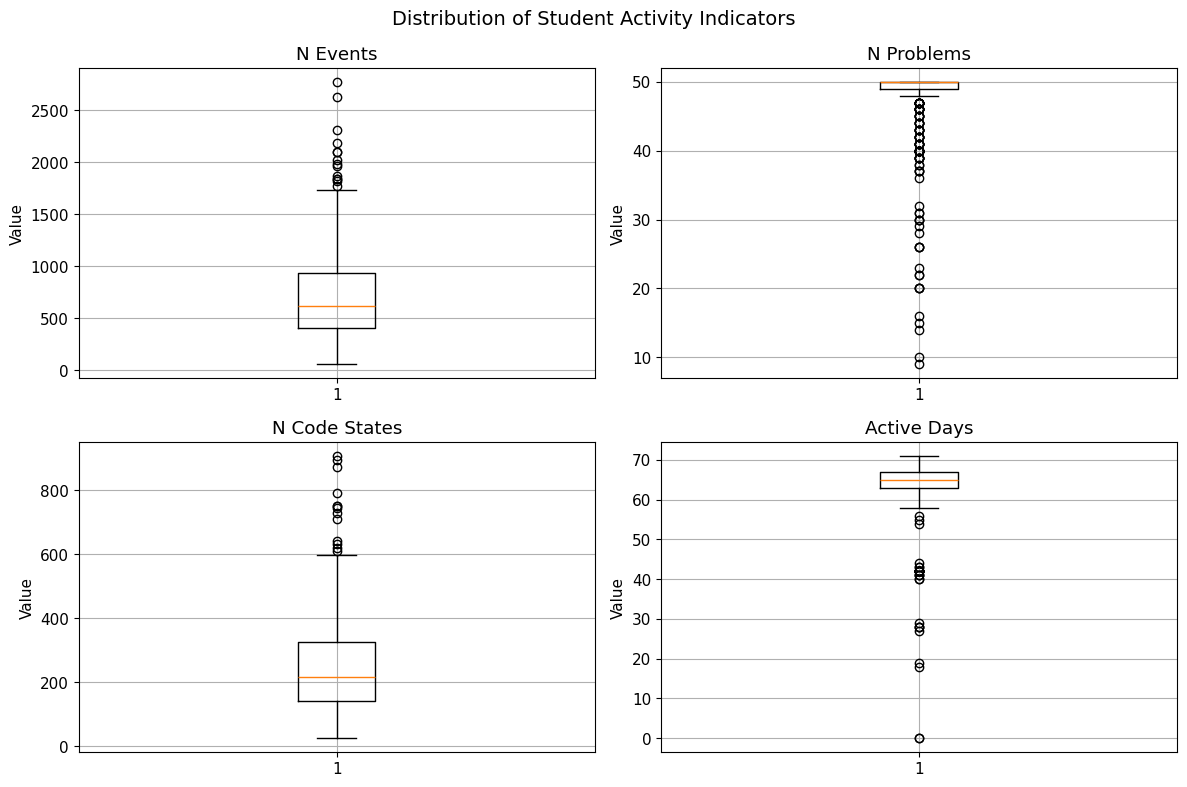

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/student_activity_boxplots.png


In [17]:
# Boxplots of student activity indicators
activity_metrics = ["n_events", "n_problems", "n_code_states", "active_days"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, metric in zip(axes, activity_metrics):
    ax.boxplot(student_activity_summary[metric].dropna(), vert=True)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_ylabel("Value")
    ax.grid(True)

plt.suptitle("Distribution of Student Activity Indicators", fontsize=14)
plt.tight_layout()

figure_path = FIGURES_DIR / "student_activity_boxplots.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved in: {figure_path}")

In [16]:
# Merge activity summary with final grades for later use
student_base = (
    subjects
    .merge(student_activity_summary, on="SubjectID", how="left")
)

print("Student-level base table:")
print(student_base.shape)

display(student_base.head())

Student-level base table:
(506, 9)


,SubjectID,X-Grade,n_events,n_assignments,n_problems,n_code_states,first_event,last_event,active_days
0,80b79645be384d8162597a76b28062cd35ea1019db9344...,48.5000,628,5,50,183,2019-09-25 20:29:21,2019-11-30 04:14:15,65
1,f2c0c481d6d6af0b83c418cd9a25d31dc1ffd303019b7c...,87.1500,548,5,50,238,2019-09-25 14:37:15,2019-12-01 23:13:33,67
2,c24802aafcbbb5d0d9f4ff58778800955e3c56280ac703...,44.0000,1564,5,50,442,2019-09-30 01:37:42,2019-12-04 01:29:59,64
3,b83f22b6c073f282fc8e9556f47e3cb0ecb74d95097383...,52.0300,792,5,50,206,2019-09-30 15:05:56,2019-12-02 19:15:50,63
4,fa57bd66cb6354a6d8af1e7b47b28589e586bf1303a908...,48.0000,438,5,50,113,2019-10-01 00:01:28,2019-12-02 20:29:30,62


### 3.2 Summary of data consistency checks

The consistency checks show that the dataset is suitable for the analysis.

First, the `Subject` table and `MainTable` contain the same 506 students. This is important because it means that all students with a final grade also have activity data in the platform. Therefore, the initial modelling population can include 506 students.

The `early` and `late` tables contain fewer students: 494 students in `early` and 490 students in `late`. These tables provide useful information about how the original dataset separates some activities into earlier and later parts of the course. However, the main temporal analysis in this notebook is rebuilt directly from the attempt-level dataset, because this gives more control over the checkpoints and keeps the same 506 students across all modelling datasets.

The target variable `X-Grade` has no missing values. The grades range from 0 to 100, with an average grade of around 60.58 and a median grade of around 61.19. This confirms that the final grade can be used as the main target variable for the regression task.

The relationship between `MainTable` and `CodeStates` is also complete. There are 125,578 unique `CodeStateID` values in both tables, and there are no code states missing from either side. This means that every code identifier used in the event log can be linked to the actual code written by the student.

The event ordering is fully consistent, with 100% of events marked as correctly ordered. This is important because the project studies learning trajectories over time, so the temporal order of events must be reliable.

The timestamp analysis shows that the data covers 72 days, from 23 September 2019 to 5 December 2019. This provides a clear time window for analysing student activity and for building temporal checkpoints later in the notebook.

Finally, the student-level activity summary shows that students differ in their level of engagement. On average, each student has around 712 events, works on almost 5 assignments, solves or attempts around 47 problems, and generates around 248 code states. This variation is useful for predictive modelling because it reflects different learning behaviours across students.

Overall, these checks confirm that the main datasets are consistent and can be combined to build the final student-level modelling dataset.

## 4. Target definition and prediction tasks

This section defines the prediction targets used in the project.

The main target variable is `X-Grade`, which represents the final student grade on a scale from 0 to 100. This variable is used for the regression task.

In addition, a binary target is created to define a classification task. Students with a final grade greater than or equal to 60 are considered as passing students, while students below this threshold are considered as non-passing students.

Using both tasks allows the project to analyse student performance from two perspectives:

- A **regression perspective**, where the goal is to predict the final numerical grade.
- A **classification perspective**, where the goal is to identify whether a student is likely to pass or fail.

This distinction is useful because both types of prediction can support educational decision-making. Regression gives a more detailed estimation of performance, while classification provides a simpler risk indicator.

An important methodological point is that final course information can make prediction easier, especially when some variables are very close to the final grade. For this reason, this notebook will not only evaluate models at the final point, but will also analyse performance across different moments of the learning trajectory.

In [18]:
# Define prediction targets
REGRESSION_TARGET = "X-Grade"
PASS_THRESHOLD = 60
CLASSIFICATION_TARGET = "Pass"

# Create target table
student_targets = subjects.copy()

student_targets[CLASSIFICATION_TARGET] = (
    student_targets[REGRESSION_TARGET] >= PASS_THRESHOLD
).astype(int)

# Add target to the student-level base table
student_base = student_base.merge(
    student_targets[["SubjectID", CLASSIFICATION_TARGET]],
    on="SubjectID",
    how="left"
)

print("Targets created successfully.")
print(f"Regression target: {REGRESSION_TARGET}")
print(f"Classification target: {CLASSIFICATION_TARGET}")
print(f"Pass threshold: X-Grade >= {PASS_THRESHOLD}")

Targets created successfully.
Regression target: X-Grade
Classification target: Pass
Pass threshold: X-Grade >= 60


In [19]:
# Summary of the regression target
grade_summary = student_targets[REGRESSION_TARGET].describe().to_frame(name="X-Grade summary")
grade_summary

,X-Grade summary
count,506.0000
mean,60.5773
std,19.8857
min,0.0000
25%,48.4325
50%,61.1900
75%,75.1575
max,100.0000


In [20]:
# Summary of the classification target
pass_fail_summary = (
    student_targets[CLASSIFICATION_TARGET]
    .value_counts()
    .rename(index={0: "Fail", 1: "Pass"})
    .reset_index()
)

pass_fail_summary.columns = ["class", "n_students"]
pass_fail_summary["percentage"] = pass_fail_summary["n_students"] / len(student_targets) * 100

pass_fail_summary

,class,n_students,percentage
0,Pass,264,52.1739
1,Fail,242,47.8261


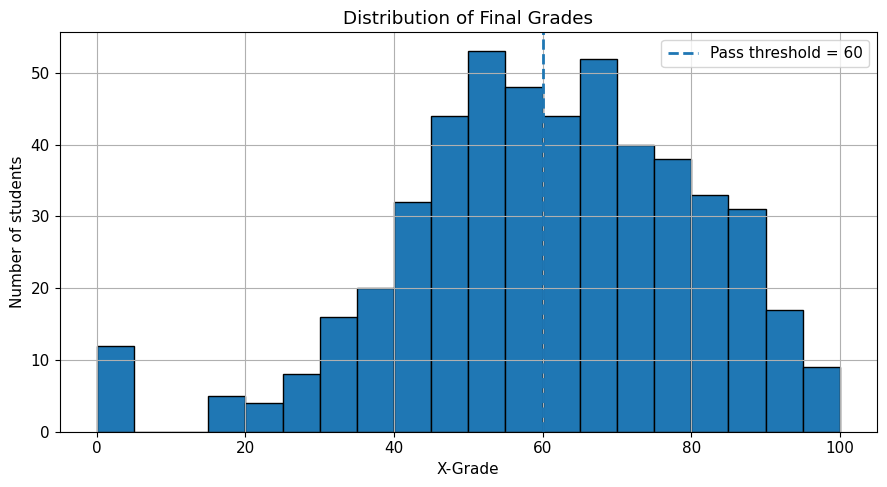

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/target_grade_distribution.png


In [21]:
# Distribution of final grades
plt.figure(figsize=(9, 5))

plt.hist(student_targets[REGRESSION_TARGET], bins=20, edgecolor="black")
plt.axvline(PASS_THRESHOLD, linestyle="--", linewidth=2, label=f"Pass threshold = {PASS_THRESHOLD}")

plt.title("Distribution of Final Grades")
plt.xlabel("X-Grade")
plt.ylabel("Number of students")
plt.legend()
plt.grid(True)
plt.tight_layout()

figure_path = FIGURES_DIR / "target_grade_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

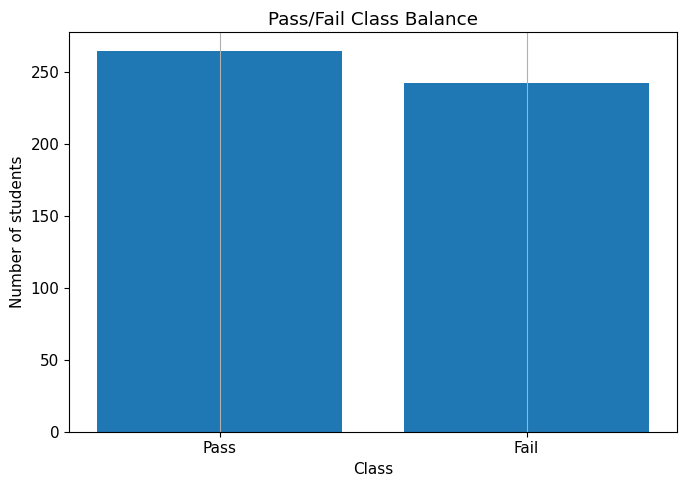

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/target_pass_fail_balance.png


In [22]:
# Class balance for the pass/fail target
plt.figure(figsize=(7, 5))

plt.bar(pass_fail_summary["class"], pass_fail_summary["n_students"])

plt.title("Pass/Fail Class Balance")
plt.xlabel("Class")
plt.ylabel("Number of students")
plt.grid(axis="y")
plt.tight_layout()

figure_path = FIGURES_DIR / "target_pass_fail_balance.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

## 5. Building the attempt-level dataset

The original `MainTable` is an event-level table. This means that each row represents one action in the platform, such as running a program, compiling code, or receiving a compile error.

For the analysis, it is useful to build an intermediate dataset at attempt level. In this dataset, each row represents one attempt made by a student on a specific programming problem.

In this project, an attempt is defined as a `Run.Program` event. This type of event is especially useful because it is associated with a score and a specific `CodeStateID`. Therefore, each attempt can be linked to the code written by the student at that moment.

The attempt-level dataset will be used later to create student-level features, such as number of attempts, solved problems, average score, code evolution, and semantic features extracted from code.

In [23]:
# Create a clean copy of the event log
events = main.copy()

# Make sure timestamps are available as datetime
if "ServerTimestamp_dt" not in events.columns:
    events["ServerTimestamp_dt"] = pd.to_datetime(events["ServerTimestamp"], errors="coerce")

# Define attempts as Run.Program events
attempts = events[events["EventType"] == "Run.Program"].copy()

# Sort attempts in temporal order
attempts = attempts.sort_values(
    ["SubjectID", "AssignmentID", "ProblemID", "ServerTimestamp_dt", "Order", "EventID"]
).reset_index(drop=True)

# Create problem identifier
attempts["ProblemKey"] = (
    attempts["AssignmentID"].astype(str) + "_" + attempts["ProblemID"].astype(str)
)

# Attempt order within each student-problem pair
attempts["attempt_number_problem"] = (
    attempts
    .groupby(["SubjectID", "AssignmentID", "ProblemID"])
    .cumcount() + 1
)

# Attempt order within each student
attempts["attempt_number_student"] = (
    attempts
    .groupby("SubjectID")
    .cumcount() + 1
)

# Binary indicator of correct attempt
attempts["is_correct_attempt"] = (attempts["Score"] >= 1).astype(int)

print("Attempt-level dataset created.")
print(f"Number of attempts: {len(attempts)}")
print(f"Number of students: {attempts['SubjectID'].nunique()}")
print(f"Number of problems: {attempts['ProblemKey'].nunique()}")

Attempt-level dataset created.
Number of attempts: 125578
Number of students: 506
Number of problems: 50


In [24]:
# Add compile information linked to each Run.Program event
compile_events = events[events["EventType"] == "Compile"].copy()

compile_summary = (
    compile_events
    .groupby("ParentEventID")
    .agg(
        n_compile_events=("EventID", "count"),
        n_compile_success=("Compile.Result", lambda x: (x == "Success").sum()),
        n_compile_errors=("Compile.Result", lambda x: (x == "Error").sum())
    )
    .reset_index()
    .rename(columns={"ParentEventID": "EventID"})
)

attempts = attempts.merge(
    compile_summary,
    on="EventID",
    how="left"
)

# Fill missing compile information with zero
compile_cols = ["n_compile_events", "n_compile_success", "n_compile_errors"]
attempts[compile_cols] = attempts[compile_cols].fillna(0).astype(int)

display(attempts[[
    "SubjectID", "AssignmentID", "ProblemID", "ProblemKey",
    "EventID", "Score", "is_correct_attempt",
    "attempt_number_problem", "attempt_number_student",
    "n_compile_events", "n_compile_success", "n_compile_errors"
]].head())

,SubjectID,AssignmentID,ProblemID,ProblemKey,EventID,Score,is_correct_attempt,attempt_number_problem,attempt_number_student,n_compile_events,n_compile_success,n_compile_errors
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,1.0000,1,1,1,1,1,0
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,3,439_3,11163,0.0000,0,1,2,1,0,1
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,3,439_3,11166,0.6250,0,2,3,1,1,0
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,3,439_3,11168,0.7500,0,3,4,1,1,0
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,3,439_3,11170,1.0000,1,4,5,1,1,0


In [25]:
# Link each attempt with the actual code
attempts = attempts.merge(
    code_states,
    on="CodeStateID",
    how="left"
)

attempts["code_available"] = attempts["Code"].notna().astype(int)

code_link_summary = pd.DataFrame({
    "metric": [
        "number_of_attempts",
        "attempts_with_code",
        "attempts_without_code",
        "percentage_with_code"
    ],
    "value": [
        len(attempts),
        attempts["code_available"].sum(),
        (attempts["code_available"] == 0).sum(),
        attempts["code_available"].mean() * 100
    ]
})

code_link_summary

,metric,value
0,number_of_attempts,125578.0000
1,attempts_with_code,125571.0000
2,attempts_without_code,7.0000
3,percentage_with_code,99.9944


In [26]:
# Summary of the attempt-level dataset
attempt_summary = pd.DataFrame({
    "metric": [
        "students",
        "attempts",
        "assignments",
        "problems",
        "unique_code_states",
        "mean_attempts_per_student",
        "mean_attempts_per_problem_student",
        "mean_score",
        "correct_attempt_rate"
    ],
    "value": [
        attempts["SubjectID"].nunique(),
        len(attempts),
        attempts["AssignmentID"].nunique(),
        attempts["ProblemKey"].nunique(),
        attempts["CodeStateID"].nunique(),
        attempts.groupby("SubjectID").size().mean(),
        attempts.groupby(["SubjectID", "ProblemKey"]).size().mean(),
        attempts["Score"].mean(),
        attempts["is_correct_attempt"].mean()
    ]
})

attempt_summary

,metric,value
0,students,506.0000
1,attempts,125578.0000
2,assignments,5.0000
3,problems,50.0000
4,unique_code_states,125578.0000
5,mean_attempts_per_student,248.1779
6,mean_attempts_per_problem_student,5.2254
7,mean_score,0.3971
8,correct_attempt_rate,0.1965


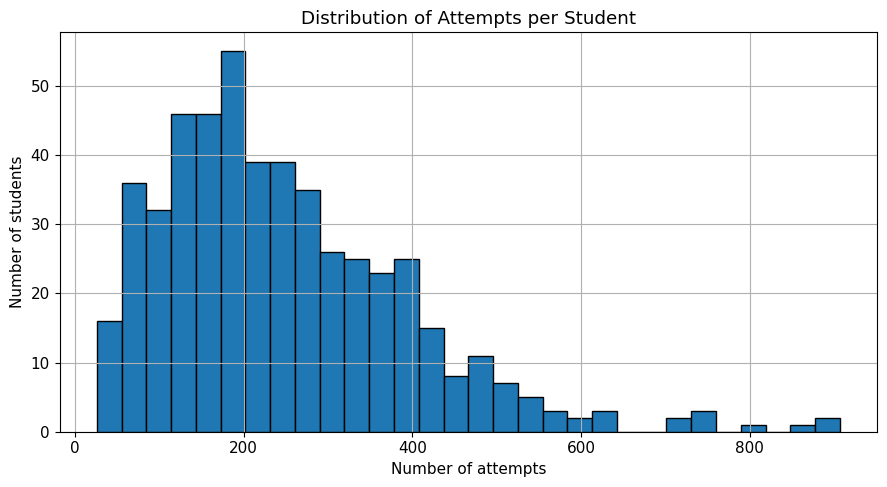

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/attempts_per_student_distribution.png


In [27]:
# Distribution of attempts per student
attempts_per_student = (
    attempts
    .groupby("SubjectID")
    .size()
    .reset_index(name="n_attempts")
)

plt.figure(figsize=(9, 5))

plt.hist(attempts_per_student["n_attempts"], bins=30, edgecolor="black")

plt.title("Distribution of Attempts per Student")
plt.xlabel("Number of attempts")
plt.ylabel("Number of students")
plt.grid(True)
plt.tight_layout()

figure_path = FIGURES_DIR / "attempts_per_student_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

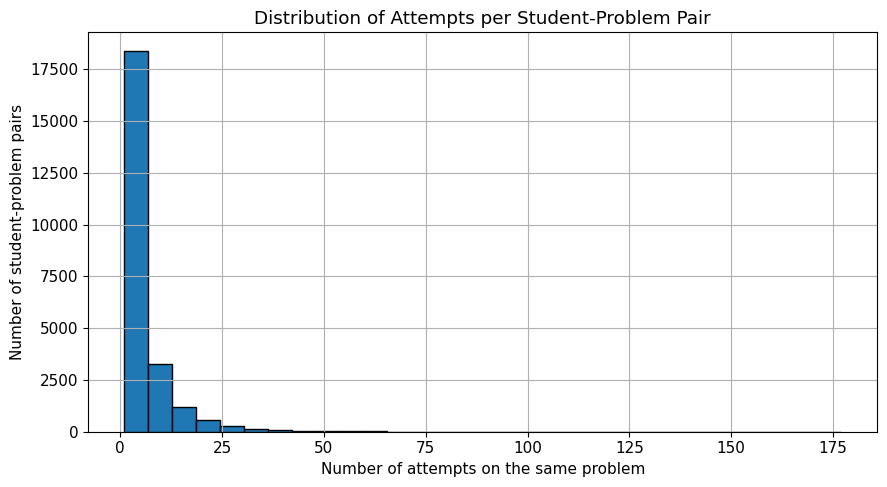

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/attempts_per_student_problem_distribution.png


In [28]:
# Distribution of attempts per student-problem pair
attempts_per_student_problem = (
    attempts
    .groupby(["SubjectID", "ProblemKey"])
    .size()
    .reset_index(name="n_attempts_problem")
)

plt.figure(figsize=(9, 5))

plt.hist(attempts_per_student_problem["n_attempts_problem"], bins=30, edgecolor="black")

plt.title("Distribution of Attempts per Student-Problem Pair")
plt.xlabel("Number of attempts on the same problem")
plt.ylabel("Number of student-problem pairs")
plt.grid(True)
plt.tight_layout()

figure_path = FIGURES_DIR / "attempts_per_student_problem_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

In [29]:
# Save a lightweight version without the full code text
attempts_no_code = attempts.drop(columns=["Code"], errors="ignore")

attempts_path = TABLES_DIR / "attempt_level_dataset.csv"
attempts_no_code.to_csv(attempts_path, index=False)

print(f"Attempt-level dataset saved in: {attempts_path}")
print(f"Shape: {attempts_no_code.shape}")

Attempt-level dataset saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/attempt_level_dataset.csv
Shape: (125578, 26)


## 6. Traditional Learning Analytics and structural code feature engineering

This section creates the main student-level feature tables used in the modelling stage.

First, traditional Learning Analytics features are extracted from the attempt-level dataset. These variables describe how each student interacted with the programming platform and are grouped into five blocks:

1. **Problem performance features**: solved problems, attempts per problem, first scores, best scores and improvement.
2. **Activity and attempt features**: amount of work, number of attempts, scores and active period.
3. **Compilation behaviour features**: successful and failed compilations.
4. **Temporal phase features**: changes between early, middle and late parts of the student trajectory.
5. **Regularity and inactivity features**: time gaps between consecutive attempts.

After this traditional baseline, **simple structural code features** are also extracted. These features describe measurable properties of the code, such as lines, loops, conditionals, returns and operators. They are not generated by an LLM, but they provide an intermediate comparison between traditional platform data and LLM-based semantic features.

### 6.1 Problem performance features

In [30]:
# Problem-level summary for each student
student_problem_summary = (
    attempts
    .groupby(["SubjectID", "ProblemKey"])
    .agg(
        n_attempts_problem=("EventID", "count"),
        first_score_problem=("Score", "first"),
        last_score_problem=("Score", "last"),
        best_score_problem=("Score", "max"),
        solved_problem=("is_correct_attempt", "max"),
        first_attempt_correct_problem=("is_correct_attempt", "first")
    )
    .reset_index()
)

student_problem_summary["score_improvement_problem"] = (
    student_problem_summary["last_score_problem"] 
    - student_problem_summary["first_score_problem"]
)

display(student_problem_summary.head())

,SubjectID,ProblemKey,n_attempts_problem,first_score_problem,last_score_problem,best_score_problem,solved_problem,first_attempt_correct_problem,score_improvement_problem
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439_1,1,1.0000,1.0000,1.0000,1,1,0.0000
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439_12,1,1.0000,1.0000,1.0000,1,1,0.0000
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439_13,6,0.0000,1.0000,1.0000,1,0,1.0000
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439_232,3,0.0000,1.0000,1.0000,1,0,1.0000
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439_233,7,0.0000,1.0000,1.0000,1,0,1.0000


In [31]:
# Aggregate problem-level indicators at student level
problem_features = (
    student_problem_summary
    .groupby("SubjectID")
    .agg(
        n_problems_attempted=("ProblemKey", "nunique"),
        n_solved_problems=("solved_problem", "sum"),
        mean_attempts_per_problem=("n_attempts_problem", "mean"),
        median_attempts_per_problem=("n_attempts_problem", "median"),
        max_attempts_single_problem=("n_attempts_problem", "max"),
        mean_first_score_problem=("first_score_problem", "mean"),
        mean_last_score_problem=("last_score_problem", "mean"),
        mean_best_score_problem=("best_score_problem", "mean"),
        mean_score_improvement_problem=("score_improvement_problem", "mean"),
        n_first_attempt_correct=("first_attempt_correct_problem", "sum")
    )
    .reset_index()
)

problem_features["solve_rate"] = (
    problem_features["n_solved_problems"] / problem_features["n_problems_attempted"]
)

problem_features["first_attempt_correct_rate"] = (
    problem_features["n_first_attempt_correct"] / problem_features["n_problems_attempted"]
)

display(problem_features.head())

,SubjectID,n_problems_attempted,n_solved_problems,mean_attempts_per_problem,median_attempts_per_problem,max_attempts_single_problem,mean_first_score_problem,mean_last_score_problem,mean_best_score_problem,mean_score_improvement_problem,n_first_attempt_correct,solve_rate,first_attempt_correct_rate
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,50,50,4.9600,3.0000,39,0.3483,1.0000,1.0000,0.6517,11,1.0000,0.2200
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,50,49,5.6200,3.0000,27,0.3914,0.9543,0.9943,0.5629,14,0.9800,0.2800
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,31,20,5.3548,4.0000,19,0.2985,0.8666,0.8789,0.5681,7,0.6452,0.2258
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,50,48,7.2000,4.0000,45,0.4283,0.9934,0.9934,0.5650,10,0.9600,0.2000
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,49,42,8.0612,6.0000,36,0.3024,0.9434,0.9531,0.6410,5,0.8571,0.1020


### 6.2 Attempt-level activity features

In [32]:
# Course-level reference dates
course_start = attempts["ServerTimestamp_dt"].min()

# Aggregate attempt-level indicators at student level
attempt_features = (
    attempts
    .groupby("SubjectID")
    .agg(
        n_attempts=("EventID", "count"),
        n_assignments_attempted=("AssignmentID", "nunique"),
        n_code_states_attempts=("CodeStateID", "nunique"),
        mean_score_attempt=("Score", "mean"),
        median_score_attempt=("Score", "median"),
        std_score_attempt=("Score", "std"),
        min_score_attempt=("Score", "min"),
        max_score_attempt=("Score", "max"),
        n_correct_attempts=("is_correct_attempt", "sum"),
        first_attempt_time=("ServerTimestamp_dt", "min"),
        last_attempt_time=("ServerTimestamp_dt", "max")
    )
    .reset_index()
)

attempt_features["correct_attempt_rate"] = (
    attempt_features["n_correct_attempts"] / attempt_features["n_attempts"]
)

attempt_features["active_days_attempts"] = (
    attempt_features["last_attempt_time"] - attempt_features["first_attempt_time"]
).dt.days

attempt_features["first_attempt_day_from_start"] = (
    attempt_features["first_attempt_time"] - course_start
).dt.total_seconds() / (24 * 3600)

attempt_features["last_attempt_day_from_start"] = (
    attempt_features["last_attempt_time"] - course_start
).dt.total_seconds() / (24 * 3600)

attempt_features["attempts_per_active_day"] = (
    attempt_features["n_attempts"] / (attempt_features["active_days_attempts"] + 1)
)

# Raw timestamps are not used as model features
attempt_features = attempt_features.drop(
    columns=["first_attempt_time", "last_attempt_time"]
)

display(attempt_features.head())

,SubjectID,n_attempts,n_assignments_attempted,n_code_states_attempts,mean_score_attempt,median_score_attempt,std_score_attempt,min_score_attempt,max_score_attempt,n_correct_attempts,correct_attempt_rate,active_days_attempts,first_attempt_day_from_start,last_attempt_day_from_start,attempts_per_active_day
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,248,5,248,0.3606,0.0250,0.4243,0.0000,1.0000,54,0.2177,66,3.8433,70.2742,3.7015
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,281,5,281,0.4025,0.2632,0.4199,0.0000,1.0000,53,0.1886,63,7.0963,70.1915,4.3906
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,166,5,166,0.3845,0.4000,0.3726,0.0000,1.0000,22,0.1325,66,3.5906,70.0030,2.4776
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,360,5,360,0.4359,0.3485,0.4048,0.0000,1.0000,67,0.1861,67,4.4393,72.0297,5.2941
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,395,5,395,0.4275,0.4000,0.3723,0.0000,1.0000,43,0.1089,69,2.0103,71.9602,5.6429


### 6.3 Compilation behaviour features

In [33]:
# Compilation indicators at student level
compile_features = (
    attempts
    .groupby("SubjectID")
    .agg(
        n_compile_events_total=("n_compile_events", "sum"),
        n_compile_success_total=("n_compile_success", "sum"),
        n_compile_errors_total=("n_compile_errors", "sum")
    )
    .reset_index()
)

compile_features["compile_success_rate"] = np.where(
    compile_features["n_compile_events_total"] > 0,
    compile_features["n_compile_success_total"] / compile_features["n_compile_events_total"],
    0
)

compile_features["compile_error_rate"] = np.where(
    compile_features["n_compile_events_total"] > 0,
    compile_features["n_compile_errors_total"] / compile_features["n_compile_events_total"],
    0
)

display(compile_features.head())

,SubjectID,n_compile_events_total,n_compile_success_total,n_compile_errors_total,compile_success_rate,compile_error_rate
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,248,126,122,0.5081,0.4919
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,281,196,85,0.6975,0.3025
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,166,105,61,0.6325,0.3675
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,360,243,117,0.6750,0.3250
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,395,293,102,0.7418,0.2582


### 6.4 Temporal behaviour features

In addition to total activity, it is useful to describe how student behaviour changes over time.

For this purpose, each student trajectory is divided into three phases according to their own sequence of attempts:

- `early`: first third of the student’s attempts.
- `middle`: second third of the student’s attempts.
- `late`: final third of the student’s attempts.

This allows us to compare early and late performance, and to capture whether students improve, decline, or remain stable during the course.

In [34]:
# Create relative progress position inside each student trajectory
attempts = attempts.sort_values(
    ["SubjectID", "ServerTimestamp_dt", "Order", "EventID"]
).reset_index(drop=True)

attempts["n_attempts_student"] = attempts.groupby("SubjectID")["EventID"].transform("count")

attempts["attempt_progress"] = np.where(
    attempts["n_attempts_student"] > 1,
    (attempts["attempt_number_student"] - 1) / (attempts["n_attempts_student"] - 1),
    1
)

# Assign each attempt to a trajectory phase
conditions = [
    attempts["attempt_progress"] <= 1/3,
    attempts["attempt_progress"] <= 2/3
]

choices = ["early", "middle"]

attempts["trajectory_phase"] = np.select(
    conditions,
    choices,
    default="late"
)

attempts["trajectory_phase"].value_counts()

trajectory_phase
early     42029
late      41859
middle    41690
Name: count, dtype: int64

In [35]:
# Aggregate performance by trajectory phase
phase_features_long = (
    attempts
    .groupby(["SubjectID", "trajectory_phase"])
    .agg(
        phase_n_attempts=("EventID", "count"),
        phase_mean_score=("Score", "mean"),
        phase_correct_rate=("is_correct_attempt", "mean")
    )
    .reset_index()
)

phase_features = phase_features_long.pivot(
    index="SubjectID",
    columns="trajectory_phase"
)

phase_features.columns = [
    f"{metric}_{phase}"
    for metric, phase in phase_features.columns
]

phase_features = phase_features.reset_index()

# Ensure all expected phase columns exist
expected_phase_cols = [
    "phase_n_attempts_early", "phase_n_attempts_middle", "phase_n_attempts_late",
    "phase_mean_score_early", "phase_mean_score_middle", "phase_mean_score_late",
    "phase_correct_rate_early", "phase_correct_rate_middle", "phase_correct_rate_late"
]

for col in expected_phase_cols:
    if col not in phase_features.columns:
        phase_features[col] = 0

# Change from early to late phase
phase_features["score_change_late_early"] = (
    phase_features["phase_mean_score_late"] 
    - phase_features["phase_mean_score_early"]
)

phase_features["correct_rate_change_late_early"] = (
    phase_features["phase_correct_rate_late"] 
    - phase_features["phase_correct_rate_early"]
)

phase_features["attempts_change_late_early"] = (
    phase_features["phase_n_attempts_late"] 
    - phase_features["phase_n_attempts_early"]
)

display(phase_features.head())

,SubjectID,phase_n_attempts_early,phase_n_attempts_late,phase_n_attempts_middle,phase_mean_score_early,phase_mean_score_late,phase_mean_score_middle,phase_correct_rate_early,phase_correct_rate_late,phase_correct_rate_middle,score_change_late_early,correct_rate_change_late_early,attempts_change_late_early
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,83,83,82,0.3675,0.4227,0.2906,0.2771,0.2410,0.1341,0.0552,-0.0361,0
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,94,94,93,0.4061,0.4671,0.3335,0.2553,0.1596,0.1505,0.0610,-0.0957,0
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,56,55,55,0.5295,0.3606,0.2609,0.2679,0.0364,0.0909,-0.1689,-0.2315,-1
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,120,120,120,0.4633,0.4860,0.3584,0.1917,0.1750,0.1917,0.0227,-0.0167,0
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,132,132,131,0.4272,0.3528,0.5032,0.1515,0.0758,0.0992,-0.0744,-0.0758,0


### 6.5 Regularity and inactivity features

In [36]:
# Time gaps between consecutive attempts
attempts = attempts.sort_values(
    ["SubjectID", "ServerTimestamp_dt", "Order", "EventID"]
).reset_index(drop=True)

attempts["gap_hours"] = (
    attempts
    .groupby("SubjectID")["ServerTimestamp_dt"]
    .diff()
    .dt.total_seconds() / 3600
)

gap_features = (
    attempts
    .groupby("SubjectID")
    .agg(
        mean_gap_hours=("gap_hours", "mean"),
        median_gap_hours=("gap_hours", "median"),
        max_gap_hours=("gap_hours", "max"),
        n_large_gaps_24h=("gap_hours", lambda x: (x > 24).sum()),
        n_large_gaps_72h=("gap_hours", lambda x: (x > 72).sum())
    )
    .reset_index()
)

gap_features = gap_features.fillna(0)

display(gap_features.head())

,SubjectID,mean_gap_hours,median_gap_hours,max_gap_hours,n_large_gaps_24h,n_large_gaps_72h
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,6.4548,0.0197,572.8433,7,5
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,5.4082,0.0125,511.7353,4,4
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,9.6600,0.0119,490.3881,4,4
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,4.5186,0.0136,444.8961,9,5
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,4.2609,0.0219,460.1892,11,6


### 6.6 Final traditional LA feature table

In [37]:
# Merge all traditional Learning Analytics features
student_la_features = (
    student_targets
    .merge(attempt_features, on="SubjectID", how="left")
    .merge(problem_features, on="SubjectID", how="left")
    .merge(compile_features, on="SubjectID", how="left")
    .merge(phase_features, on="SubjectID", how="left")
    .merge(gap_features, on="SubjectID", how="left")
)

# Fill possible missing values
numeric_cols = student_la_features.select_dtypes(include=[np.number]).columns
student_la_features[numeric_cols] = student_la_features[numeric_cols].fillna(0)

print("Traditional LA feature table created.")
print(f"Shape: {student_la_features.shape}")

display(student_la_features.head())

Traditional LA feature table created.
Shape: (506, 51)


,SubjectID,X-Grade,Pass,n_attempts,n_assignments_attempted,n_code_states_attempts,mean_score_attempt,median_score_attempt,std_score_attempt,min_score_attempt,max_score_attempt,n_correct_attempts,correct_attempt_rate,active_days_attempts,first_attempt_day_from_start,last_attempt_day_from_start,attempts_per_active_day,n_problems_attempted,n_solved_problems,mean_attempts_per_problem,median_attempts_per_problem,max_attempts_single_problem,mean_first_score_problem,mean_last_score_problem,mean_best_score_problem,mean_score_improvement_problem,n_first_attempt_correct,solve_rate,first_attempt_correct_rate,n_compile_events_total,n_compile_success_total,n_compile_errors_total,compile_success_rate,compile_error_rate,phase_n_attempts_early,phase_n_attempts_late,phase_n_attempts_middle,phase_mean_score_early,phase_mean_score_late,phase_mean_score_middle,phase_correct_rate_early,phase_correct_rate_late,phase_correct_rate_middle,score_change_late_early,correct_rate_change_late_early,attempts_change_late_early,mean_gap_hours,median_gap_hours,max_gap_hours,n_large_gaps_24h,n_large_gaps_72h
0,80b79645be384d8162597a76b28062cd35ea1019db9344...,48.5000,0,183,5,183,0.4169,0.2143,0.4490,0.0000,1.0000,50,0.2732,65,2.2185,67.5413,2.7727,50,49,3.6600,2.0000,21,0.4781,0.9960,0.9960,0.5179,20,0.9800,0.4000,183,93,90,0.5082,0.4918,61,61,61,0.3811,0.5137,0.3558,0.1639,0.4426,0.2131,0.1326,0.2787,0,8.6140,0.0160,554.5617,5,5
1,f2c0c481d6d6af0b83c418cd9a25d31dc1ffd303019b7c...,87.1500,1,238,5,238,0.4957,0.5298,0.4027,0.0000,1.0000,56,0.2353,67,1.9740,69.3325,3.5000,50,50,4.7600,3.0000,21,0.3805,1.0000,1.0000,0.6195,10,1.0000,0.2000,238,187,51,0.7857,0.2143,80,79,79,0.5325,0.5467,0.4073,0.2625,0.2532,0.1899,0.0142,-0.0093,-1,6.8211,0.0272,509.2167,11,7
2,c24802aafcbbb5d0d9f4ff58778800955e3c56280ac703...,44.0000,0,442,5,442,0.2552,0.0000,0.3753,0.0000,1.0000,51,0.1154,64,6.4326,71.4273,6.8000,50,46,8.8400,7.0000,27,0.2452,0.9517,0.9517,0.7065,4,0.9200,0.0800,442,172,270,0.3891,0.6109,148,147,147,0.2476,0.2974,0.2206,0.0946,0.1429,0.1088,0.0498,0.0483,-1,3.5371,0.0089,528.1456,7,6
3,b83f22b6c073f282fc8e9556f47e3cb0ecb74d95097383...,52.0300,0,206,5,206,0.3838,0.0000,0.4529,0.0000,1.0000,58,0.2816,63,6.9939,70.1674,3.2188,50,50,4.1200,2.0000,30,0.3657,1.0000,1.0000,0.6343,14,1.0000,0.2800,206,94,112,0.4563,0.5437,69,69,68,0.1611,0.5460,0.4453,0.0725,0.4638,0.3088,0.3849,0.3913,0,7.3959,0.0108,504.5256,6,5
4,fa57bd66cb6354a6d8af1e7b47b28589e586bf1303a908...,48.0000,0,113,5,113,0.4639,0.0000,0.4879,0.0000,1.0000,49,0.4336,62,7.3658,70.2186,1.7937,50,49,2.2600,1.0000,22,0.6613,0.9925,0.9925,0.3312,32,0.9800,0.6400,113,57,56,0.5044,0.4956,38,38,37,0.4211,0.5954,0.3730,0.4211,0.5789,0.2973,0.1743,0.1579,0,13.4685,0.0079,505.3311,5,5


In [38]:
# Feature groups created in this section
target_cols = ["SubjectID", REGRESSION_TARGET, CLASSIFICATION_TARGET]

traditional_la_feature_cols = [
    col for col in student_la_features.columns
    if col not in target_cols
]

feature_group_summary = pd.DataFrame({
    "feature_group": [
        "Activity and attempt features",
        "Problem performance features",
        "Compilation behaviour features",
        "Temporal phase features",
        "Regularity and inactivity features",
        "Total traditional LA features"
    ],
    "n_features": [
        len([c for c in traditional_la_feature_cols if c in attempt_features.columns]),
        len([c for c in traditional_la_feature_cols if c in problem_features.columns]),
        len([c for c in traditional_la_feature_cols if c in compile_features.columns]),
        len([c for c in traditional_la_feature_cols if c in phase_features.columns]),
        len([c for c in traditional_la_feature_cols if c in gap_features.columns]),
        len(traditional_la_feature_cols)
    ]
})

feature_group_summary

,feature_group,n_features
0,Activity and attempt features,14
1,Problem performance features,12
2,Compilation behaviour features,5
3,Temporal phase features,12
4,Regularity and inactivity features,5
5,Total traditional LA features,48


In [39]:
# Check missing values in the final feature table
missing_summary = (
    student_la_features
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["column", "missing_values"]
missing_summary = missing_summary[missing_summary["missing_values"] > 0]

if missing_summary.empty:
    print("No missing values in the traditional LA feature table.")
else:
    display(missing_summary)

No missing values in the traditional LA feature table.


In [40]:
# Save traditional LA features
la_features_path = TABLES_DIR / "student_traditional_la_features.csv"
student_la_features.to_csv(la_features_path, index=False)

print(f"Traditional LA features saved in: {la_features_path}")
print(f"Shape: {student_la_features.shape}")

Traditional LA features saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/student_traditional_la_features.csv
Shape: (506, 51)


### 6.7 Structural code features

In addition to traditional Learning Analytics features, this section extracts simple structural features from the students’ code submissions.

These features do not use an LLM. They are based only on surface-level properties of the code, such as the number of lines, conditionals, loops, return statements, operators, semicolons, comments, and basic code structure.

This block is useful because it creates an intermediate comparison point between traditional Learning Analytics variables and LLM-based semantic features.

The main distinction is the following:

- Traditional Learning Analytics features describe student activity and performance.
- Structural code features describe simple measurable properties of the code.
- LLM-based semantic features describe qualitative aspects of the code, such as readability, completeness, logic, and overall quality.

Including this block makes the analysis more robust because it allows us to test whether LLM features add value beyond both traditional activity data and simple code structure indicators.

In [81]:
# Make sure attempts has the Code column
if "Code" not in attempts.columns:
    attempts = attempts.merge(
        code_states,
        on="CodeStateID",
        how="left"
    )

# Keep attempts with available code
attempts_code = attempts[
    attempts["Code"].notna() &
    (attempts["Code"].astype(str).str.strip().str.len() > 0)
].copy()

print("Attempts with code available:", attempts_code.shape)
print("Students:", attempts_code["SubjectID"].nunique())

Attempts with code available: (125568, 31)
Students: 506


In [82]:
def extract_structural_code_features(code):
    """Extract simple structural features from a code submission."""
    
    code = str(code)
    lines = code.splitlines()
    non_empty_lines = [line for line in lines if line.strip()]
    
    feature_dict = {
        "code_chars": len(code),
        "code_lines": len(lines),
        "code_non_empty_lines": len(non_empty_lines),
        "code_avg_line_length": len(code) / max(len(non_empty_lines), 1),
        "code_n_if": len(re.findall(r"\bif\b", code)),
        "code_n_else": len(re.findall(r"\belse\b", code)),
        "code_n_for": len(re.findall(r"\bfor\b", code)),
        "code_n_while": len(re.findall(r"\bwhile\b", code)),
        "code_n_return": len(re.findall(r"\breturn\b", code)),
        "code_n_boolean_ops": len(re.findall(r"&&|\|\|", code)),
        "code_n_comparison_ops": len(re.findall(r"==|!=|<=|>=|<|>", code)),
        "code_n_assignments": len(re.findall(r"(?<![=!<>])=(?!=)", code)),
        "code_n_semicolons": code.count(";"),
        "code_has_comment": int(bool(re.search(r"//|/\*", code))),
        "code_has_loop": int(bool(re.search(r"\bfor\b|\bwhile\b", code))),
        "code_has_conditional": int(bool(re.search(r"\bif\b|\belse\b", code))),
        "code_brace_balance": abs(code.count("{") - code.count("}"))
    }
    
    feature_dict["code_n_loops"] = (
        feature_dict["code_n_for"] + feature_dict["code_n_while"]
    )
    
    return feature_dict

In [83]:
# Extract structural features for each attempt with code
structural_feature_rows = []

for _, row in attempts_code.iterrows():
    features = extract_structural_code_features(row["Code"])
    
    features.update({
        "SubjectID": row["SubjectID"],
        "CodeStateID": row["CodeStateID"],
        "EventID": row["EventID"],
        "attempt_number_student": row["attempt_number_student"]
    })
    
    structural_feature_rows.append(features)

attempt_structural_features = pd.DataFrame(structural_feature_rows)

print("Attempt-level structural code features created.")
print(attempt_structural_features.shape)

display(attempt_structural_features.head())

Attempt-level structural code features created.
(125568, 22)


,code_chars,code_lines,code_non_empty_lines,code_avg_line_length,code_n_if,code_n_else,code_n_for,code_n_while,code_n_return,code_n_boolean_ops,code_n_comparison_ops,code_n_assignments,code_n_semicolons,code_has_comment,code_has_loop,code_has_conditional,code_brace_balance,code_n_loops,SubjectID,CodeStateID,EventID,attempt_number_student
0,507,35,34,14.9118,5,5,0,0,6,0,4,0,0,0,0,1,0,0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,c98c36c2a74450ef194ef128cfa47054cad949b10c105b...,11000,10
1,523,35,34,15.3824,5,5,0,0,6,0,4,0,6,0,0,1,0,0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,51b7a4c64742d1ea442c0bd2ffff15ba8d98bb656765e0...,11019,11
2,529,35,34,15.5588,5,5,0,0,6,0,4,0,12,0,0,1,0,0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,1302138ef55cd17df237da0f816ff9d017a45342ad990d...,11032,12
3,527,35,34,15.5000,5,5,0,0,6,0,4,0,10,0,0,1,0,0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,93dc144f530e3b1a2c0627618b13a7a484d87cb529b836...,11039,13
4,524,35,34,15.4118,5,5,0,0,6,0,4,0,7,0,0,1,0,0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,041cfe0a3731468dbda46819f7fa5e061f0eb93b849202...,11044,14


In [84]:
# Structural feature columns
structural_base_cols = [
    col for col in attempt_structural_features.columns
    if col not in ["SubjectID", "CodeStateID", "EventID", "attempt_number_student"]
]

# Aggregate structural code features at student level
agg_dict = {}

for feature in structural_base_cols:
    agg_dict[f"{feature}_mean"] = (feature, "mean")
    agg_dict[f"{feature}_std"] = (feature, "std")
    agg_dict[f"{feature}_max"] = (feature, "max")
    agg_dict[f"{feature}_first"] = (feature, "first")
    agg_dict[f"{feature}_last"] = (feature, "last")

student_structural_code_features = (
    attempt_structural_features
    .sort_values(["SubjectID", "attempt_number_student"])
    .groupby("SubjectID")
    .agg(**agg_dict)
    .reset_index()
)

# Add change between last and first value
for feature in structural_base_cols:
    student_structural_code_features[f"{feature}_change_last_first"] = (
        student_structural_code_features[f"{feature}_last"]
        - student_structural_code_features[f"{feature}_first"]
    )

# Replace missing std values with 0
numeric_cols = student_structural_code_features.select_dtypes(include=[np.number]).columns
student_structural_code_features[numeric_cols] = (
    student_structural_code_features[numeric_cols].fillna(0)
)

print("Student-level structural code features created.")
print(student_structural_code_features.shape)

display(student_structural_code_features.head())

Student-level structural code features created.
(506, 109)


,SubjectID,code_chars_mean,code_chars_std,code_chars_max,code_chars_first,code_chars_last,code_lines_mean,code_lines_std,code_lines_max,code_lines_first,code_lines_last,code_non_empty_lines_mean,code_non_empty_lines_std,code_non_empty_lines_max,code_non_empty_lines_first,code_non_empty_lines_last,code_avg_line_length_mean,code_avg_line_length_std,code_avg_line_length_max,code_avg_line_length_first,code_avg_line_length_last,code_n_if_mean,code_n_if_std,code_n_if_max,code_n_if_first,code_n_if_last,code_n_else_mean,code_n_else_std,code_n_else_max,code_n_else_first,code_n_else_last,code_n_for_mean,code_n_for_std,code_n_for_max,code_n_for_first,code_n_for_last,code_n_while_mean,code_n_while_std,code_n_while_max,code_n_while_first,code_n_while_last,code_n_return_mean,code_n_return_std,code_n_return_max,code_n_return_first,code_n_return_last,code_n_boolean_ops_mean,code_n_boolean_ops_std,code_n_boolean_ops_max,code_n_boolean_ops_first,code_n_boolean_ops_last,code_n_comparison_ops_mean,code_n_comparison_ops_std,code_n_comparison_ops_max,code_n_comparison_ops_first,code_n_comparison_ops_last,code_n_assignments_mean,code_n_assignments_std,code_n_assignments_max,code_n_assignments_first,code_n_assignments_last,code_n_semicolons_mean,code_n_semicolons_std,code_n_semicolons_max,code_n_semicolons_first,code_n_semicolons_last,code_has_comment_mean,code_has_comment_std,code_has_comment_max,code_has_comment_first,code_has_comment_last,code_has_loop_mean,code_has_loop_std,code_has_loop_max,code_has_loop_first,code_has_loop_last,code_has_conditional_mean,code_has_conditional_std,code_has_conditional_max,code_has_conditional_first,code_has_conditional_last,code_brace_balance_mean,code_brace_balance_std,code_brace_balance_max,code_brace_balance_first,code_brace_balance_last,code_n_loops_mean,code_n_loops_std,code_n_loops_max,code_n_loops_first,code_n_loops_last,code_chars_change_last_first,code_lines_change_last_first,code_non_empty_lines_change_last_first,code_avg_line_length_change_last_first,code_n_if_change_last_first,code_n_else_change_last_first,code_n_for_change_last_first,code_n_while_change_last_first,code_n_return_change_last_first,code_n_boolean_ops_change_last_first,code_n_comparison_ops_change_last_first,code_n_assignments_change_last_first,code_n_semicolons_change_last_first,code_has_comment_change_last_first,code_has_loop_change_last_first,code_has_conditional_change_last_first,code_brace_balance_change_last_first,code_n_loops_change_last_first
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,375.2218,215.2615,1139,148,444,18.6573,8.3336,72,11,21,18.0806,7.8375,69,11,21,20.4314,5.7822,38.8571,13.4545,21.1429,2.1613,1.6016,12,1,4,1.1573,1.3630,9,1,0,0.8024,0.6405,2,0,1,0.0403,0.1971,1,0,0,2.0403,1.5940,12,2,3,1.1653,1.3043,6,1,0,3.2500,2.3383,12,2,5,3.8911,3.0155,12,0,6,6.7339,3.2435,14,2,10,0.0242,0.1540,1,0,0,0.7016,0.4585,1,0,1,0.9113,0.2849,1,1,1,0.0444,0.2063,1,0,0,0.8427,0.6453,2,0,1,296,10,10,7.6883,3,-1,1,0,1,-1,3,6,8,0,1,0,0,1
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,380.0641,152.2741,891,138,317,20.0178,6.6195,39,10,17,18.4270,6.2908,36,9,16,20.4030,2.6223,28.6111,15.3333,19.8125,2.0712,1.3046,6,1,1,1.0249,1.1875,5,0,0,0.6228,0.6547,2,0,1,0.2562,0.5528,2,0,0,2.0356,1.3224,6,1,2,0.6085,0.9042,4,1,0,3.2278,1.9488,9,2,2,3.9359,2.4000,11,2,5,7.0747,2.7147,14,3,9,0.0000,0.0000,0,0,0,0.6335,0.4827,1,0,1,0.9537,0.2104,1,1,1,0.0000,0.0000,0,0,0,0.8790,0.7743,2,0,1,179,7,7,4.4792,0,0,1,0,1,-1,0,3,6,0,1,0,0,1
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,351.5602,133.9543,732,162,388,20.8614,7.7161,43,13,23,19.8133,7.2893,42,12,22,17.9205,2.5068,25.6667,13.5000,17.6364,1.7530,1.1622,6,1,3,1.0964,1.2803,5,1,0,0.6687,0.8696,3,0,1,0.2108,0.6011,2,0,0,2.1928,1.3659,6,2,1,0.8976,1.3102,5,1,1,3.4157,1.9914,9,2,3,3.5904,2.5657,12,1,7,6.4639,2.6825,15,3,9,0.0120,0.1094,1,0,0,0.5602,0.4979,1,0,1,0.9337,0.2495,1,1,1,0.0361,0.3283,3,0,0,0.8795,0.9132,3,0,1,226,10,10,4.1364,2,-1,1,0,-1,0,1,6,6,0,1,0,0,1
3,03000c72d4dd6a4be44f

In [85]:
# Save structural code features
structural_features_path = TABLES_DIR / "student_structural_code_features.csv"

student_structural_code_features.to_csv(
    structural_features_path,
    index=False
)

print(f"Structural code features saved in: {structural_features_path}")
print(f"Shape: {student_structural_code_features.shape}")

Structural code features saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/student_structural_code_features.csv
Shape: (506, 109)


### 6.8 Structural and combined feature tables

The structural code features are kept as a separate block. This allows the modelling stage to compare traditional Learning Analytics features with and without simple code structure information.

A combined dataset is also created by merging traditional Learning Analytics features with structural code features.

In [86]:
# Create LA + structural code feature dataset
student_la_plus_structural = student_la_features.merge(
    student_structural_code_features,
    on="SubjectID",
    how="left"
)

numeric_cols = student_la_plus_structural.select_dtypes(include=[np.number]).columns
student_la_plus_structural[numeric_cols] = (
    student_la_plus_structural[numeric_cols].fillna(0)
)

la_structural_path = TABLES_DIR / "student_la_plus_structural_features.csv"

student_la_plus_structural.to_csv(
    la_structural_path,
    index=False
)

print("Traditional LA + structural code dataset created.")
print(student_la_plus_structural.shape)
print(f"Saved in: {la_structural_path}")

Traditional LA + structural code dataset created.
(506, 159)
Saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/student_la_plus_structural_features.csv


In [87]:
# Summary of feature blocks and datasets
structural_feature_cols = [
    col for col in student_structural_code_features.columns
    if col != "SubjectID"
]

feature_block_summary = pd.DataFrame({
    "feature_block": [
        "Traditional LA features",
        "Structural code features",
        "Traditional LA + structural code features"
    ],
    "n_students": [
        student_la_features["SubjectID"].nunique(),
        student_structural_code_features["SubjectID"].nunique(),
        student_la_plus_structural["SubjectID"].nunique()
    ],
    "n_predictive_features": [
        len(traditional_la_feature_cols),
        len(structural_feature_cols),
        student_la_plus_structural.shape[1] - 3
    ],
    "n_total_columns": [
        student_la_features.shape[1],
        student_structural_code_features.shape[1],
        student_la_plus_structural.shape[1]
    ]
})

feature_block_summary

,feature_block,n_students,n_predictive_features,n_total_columns
0,Traditional LA features,506,48,51
1,Structural code features,506,108,109
2,Traditional LA + structural code features,506,156,159


The structural code features are not included inside the traditional Learning Analytics baseline. They are stored as a separate feature block.

This distinction is important for the modelling stage. It allows the project to test whether LLM-based semantic features add value beyond both traditional activity indicators and simple structural properties of the code.

### 6.9 Quick visual inspection

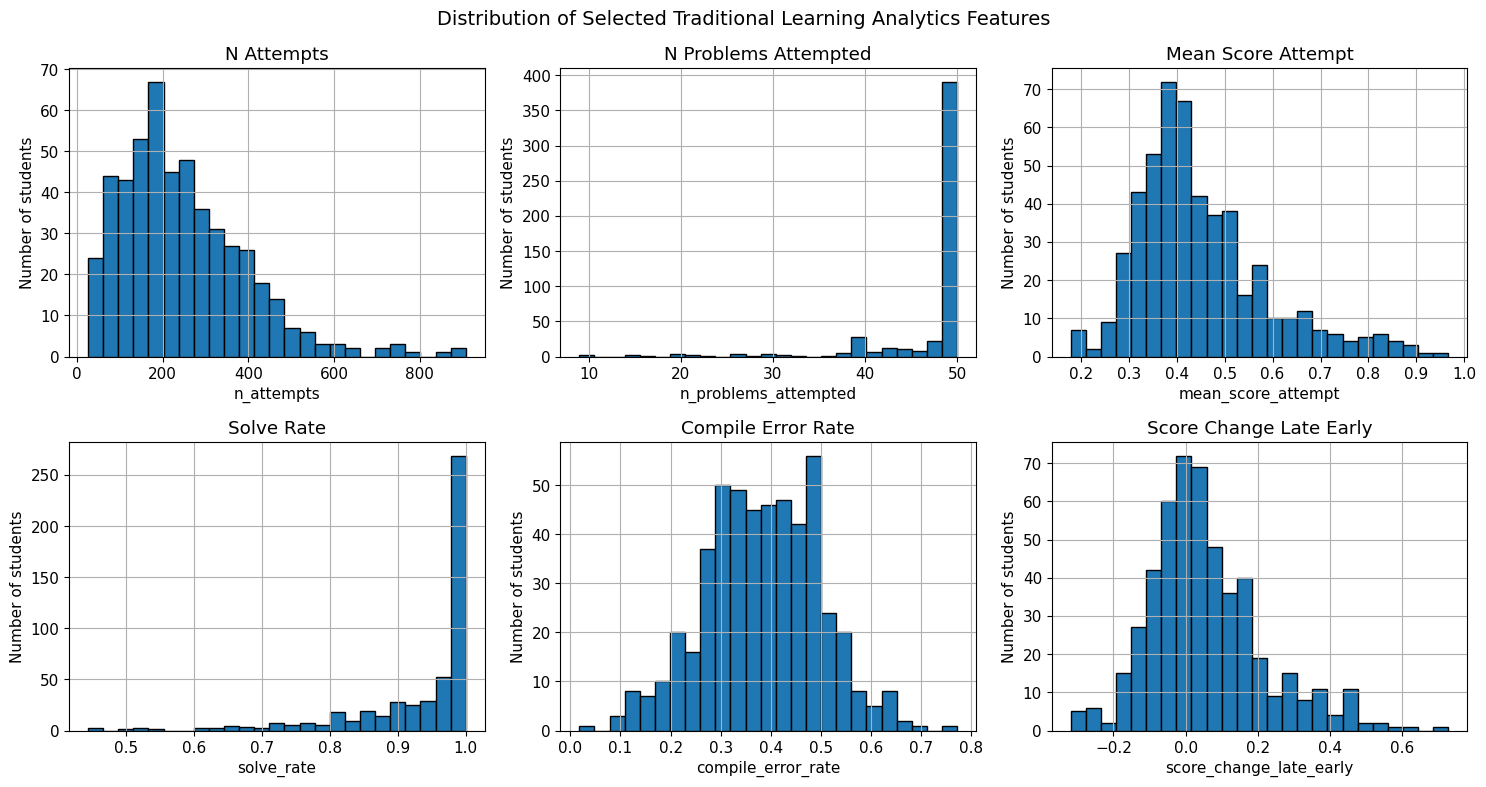

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/traditional_la_feature_distributions.png


In [ ]:
# Selected LA features for visual inspection
selected_la_features = [
    "n_attempts",
    "n_problems_attempted",
    "mean_score_attempt",
    "solve_rate",
    "compile_error_rate",
    "score_change_late_early"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feature in zip(axes, selected_la_features):
    ax.hist(student_la_features[feature], bins=25, edgecolor="black")
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of students")
    ax.grid(True)

plt.suptitle("Distribution of Selected Traditional Learning Analytics Features", fontsize=14)
plt.tight_layout()

figure_path = FIGURES_DIR / "traditional_la_feature_distributions.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

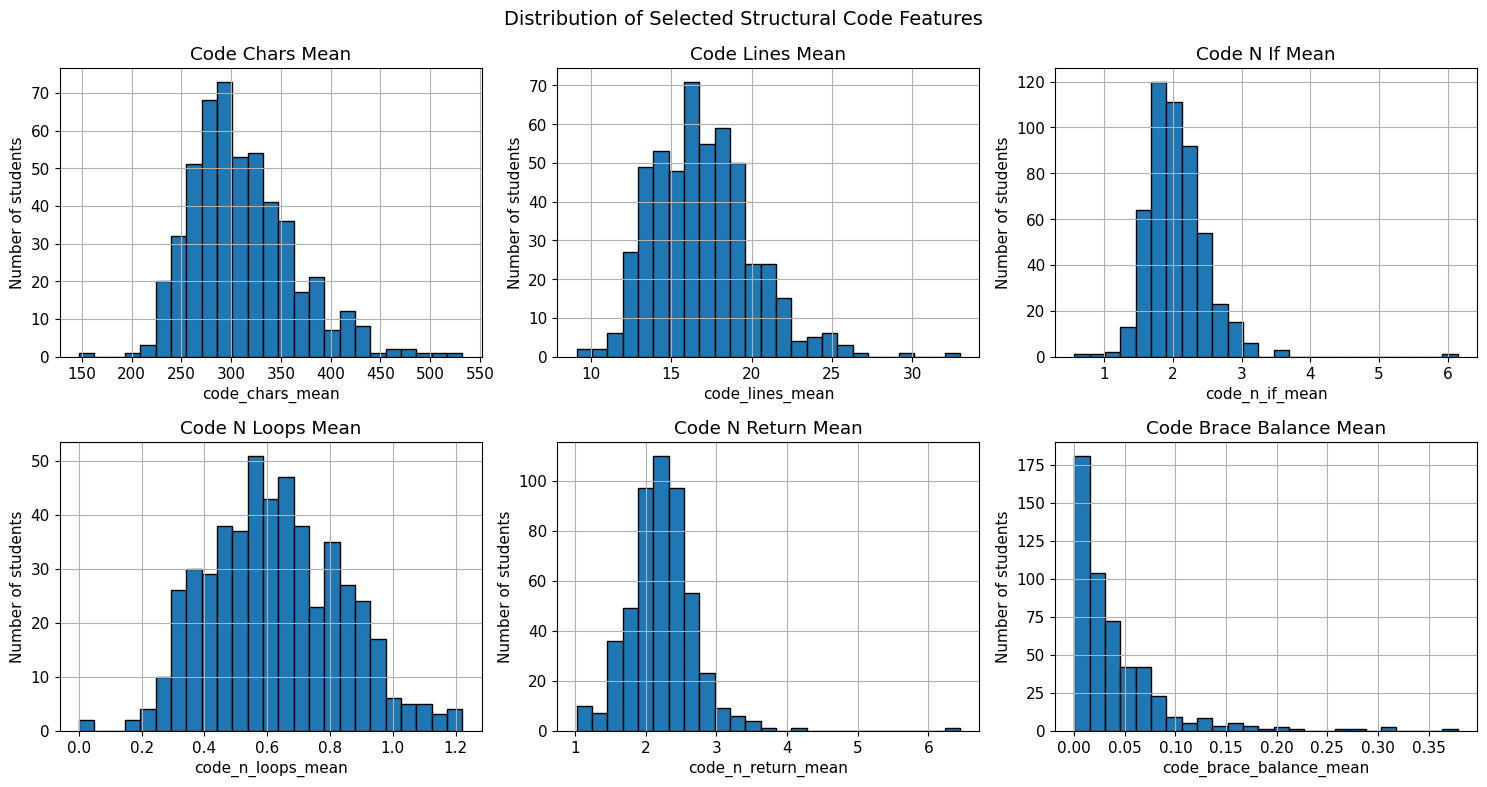

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/structural_code_feature_distributions.png


In [88]:
# Visual inspection of selected structural code features
selected_structural_features = [
    "code_chars_mean",
    "code_lines_mean",
    "code_n_if_mean",
    "code_n_loops_mean",
    "code_n_return_mean",
    "code_brace_balance_mean"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feature in zip(axes, selected_structural_features):
    ax.hist(student_structural_code_features[feature], bins=25, edgecolor="black")
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of students")
    ax.grid(True)

plt.suptitle("Distribution of Selected Structural Code Features", fontsize=14)
plt.tight_layout()

figure_path = FIGURES_DIR / "structural_code_feature_distributions.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

## 7. LLM-based semantic feature extraction

Traditional Learning Analytics features describe student behaviour using numerical information from the platform, such as attempts, scores, solved problems, compile errors, and time gaps.

However, these variables do not fully describe the content of the code written by students. Two students can have a similar number of attempts or similar scores, but their code may show different levels of structure, clarity, completeness, or error-proneness.

For this reason, this project uses a Large Language Model (LLM) to extract semantic features from students’ code submissions. These features aim to capture aspects of the code that are difficult to measure with simple numerical indicators.

The goal of this section is to design and test different prompts for extracting semantic code features. Three prompt versions are compared:

- **Prompt 0**: minimal zero-shot prompt.
- **Prompt 1**: structured prompt with feature definitions.
- **Prompt 2**: detailed rubric-based prompt.

The comparison of prompts is important because LLM outputs can depend strongly on the instructions provided. A more detailed prompt may produce more consistent and useful features, but it may also be longer and more costly.

The extracted semantic features will later be aggregated at student level and compared with traditional Learning Analytics features in the predictive models.

### 7.1 Semantic feature schema

The LLM is asked to evaluate each code submission using a fixed set of semantic features.

The features are designed to capture code quality, clarity, structure, and possible technical problems. Most features use a scale from 1 to 5, where higher values usually indicate better quality. The exception is `error_proneness`, where a higher value means that the code seems more likely to contain syntax, runtime, or logical errors.

The LLM does not receive the final grade of the student. It also does not receive the score of the attempt. This is important to avoid leaking performance information into the semantic features.

In [42]:
# Semantic features to be extracted by the LLM
LLM_NUMERIC_FEATURES = [
    "code_completeness",
    "code_readability",
    "control_flow_quality",
    "decomposition_quality",
    "variable_naming_quality",
    "algorithmic_efficiency",
    "error_proneness",
    "overall_code_quality",
    "llm_confidence"
]

LLM_CATEGORICAL_FEATURES = [
    "strategy_type"
]

LLM_FEATURE_DESCRIPTIONS = {
    "code_completeness": "How complete the solution appears.",
    "code_readability": "How easy the code is to read and understand.",
    "control_flow_quality": "How clear and appropriate the logic and control flow are.",
    "decomposition_quality": "Whether the code is well organised into meaningful parts.",
    "variable_naming_quality": "How meaningful and clear the variable names are.",
    "algorithmic_efficiency": "Whether the solution seems efficient and avoids unnecessary complexity.",
    "error_proneness": "How likely the code is to contain syntax, runtime, or logical errors. Higher means more error-prone.",
    "overall_code_quality": "Overall quality of the code submission.",
    "llm_confidence": "How confident the LLM is about its assessment.",
    "strategy_type": "Main apparent solution strategy."
}

strategy_type_values = [
    "direct_conditionals",
    "loops_or_iteration",
    "helper_methods",
    "object_oriented",
    "hardcoded_solution",
    "incomplete_or_empty",
    "unclear_or_other"
]

schema_table = pd.DataFrame([
    {
        "feature": feature,
        "type": "numeric_1_to_5" if feature != "error_proneness" else "numeric_1_to_5_higher_is_worse",
        "description": LLM_FEATURE_DESCRIPTIONS[feature]
    }
    for feature in LLM_NUMERIC_FEATURES
] + [
    {
        "feature": "strategy_type",
        "type": "categorical",
        "description": LLM_FEATURE_DESCRIPTIONS["strategy_type"]
    }
])

schema_table

,feature,type,description
0,code_completeness,numeric_1_to_5,How complete the solution appears.
1,code_readability,numeric_1_to_5,How easy the code is to read and understand.
2,control_flow_quality,numeric_1_to_5,How clear and appropriate the logic and contro...
3,decomposition_quality,numeric_1_to_5,Whether the code is well organised into meanin...
4,variable_naming_quality,numeric_1_to_5,How meaningful and clear the variable names are.
5,algorithmic_efficiency,numeric_1_to_5,Whether the solution seems efficient and avoid...
6,error_proneness,numeric_1_to_5_higher_is_worse,"How likely the code is to contain syntax, runt..."
7,overall_code_quality,numeric_1_to_5,Overall quality of the code submission.
8,llm_confidence,numeric_1_to_5,How confident the LLM is about its assessment.
9,strategy_type,categorical,Main apparent solution strategy.


### 7.2 Balanced code sample for LLM extraction

Running the LLM on every code submission would be expensive and unnecessary, because many students generate a very large number of code states.

To make the extraction more robust but still manageable, this project selects up to five code submissions per student. These submissions are evenly distributed across each student’s trajectory, so they represent different moments of the learning process.

This design has two advantages. First, every student is represented in the LLM-based dataset. Second, the selected submissions capture the evolution of the student’s code over time instead of focusing only on the first or last attempt.

The same selected submissions will be used for all three prompts. This makes the prompt comparison fair, because each prompt evaluates exactly the same code submissions.

In [43]:
# Keep attempts with available code
attempts_for_llm = attempts[
    (attempts["code_available"] == 1) &
    (attempts["Code"].notna()) &
    (attempts["Code"].str.strip().str.len() > 0)
].copy()

attempts_for_llm = attempts_for_llm.sort_values(
    ["SubjectID", "attempt_number_student"]
).reset_index(drop=True)

print("Attempts available for LLM extraction:")
print(attempts_for_llm.shape)
print("Students:", attempts_for_llm["SubjectID"].nunique())

Attempts available for LLM extraction:
(125568, 31)
Students: 506


In [46]:
def select_evenly_spaced_attempts(group, n_submissions=5):
    """Select evenly spaced submissions from one student trajectory."""
    group = group.sort_values("attempt_number_student").reset_index(drop=True)
    
    if len(group) <= n_submissions:
        return group
    
    positions = np.linspace(0, len(group) - 1, n_submissions)
    positions = np.round(positions).astype(int)
    
    return group.iloc[positions].copy()


# Final configuration for LLM extraction
N_SUBMISSIONS_PER_STUDENT = 5

# Robust selection without using groupby.apply
selected_groups = []

for subject_id, group in attempts_for_llm.groupby("SubjectID"):
    selected = select_evenly_spaced_attempts(
        group,
        n_submissions=N_SUBMISSIONS_PER_STUDENT
    ).copy()
    
    # Safety check in case SubjectID is removed by pandas
    selected["SubjectID"] = subject_id
    
    selected_groups.append(selected)

llm_extraction_sample = pd.concat(selected_groups, ignore_index=True)

# Keep only the columns needed for LLM extraction
llm_extraction_sample = llm_extraction_sample[
    [
        "SubjectID", "AssignmentID", "ProblemID", "ProblemKey",
        "EventID", "CodeStateID", "attempt_number_student",
        "attempt_number_problem", "Score", "is_correct_attempt",
        "Code"
    ]
].copy()

print("LLM extraction sample created.")
print("Rows:", len(llm_extraction_sample))
print("Students:", llm_extraction_sample["SubjectID"].nunique())
print(
    "Average submissions per student:",
    len(llm_extraction_sample) / llm_extraction_sample["SubjectID"].nunique()
)

display(llm_extraction_sample.head())

LLM extraction sample created.
Rows: 2530
Students: 506
Average submissions per student: 5.0


,SubjectID,AssignmentID,ProblemID,ProblemKey,EventID,CodeStateID,attempt_number_student,attempt_number_problem,Score,is_correct_attempt,Code
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,"public int sortaSum(int a, int b)\n{\n if (..."
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,492,32,492_32,50482,7984228960da688b71642844995bbe55be37d24dea3f40...,63,2,0.0000,0,"public String plusOut(String str, String word)..."
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,492,39,492_39,50461,4b1aaa25da5cf6577691fceb6368ea0ff26efc5fde4459...,125,1,0.0000,0,public boolean xyBalance(String str)\n{\n b...
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,494,67,494_67,64265,5d72310e043befa5250e7babcd3b6a6e23a91d2f80b073...,186,15,1.0000,1,public boolean has77(int[] nums) {\n \n ...
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,502,118,502_118,99993,0a72c8d1dc7cab24e3660dfd131dc6af4717e92d3d9734...,248,2,1.0000,1,public int[] shiftLeft(int[] nums)\n{\n int...


In [47]:
# Save selected sample metadata
llm_sample_path = LLM_OUTPUT_DIR / "llm_extraction_sample_5_per_student.csv"

llm_extraction_sample.drop(columns=["Code"]).to_csv(
    llm_sample_path,
    index=False
)

print(f"LLM extraction sample saved in: {llm_sample_path}")
print(f"Shape: {llm_extraction_sample.shape}")

LLM extraction sample saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/llm_features/llm_extraction_sample_5_per_student.csv
Shape: (2530, 11)


### 7.3 Prompt templates

Three prompts are defined to compare different levels of instruction detail.

The three prompts ask for the same output schema. This makes the results comparable across prompts.

The main difference is the amount of guidance given to the LLM:

- **Prompt 0** gives minimal instructions.
- **Prompt 1** explains the meaning of each feature.
- **Prompt 2** provides a detailed scoring rubric.

The expected output is always a valid JSON object.

In [57]:
def build_prompt_0_minimal(code):
    """Minimal zero-shot prompt."""
    
    prompt = f"""
You are analysing a Java code submission written by a student.

Extract semantic features from the code.

Return only a valid JSON object. Do not include markdown, code fences, comments, or explanations.

Use exactly these keys:
code_completeness, code_readability, control_flow_quality, decomposition_quality,
variable_naming_quality, algorithmic_efficiency, error_proneness,
overall_code_quality, llm_confidence, strategy_type.

Use values from 1 to 5 for numeric features.
For error_proneness, 1 means low risk and 5 means high risk.

For strategy_type, use exactly one of these values:
{strategy_type_values}

Code starts here:
{code}
Code ends here.
"""
    
    return prompt


def build_prompt_1_structured(code):
    """Structured prompt with feature definitions."""
    
    prompt = f"""
You are analysing a Java code submission written by a student in an introductory programming course.

Your task is to extract semantic code features. Do not evaluate the student final grade. Only use the code shown below.

Return only a valid JSON object. Do not include markdown, code fences, comments, or explanations.

Use exactly the following keys:

- code_completeness: 1 means very incomplete, 5 means complete solution.
- code_readability: 1 means very hard to read, 5 means very easy to read.
- control_flow_quality: 1 means unclear or wrong logic, 5 means clear and appropriate logic.
- decomposition_quality: 1 means no useful structure, 5 means well organised code.
- variable_naming_quality: 1 means unclear names, 5 means meaningful names.
- algorithmic_efficiency: 1 means very inefficient, 5 means efficient and simple.
- error_proneness: 1 means low probability of errors, 5 means high probability of errors.
- overall_code_quality: 1 means poor code quality, 5 means strong code quality.
- llm_confidence: 1 means low confidence, 5 means high confidence.
- strategy_type: one of {strategy_type_values}.

Code starts here:
{code}
Code ends here.
"""
    
    return prompt


def build_prompt_2_rubric(code):
    """Detailed rubric-based prompt."""
    
    prompt = f"""
You are an assistant helping to analyse Java code submissions from an introductory programming course.

Assess the code only from the code text. Do not assume the student's final grade or attempt score.

Return only one valid JSON object. Do not include markdown, code fences, comments, or explanations.

Use this scoring scale:
1 = very low
2 = low
3 = medium
4 = high
5 = very high

For error_proneness:
1 = the code seems unlikely to fail
2 = minor risk of problems
3 = moderate risk of syntax, runtime, or logic problems
4 = high risk of problems
5 = very high risk or clearly broken/incomplete code

Evaluate these features:

1. code_completeness:
Does the submission look like a complete implementation rather than a fragment?

2. code_readability:
Is the code easy to read, with clear formatting and understandable statements?

3. control_flow_quality:
Is the logic clear and appropriate? Consider conditionals, loops, returns, and branching.

4. decomposition_quality:
Is the code organised into meaningful parts when needed? Penalise unnecessary repetition or messy structure.

5. variable_naming_quality:
Are variable and method names meaningful and easy to understand?

6. algorithmic_efficiency:
Does the code avoid unnecessary complexity, repetition, or inefficient logic?

7. error_proneness:
How likely is the code to contain syntax errors, runtime errors, or logical mistakes?

8. overall_code_quality:
General quality of the submission considering all previous dimensions.

9. llm_confidence:
How confident are you in your assessment based only on this code?

10. strategy_type:
Choose exactly one of these values:
{strategy_type_values}

The JSON object must contain exactly these keys:
code_completeness, code_readability, control_flow_quality, decomposition_quality,
variable_naming_quality, algorithmic_efficiency, error_proneness,
overall_code_quality, llm_confidence, strategy_type.

Code starts here:
{code}
Code ends here.
"""
    
    return prompt


PROMPT_BUILDERS = {
    "prompt_0_minimal": build_prompt_0_minimal,
    "prompt_1_structured": build_prompt_1_structured,
    "prompt_2_rubric": build_prompt_2_rubric
}

print("Prompt templates created.")
print("Prompts:", list(PROMPT_BUILDERS.keys()))

Prompt templates created.
Prompts: ['prompt_0_minimal', 'prompt_1_structured', 'prompt_2_rubric']


### 7.4 Mistral API connection and JSON parsing

The semantic feature extraction is performed using the Mistral API.

The connection is done through an HTTP request. Python sends the prompt to the API together with the selected model and the authentication key. The API returns a text response generated by the model.

The model is instructed to return only a JSON object. After receiving the response, the notebook extracts, parses, and validates the JSON output.

The API key is stored in an environment variable called `MISTRAL_API_KEY`, so it is not written directly in the notebook.

In [58]:
import requests
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

MISTRAL_API_KEY = os.environ.get("MISTRAL_API_KEY")

if MISTRAL_API_KEY is None:
    raise ValueError("MISTRAL_API_KEY is not defined. Add it to your .env file.")

# Mistral API configuration
MISTRAL_URL = "https://api.mistral.ai/v1/chat/completions"
LLM_MODEL = "mistral-small-latest"

MISTRAL_HEADERS = {
    "Authorization": f"Bearer {MISTRAL_API_KEY}",
    "Content-Type": "application/json"
}

def call_mistral_api(prompt, model=LLM_MODEL, temperature=0.0, timeout=120, max_retries=3):
    """Call the Mistral API and return the response text."""
    
    payload = {
        "model": model,
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ],
        "temperature": temperature
    }
    
    for attempt in range(max_retries):
        try:
            response = requests.post(
                MISTRAL_URL,
                headers=MISTRAL_HEADERS,
                json=payload,
                timeout=timeout
            )
            
            response.raise_for_status()
            data = response.json()
            
            return data["choices"][0]["message"]["content"]
        
        except Exception as e:
            wait_time = 2 ** attempt
            print(f"API call failed on attempt {attempt + 1}/{max_retries}: {e}")
            
            if attempt < max_retries - 1:
                print(f"Retrying in {wait_time} seconds...")
                time.sleep(wait_time)
            else:
                raise e


def extract_json_from_text(text):
    """Extract a JSON object from a model response."""
    text = str(text).strip()
    
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            return None
    
    return None


def validate_llm_features(parsed_json):
    """Validate and standardise LLM feature output."""
    if parsed_json is None:
        return None
    
    cleaned = {}
    
    for feature in LLM_NUMERIC_FEATURES:
        value = parsed_json.get(feature, np.nan)
        
        try:
            value = float(value)
        except (TypeError, ValueError):
            value = np.nan
        
        if not np.isnan(value):
            value = min(max(value, 1), 5)
        
        cleaned[feature] = value
    
    strategy = parsed_json.get("strategy_type", "unclear_or_other")
    
    if strategy not in strategy_type_values:
        strategy = "unclear_or_other"
    
    cleaned["strategy_type"] = strategy
    
    return cleaned

In [59]:
# Quick test of the Mistral API connection
test_prompt = "Return only this JSON object: {\"status\": \"ok\"}"

test_response = call_mistral_api(test_prompt)

print("Mistral API connection successful.")
print(test_response)

Mistral API connection successful.
```json
{"status": "ok"}
```


### 7.5 Single-submission test

Before running the extraction on many submissions, the Mistral API is tested on one code example.

For this initial test, only the most detailed prompt, `prompt_2_rubric`, is used. The goal at this point is not to compare the three prompts yet, but to check that the API connection works, that the model returns a valid JSON object, and that the output can be parsed and validated correctly.

The comparison between the three prompt designs will be performed later, using the same selected code submissions for all prompts.

In [60]:
# Test one submission before running the full extraction
test_row = llm_extraction_sample.iloc[0]
test_code = test_row["Code"]

test_prompt = build_prompt_2_rubric(test_code)

print("Testing Mistral API with one code submission...")
print("Model:", LLM_MODEL)

raw_response = call_mistral_api(test_prompt)
parsed_response = extract_json_from_text(raw_response)
validated_response = validate_llm_features(parsed_response)

print("\nRaw response:")
print(raw_response)

print("\nValidated response:")
display(pd.DataFrame([validated_response]))

Testing Mistral API with one code submission...
Model: mistral-small-latest

Raw response:
{"code_completeness": 5, "code_readability": 4, "control_flow_quality": 4, "decomposition_quality": 5, "variable_naming_quality": 5, "algorithmic_efficiency": 5, "error_proneness": 2, "overall_code_quality": 4, "llm_confidence": 5, "strategy_type": "direct_conditionals"}

Validated response:


,code_completeness,code_readability,control_flow_quality,decomposition_quality,variable_naming_quality,algorithmic_efficiency,error_proneness,overall_code_quality,llm_confidence,strategy_type
0,5.0000,4.0000,4.0000,5.0000,5.0000,5.0000,2.0000,4.0000,5.0000,direct_conditionals


The single-submission test worked correctly. The raw response returned by the model was already a valid JSON object. After parsing and validation, the same information was transformed into a structured table.

The raw response represents the original text generated by the LLM. The validated response represents the cleaned version used by the notebook. During validation, numeric values are converted to numbers, restricted to the expected 1-5 scale, and the categorical variable `strategy_type` is checked against the allowed categories.

This step confirms that the LLM output can be transformed into usable semantic features.

### 7.6 LLM extraction with resume support

The full prompt comparison requires many LLM calls:

- 506 students.
- Up to 5 code submissions per student.
- 3 prompt designs.

This produces around 7,590 LLM calls. Since this process can take a long time, the extraction is saved incrementally after every call.

This means that if the process stops, the notebook can be run again and it will continue from the last saved result instead of starting from zero.

Each result is identified by the combination of `CodeStateID` and `prompt_name`. This avoids repeating extractions that have already been completed.

In [61]:
def run_llm_extraction_with_resume(sample_df, prompt_builders, output_path, max_rows=None):
    """Run LLM extraction with incremental saving and resume support."""
    
    output_path = Path(output_path)
    
    if max_rows is not None:
        sample_df = sample_df.head(max_rows).copy()
    
    # Load previous results if available
    if output_path.exists():
        existing_results = pd.read_csv(output_path)
        completed_keys = set(
            zip(
                existing_results["CodeStateID"],
                existing_results["prompt_name"]
            )
        )
        rows = existing_results.to_dict("records")
        print(f"Existing results loaded: {len(existing_results)} rows")
    else:
        completed_keys = set()
        rows = []
        print("No previous results found. Starting from zero.")
    
    total_calls = len(sample_df) * len(prompt_builders)
    completed_calls = len(completed_keys)
    
    print(f"Total expected calls for this run: {total_calls}")
    print(f"Already completed calls: {completed_calls}")
    
    call_counter = completed_calls
    
    for _, row in sample_df.iterrows():
        code = row["Code"]
        
        for prompt_name, prompt_builder in prompt_builders.items():
            key = (row["CodeStateID"], prompt_name)
            
            if key in completed_keys:
                continue
            
            call_counter += 1
            print(f"LLM call {call_counter}/{total_calls} - {prompt_name}")
            
            prompt = prompt_builder(code)
            
            try:
                raw_output = call_mistral_api(prompt)
                parsed = extract_json_from_text(raw_output)
                validated = validate_llm_features(parsed)
                valid_json = validated is not None
                
            except Exception as e:
                raw_output = str(e)
                validated = None
                valid_json = False
            
            result = {
                "SubjectID": row["SubjectID"],
                "AssignmentID": row["AssignmentID"],
                "ProblemID": row["ProblemID"],
                "ProblemKey": row["ProblemKey"],
                "EventID": row["EventID"],
                "CodeStateID": row["CodeStateID"],
                "attempt_number_student": row["attempt_number_student"],
                "attempt_number_problem": row["attempt_number_problem"],
                "Score": row["Score"],
                "is_correct_attempt": row["is_correct_attempt"],
                "prompt_name": prompt_name,
                "valid_json": valid_json,
                "raw_output": raw_output
            }
            
            if validated is not None:
                result.update(validated)
            else:
                for feature in LLM_NUMERIC_FEATURES:
                    result[feature] = np.nan
                result["strategy_type"] = "unclear_or_other"
            
            rows.append(result)
            completed_keys.add(key)
            
            # Save after every call
            pd.DataFrame(rows).to_csv(output_path, index=False)
            
            time.sleep(0.2)
    
    final_results = pd.DataFrame(rows)
    
    print("LLM extraction finished.")
    print(f"Final shape: {final_results.shape}")
    
    return final_results

### 7.7 Small extraction test

Before launching the full extraction, the process is tested on a very small subset.

This first test uses only five code submissions. Since each submission is evaluated with three prompts, this produces 15 LLM calls.

The purpose of this test is to check that the three prompts work correctly, that the outputs are saved, and that the results can be resumed later if needed.

In [64]:
# Output path for Mistral prompt comparison results
llm_prompt_comparison_path = LLM_OUTPUT_DIR / "mistral_prompt_comparison_5_per_student.csv"

# Small test: 5 submissions × 3 prompts = 15 calls
llm_prompt_comparison_test = run_llm_extraction_with_resume(
    sample_df=llm_extraction_sample,
    prompt_builders=PROMPT_BUILDERS,
    output_path=llm_prompt_comparison_path,
    max_rows=5
)

display(llm_prompt_comparison_test.head())

Existing results loaded: 15 rows
Total expected calls for this run: 15
Already completed calls: 15
LLM extraction finished.
Final shape: (15, 23)


,SubjectID,AssignmentID,ProblemID,ProblemKey,EventID,CodeStateID,attempt_number_student,attempt_number_problem,Score,is_correct_attempt,prompt_name,valid_json,raw_output,code_completeness,code_readability,control_flow_quality,decomposition_quality,variable_naming_quality,algorithmic_efficiency,error_proneness,overall_code_quality,llm_confidence,strategy_type
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_0_minimal,True,"{""code_completeness"": 5, ""code_readability"": 4...",5.0000,4.0000,4.0000,1.0000,5.0000,5.0000,1.0000,4.0000,5.0000,direct_conditionals
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_1_structured,True,"{""code_completeness"": 5, ""code_readability"": 5...",5.0000,5.0000,5.0000,3.0000,5.0000,5.0000,1.0000,5.0000,5.0000,direct_conditionals
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_2_rubric,True,"{""code_completeness"": 5, ""code_readability"": 4...",5.0000,4.0000,5.0000,5.0000,4.0000,5.0000,1.0000,5.0000,5.0000,direct_conditionals
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,492,32,492_32,50482,7984228960da688b71642844995bbe55be37d24dea3f40...,63,2,0.0000,0,prompt_0_minimal,True,"{""code_completeness"": 5, ""code_readability"": 3...",5.0000,3.0000,3.0000,1.0000,3.0000,3.0000,4.0000,2.0000,4.0000,direct_conditionals
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,492,32,492_32,50482,7984228960da688b71642844995bbe55be37d24dea3f40...,63,2,0.0000,0,prompt_1_structured,True,"{""code_completeness"": 4, ""code_readability"": 3...",4.0000,3.0000,4.0000,2.0000,3.0000,3.0000,3.0000,3.0000,4.0000,direct_conditionals


In [65]:
# Quick check of the small extraction test
small_test_summary = (
    llm_prompt_comparison_test
    .groupby("prompt_name")
    .agg(
        n_outputs=("EventID", "count"),
        valid_json_rate=("valid_json", "mean")
    )
    .reset_index()
)

small_test_summary["valid_json_rate"] = small_test_summary["valid_json_rate"] * 100

small_test_summary

,prompt_name,n_outputs,valid_json_rate
0,prompt_0_minimal,5,100.0000
1,prompt_1_structured,5,100.0000
2,prompt_2_rubric,5,100.0000


The small extraction test worked correctly. The test used five code submissions and evaluated each of them with the three prompt designs, producing 15 LLM calls in total.

The results show that the three prompts returned valid outputs that could be parsed and transformed into structured semantic features. This confirms that the Mistral API connection works, that the prompts follow the expected output schema, and that the JSON validation process is working.

This successful small test supports launching the full prompt comparison extraction.

### 7.8 Full LLM extraction

After confirming that the small test works, the full prompt comparison can be launched.

This step applies the three prompts to the complete LLM extraction sample. The results are saved incrementally in the same CSV file used in the small test.

Because the extraction has resume support, the 15 calls from the small test will not be repeated. The function will continue from the remaining submissions.

In [66]:
# Full extraction: all selected submissions × 3 prompts
llm_prompt_comparison_results = run_llm_extraction_with_resume(
    sample_df=llm_extraction_sample,
    prompt_builders=PROMPT_BUILDERS,
    output_path=llm_prompt_comparison_path,
    max_rows=None
)

display(llm_prompt_comparison_results.head())

Existing results loaded: 15 rows
Total expected calls for this run: 7590
Already completed calls: 15
LLM call 16/7590 - prompt_0_minimal
LLM call 17/7590 - prompt_1_structured
LLM call 18/7590 - prompt_2_rubric
LLM call 19/7590 - prompt_0_minimal
LLM call 20/7590 - prompt_1_structured
LLM call 21/7590 - prompt_2_rubric
LLM call 22/7590 - prompt_0_minimal
LLM call 23/7590 - prompt_1_structured
LLM call 24/7590 - prompt_2_rubric
LLM call 25/7590 - prompt_0_minimal
LLM call 26/7590 - prompt_1_structured
LLM call 27/7590 - prompt_2_rubric
LLM call 28/7590 - prompt_0_minimal
LLM call 29/7590 - prompt_1_structured
LLM call 30/7590 - prompt_2_rubric
LLM call 31/7590 - prompt_0_minimal
LLM call 32/7590 - prompt_1_structured
LLM call 33/7590 - prompt_2_rubric
LLM call 34/7590 - prompt_0_minimal
LLM call 35/7590 - prompt_1_structured
LLM call 36/7590 - prompt_2_rubric
LLM call 37/7590 - prompt_0_minimal
LLM call 38/7590 - prompt_1_structured
LLM call 39/7590 - prompt_2_rubric
LLM call 40/7590 - 

,SubjectID,AssignmentID,ProblemID,ProblemKey,EventID,CodeStateID,attempt_number_student,attempt_number_problem,Score,is_correct_attempt,prompt_name,valid_json,raw_output,code_completeness,code_readability,control_flow_quality,decomposition_quality,variable_naming_quality,algorithmic_efficiency,error_proneness,overall_code_quality,llm_confidence,strategy_type
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_0_minimal,True,"{""code_completeness"": 5, ""code_readability"": 4...",5.0000,4.0000,4.0000,1.0000,5.0000,5.0000,1.0000,4.0000,5.0000,direct_conditionals
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_1_structured,True,"{""code_completeness"": 5, ""code_readability"": 5...",5.0000,5.0000,5.0000,3.0000,5.0000,5.0000,1.0000,5.0000,5.0000,direct_conditionals
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_2_rubric,True,"{""code_completeness"": 5, ""code_readability"": 4...",5.0000,4.0000,5.0000,5.0000,4.0000,5.0000,1.0000,5.0000,5.0000,direct_conditionals
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,492,32,492_32,50482,7984228960da688b71642844995bbe55be37d24dea3f40...,63,2,0.0000,0,prompt_0_minimal,True,"{""code_completeness"": 5, ""code_readability"": 3...",5.0000,3.0000,3.0000,1.0000,3.0000,3.0000,4.0000,2.0000,4.0000,direct_conditionals
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,492,32,492_32,50482,7984228960da688b71642844995bbe55be37d24dea3f40...,63,2,0.0000,0,prompt_1_structured,True,"{""code_completeness"": 4, ""code_readability"": 3...",4.0000,3.0000,4.0000,2.0000,3.0000,3.0000,3.0000,3.0000,4.0000,direct_conditionals


The full LLM extraction was completed successfully.

The final dataset contains 7,590 rows, corresponding to 2,530 selected code submissions evaluated with three different prompt designs. Each student is represented by up to five code submissions selected from different moments of their trajectory.

Each row contains the semantic features extracted from one code submission using one prompt. The output includes both the raw LLM response and the validated structured features. The validated features will be used in the next steps to compare prompt quality and to aggregate semantic information at student level.

This dataset is a key part of the project because it allows a fair comparison between the three prompt designs using the same code submissions.

### 7.9 Load saved Mistral results

Once the LLM extraction has been completed and saved, the results can be loaded directly from disk.

This avoids repeating the API calls in future notebook executions. From this point onwards, the analysis can continue using the saved CSV file.

In [67]:
# Load saved Mistral prompt comparison results
llm_prompt_comparison_path = LLM_OUTPUT_DIR / "mistral_prompt_comparison_5_per_student.csv"

llm_prompt_comparison_results = pd.read_csv(llm_prompt_comparison_path)

print("Mistral prompt comparison results loaded.")
print(llm_prompt_comparison_results.shape)

display(llm_prompt_comparison_results.head())

Mistral prompt comparison results loaded.
(7590, 23)


,SubjectID,AssignmentID,ProblemID,ProblemKey,EventID,CodeStateID,attempt_number_student,attempt_number_problem,Score,is_correct_attempt,prompt_name,valid_json,raw_output,code_completeness,code_readability,control_flow_quality,decomposition_quality,variable_naming_quality,algorithmic_efficiency,error_proneness,overall_code_quality,llm_confidence,strategy_type
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_0_minimal,True,"{""code_completeness"": 5, ""code_readability"": 4...",5.0000,4.0000,4.0000,1.0000,5.0000,5.0000,1.0000,4.0000,5.0000,direct_conditionals
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_1_structured,True,"{""code_completeness"": 5, ""code_readability"": 5...",5.0000,5.0000,5.0000,3.0000,5.0000,5.0000,1.0000,5.0000,5.0000,direct_conditionals
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_2_rubric,True,"{""code_completeness"": 5, ""code_readability"": 4...",5.0000,4.0000,5.0000,5.0000,4.0000,5.0000,1.0000,5.0000,5.0000,direct_conditionals
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,492,32,492_32,50482,7984228960da688b71642844995bbe55be37d24dea3f40...,63,2,0.0000,0,prompt_0_minimal,True,"{""code_completeness"": 5, ""code_readability"": 3...",5.0000,3.0000,3.0000,1.0000,3.0000,3.0000,4.0000,2.0000,4.0000,direct_conditionals
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,492,32,492_32,50482,7984228960da688b71642844995bbe55be37d24dea3f40...,63,2,0.0000,0,prompt_1_structured,True,"{""code_completeness"": 4, ""code_readability"": 3...",4.0000,3.0000,4.0000,2.0000,3.0000,3.0000,3.0000,3.0000,4.0000,direct_conditionals


### 7.10 Basic prompt quality checks

The first comparison between prompts focuses on technical quality.

A good prompt should produce valid JSON outputs, few missing values, and feature values that follow the expected scale.

This does not yet prove that the features are predictive, but it helps identify whether the prompt is reliable enough for the next stages.

In [68]:
# Valid JSON rate by prompt
prompt_validity_summary = (
    llm_prompt_comparison_results
    .groupby("prompt_name")
    .agg(
        n_outputs=("EventID", "count"),
        valid_json_rate=("valid_json", "mean")
    )
    .reset_index()
)

prompt_validity_summary["valid_json_rate"] = (
    prompt_validity_summary["valid_json_rate"] * 100
)

prompt_validity_summary

,prompt_name,n_outputs,valid_json_rate
0,prompt_0_minimal,2530,100.0000
1,prompt_1_structured,2530,100.0000
2,prompt_2_rubric,2530,100.0000


In [69]:
# Missing values by prompt and numeric feature
missing_rows = []

for prompt_name, group in llm_prompt_comparison_results.groupby("prompt_name"):
    for feature in LLM_NUMERIC_FEATURES:
        missing_rows.append({
            "prompt_name": prompt_name,
            "feature": feature,
            "missing_rate": group[feature].isna().mean() * 100
        })

prompt_missing_summary = pd.DataFrame(missing_rows)

prompt_missing_pivot = prompt_missing_summary.pivot(
    index="feature",
    columns="prompt_name",
    values="missing_rate"
)

prompt_missing_pivot

prompt_name,prompt_0_minimal,prompt_1_structured,prompt_2_rubric
feature,,,
algorithmic_efficiency,0.0000,0.0000,0.0000
code_completeness,0.0000,0.0000,0.0000
code_readability,0.0000,0.0000,0.0000
control_flow_quality,0.0000,0.0000,0.0000
decomposition_quality,0.0000,0.0000,0.0000
error_proneness,0.0000,0.0000,0.0000
llm_confidence,0.0000,0.0000,0.0000
overall_code_quality,0.0000,0.0000,0.0000
variable_naming_quality,0.0000,0.0000,0.0000


In [70]:
# Mean feature values by prompt
prompt_feature_means = (
    llm_prompt_comparison_results
    .groupby("prompt_name")[LLM_NUMERIC_FEATURES]
    .mean()
    .reset_index()
)

prompt_feature_means

,prompt_name,code_completeness,code_readability,control_flow_quality,decomposition_quality,variable_naming_quality,algorithmic_efficiency,error_proneness,overall_code_quality,llm_confidence
0,prompt_0_minimal,4.2439,3.3451,3.1885,1.4945,3.5688,3.8874,2.7047,2.9470,4.3514
1,prompt_1_structured,3.9312,3.5711,3.6237,1.9549,3.5557,3.9960,2.8119,3.0854,4.8024
2,prompt_2_rubric,4.2466,3.4241,3.2617,3.2387,3.3613,3.8000,3.0119,3.2178,4.9885


In [71]:
# Distribution of strategy types by prompt
strategy_distribution = (
    llm_prompt_comparison_results
    .groupby(["prompt_name", "strategy_type"])
    .size()
    .reset_index(name="count")
)

strategy_distribution

,prompt_name,strategy_type,count
0,prompt_0_minimal,direct_conditionals,1788
1,prompt_0_minimal,hardcoded_solution,22
2,prompt_0_minimal,helper_methods,65
3,prompt_0_minimal,incomplete_or_empty,198
4,prompt_0_minimal,loops_or_iteration,452
5,prompt_0_minimal,unclear_or_other,5
6,prompt_1_structured,direct_conditionals,1593
7,prompt_1_structured,hardcoded_solution,6
8,prompt_1_structured,helper_methods,71
9,prompt_1_structured,incomplete_or_empty,192


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load LLM prompt comparison results from saved files
# without rerunning the notebook
# ------------------------------------------------------------

required_cols = {"prompt_name", "strategy_type"}

search_dirs = [
    Path("."),
    Path("outputs"),
    Path("outputs/figures"),
    Path("outputs/tables"),
    Path("outputs/data"),
    Path("outputs/llm"),
    Path("outputs_llm"),
]

candidate_files = []

for search_dir in search_dirs:
    if search_dir.exists():
        candidate_files.extend(list(search_dir.rglob("*.csv")))
        candidate_files.extend(list(search_dir.rglob("*.parquet")))
        candidate_files.extend(list(search_dir.rglob("*.pkl")))
        candidate_files.extend(list(search_dir.rglob("*.pickle")))

candidate_files = sorted(set(candidate_files))

matching_files = []

for file_path in candidate_files:
    try:
        if file_path.suffix == ".csv":
            preview = pd.read_csv(file_path, nrows=5)
        elif file_path.suffix == ".parquet":
            preview = pd.read_parquet(file_path)
            preview = preview.head(5)
        elif file_path.suffix in [".pkl", ".pickle"]:
            preview = pd.read_pickle(file_path)
            preview = preview.head(5)
        else:
            continue

        cols = set(preview.columns)

        if required_cols.issubset(cols):
            matching_files.append(file_path)

    except Exception:
        pass

print("Files found with prompt_name and strategy_type:")
for i, f in enumerate(matching_files):
    print(f"{i}: {f}")

if len(matching_files) == 0:
    raise FileNotFoundError(
        "No saved file with columns 'prompt_name' and 'strategy_type' was found. "
        "Search manually in your outputs folder for the file that contains the LLM prompt comparison results."
    )

# Load the first matching file
selected_file = matching_files[0]
print(f"\nLoading: {selected_file}")

if selected_file.suffix == ".csv":
    llm_prompt_comparison_results = pd.read_csv(selected_file)
elif selected_file.suffix == ".parquet":
    llm_prompt_comparison_results = pd.read_parquet(selected_file)
elif selected_file.suffix in [".pkl", ".pickle"]:
    llm_prompt_comparison_results = pd.read_pickle(selected_file)

print(llm_prompt_comparison_results.shape)
llm_prompt_comparison_results[["prompt_name", "strategy_type"]].head()

Files found with prompt_name and strategy_type:
0: outputs/llm_features/mistral_prompt_comparison_5_per_student.csv
1: outputs/llm_features/prompt_strategy_distribution.csv

Loading: outputs/llm_features/mistral_prompt_comparison_5_per_student.csv
(7590, 23)


,prompt_name,strategy_type
0,prompt_0_minimal,direct_conditionals
1,prompt_1_structured,direct_conditionals
2,prompt_2_rubric,direct_conditionals
3,prompt_0_minimal,direct_conditionals
4,prompt_1_structured,direct_conditionals


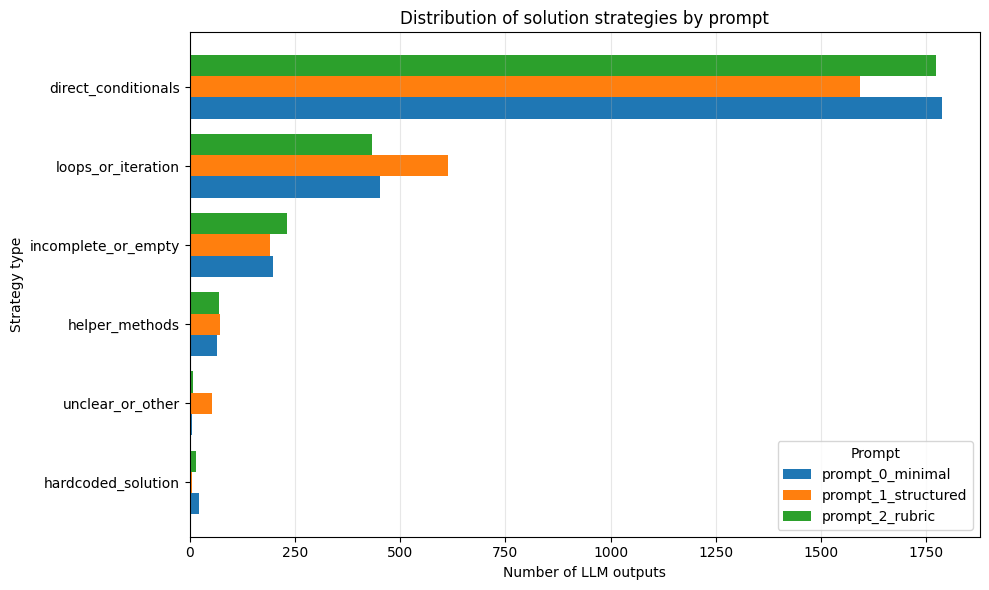

Figure saved to: outputs/figures/llm_strategy_type_distribution_by_prompt.png
Figure saved to: outputs/figures/llm_strategy_type_distribution_by_prompt.pdf


In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Bar plot: distribution of strategy types by prompt
# ------------------------------------------------------------

figures_dir = Path("outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

strategy_distribution = (
    llm_prompt_comparison_results
    .groupby(["prompt_name", "strategy_type"])
    .size()
    .reset_index(name="count")
)

strategy_pivot = (
    strategy_distribution
    .pivot(index="strategy_type", columns="prompt_name", values="count")
    .fillna(0)
)

strategy_pivot["total"] = strategy_pivot.sum(axis=1)
strategy_pivot = strategy_pivot.sort_values("total", ascending=True)
strategy_pivot = strategy_pivot.drop(columns="total")

fig, ax = plt.subplots(figsize=(10, 6))

y = np.arange(len(strategy_pivot.index))
n_prompts = len(strategy_pivot.columns)
bar_height = 0.8 / n_prompts

for i, prompt in enumerate(strategy_pivot.columns):
    offset = (i - (n_prompts - 1) / 2) * bar_height
    ax.barh(
        y + offset,
        strategy_pivot[prompt].values,
        height=bar_height,
        label=prompt
    )

ax.set_yticks(y)
ax.set_yticklabels(strategy_pivot.index)
ax.set_xlabel("Number of LLM outputs")
ax.set_ylabel("Strategy type")
ax.set_title("Distribution of solution strategies by prompt")
ax.legend(title="Prompt")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

output_path_png = figures_dir / "llm_strategy_type_distribution_by_prompt.png"
output_path_pdf = figures_dir / "llm_strategy_type_distribution_by_prompt.pdf"

plt.savefig(output_path_png, dpi=300, bbox_inches="tight")
plt.savefig(output_path_pdf, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {output_path_png}")
print(f"Figure saved to: {output_path_pdf}")

### 7.11 Visual comparison of prompt outputs

The following plots compare the distribution of the semantic features produced by each prompt.

This visual inspection helps identify whether the prompts generate meaningful variation or whether they tend to assign very similar scores to most submissions.

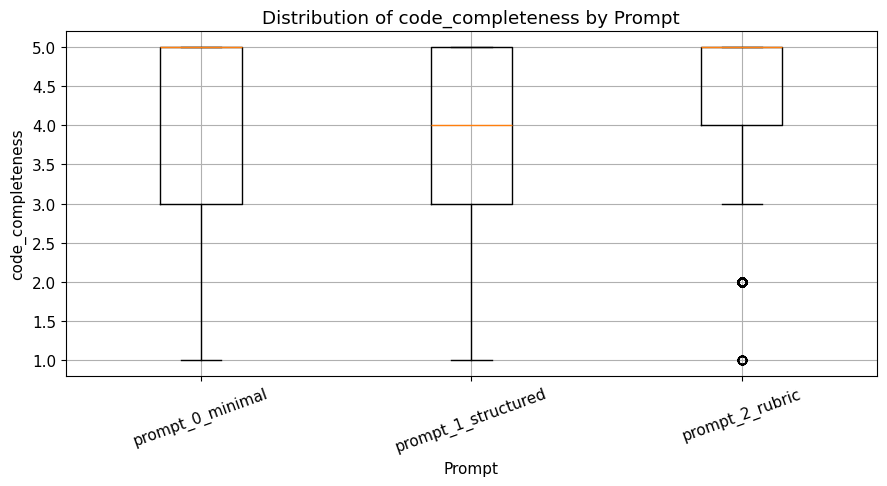

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/llm_code_completeness_by_prompt.png


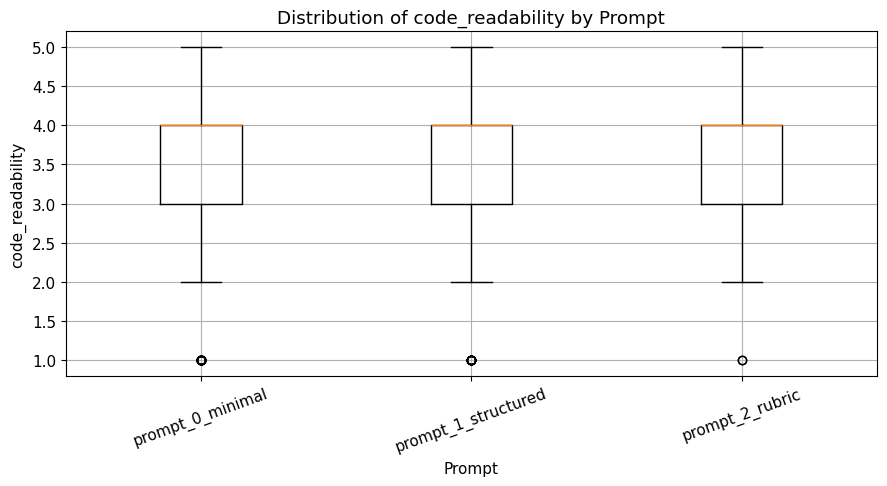

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/llm_code_readability_by_prompt.png


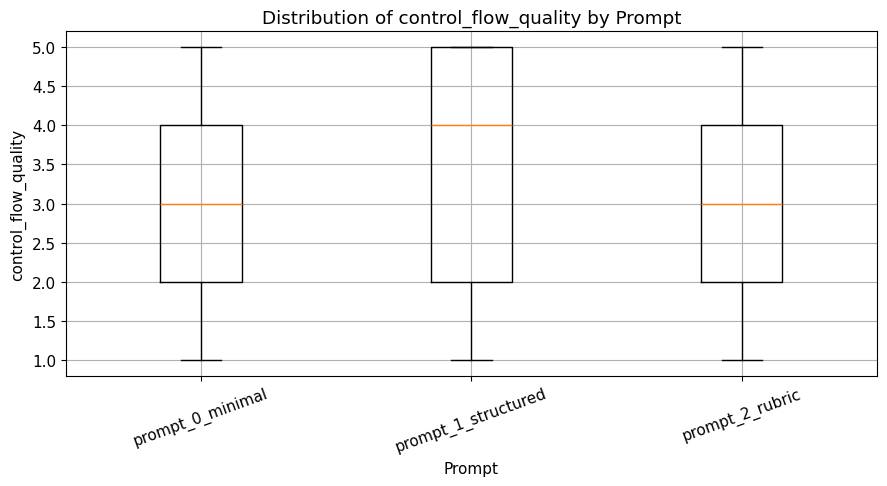

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/llm_control_flow_quality_by_prompt.png


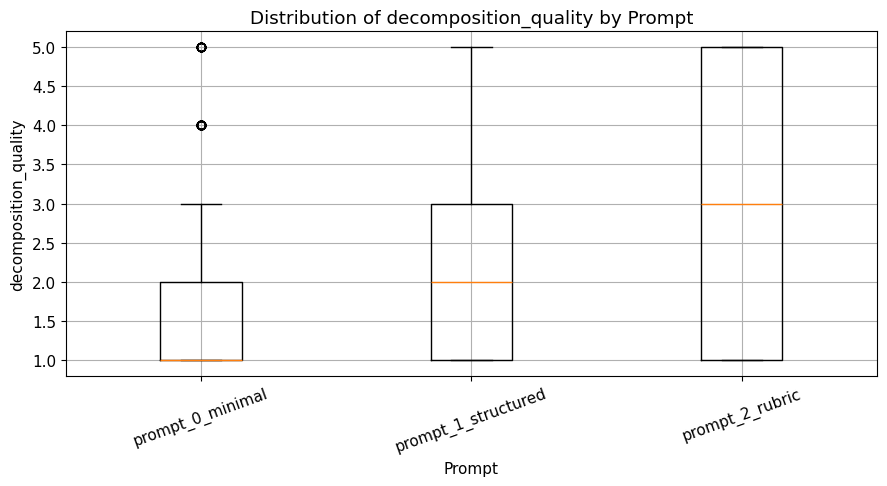

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/llm_decomposition_quality_by_prompt.png


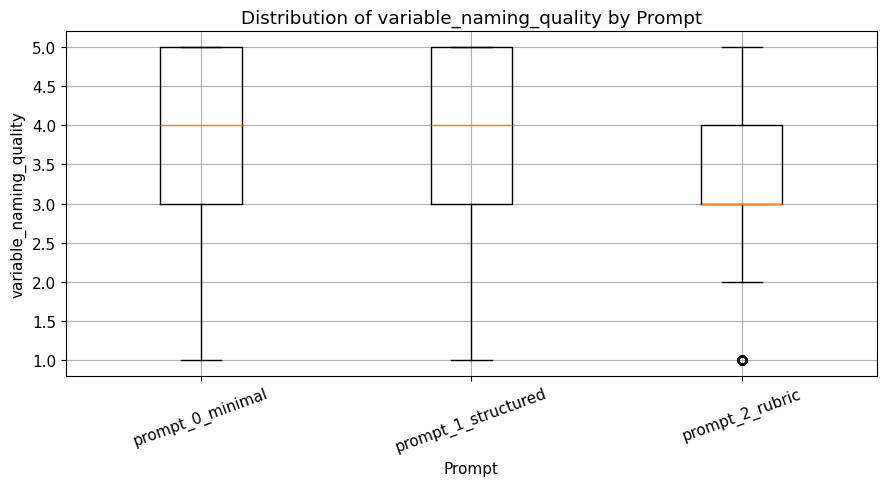

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/llm_variable_naming_quality_by_prompt.png


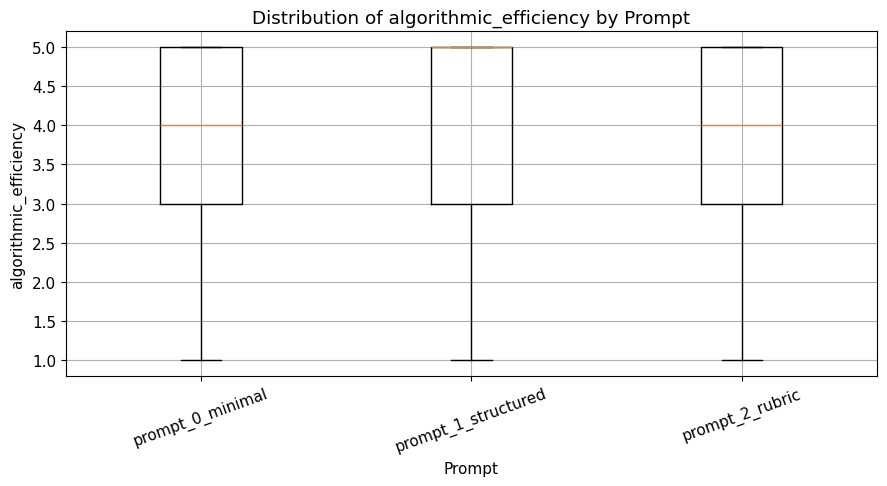

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/llm_algorithmic_efficiency_by_prompt.png


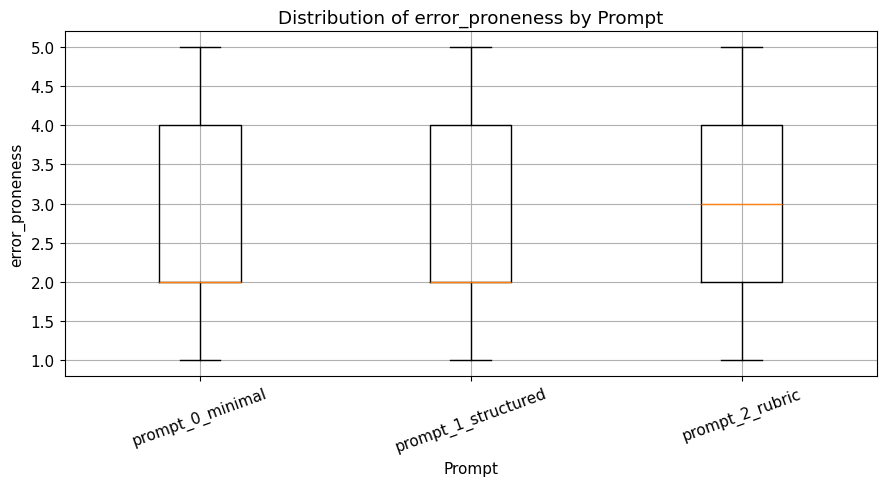

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/llm_error_proneness_by_prompt.png


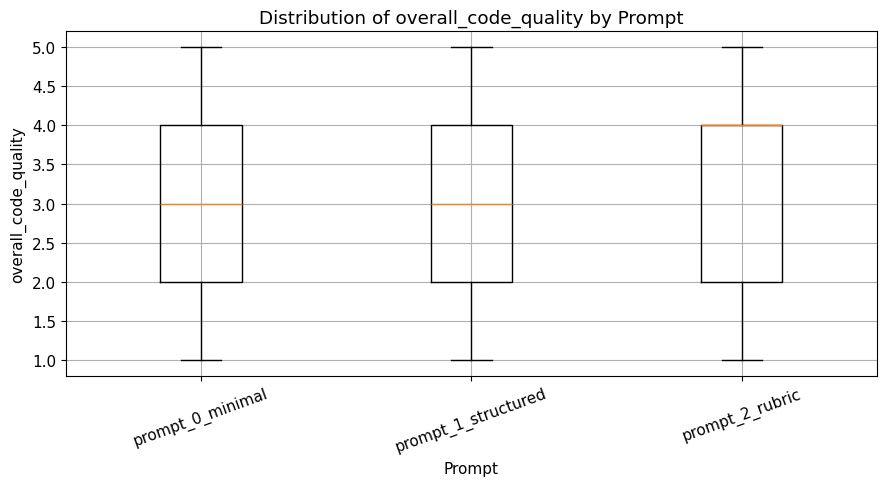

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/llm_overall_code_quality_by_prompt.png


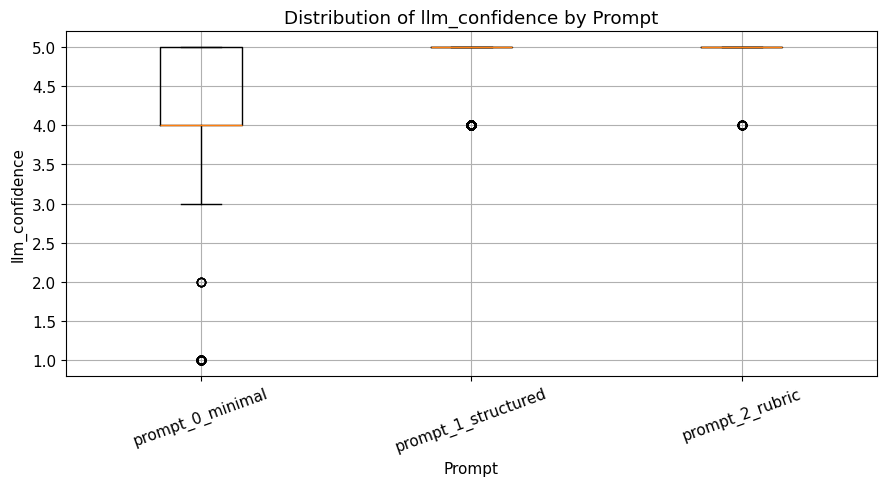

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/llm_llm_confidence_by_prompt.png


In [72]:
# Boxplots of LLM numeric features by prompt
for feature in LLM_NUMERIC_FEATURES:
    data_to_plot = [
        group[feature].dropna().values
        for _, group in llm_prompt_comparison_results.groupby("prompt_name")
    ]
    
    labels = [
        prompt_name
        for prompt_name, _ in llm_prompt_comparison_results.groupby("prompt_name")
    ]
    
    plt.figure(figsize=(9, 5))
    plt.boxplot(data_to_plot, labels=labels)
    plt.title(f"Distribution of {feature} by Prompt")
    plt.xlabel("Prompt")
    plt.ylabel(feature)
    plt.xticks(rotation=20)
    plt.grid(True)
    plt.tight_layout()
    
    figure_path = FIGURES_DIR / f"llm_{feature}_by_prompt.png"
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    print(f"Figure saved in: {figure_path}")

In [73]:
# Save prompt quality summaries
prompt_validity_summary.to_csv(
    LLM_OUTPUT_DIR / "prompt_validity_summary.csv",
    index=False
)

prompt_missing_pivot.to_csv(
    LLM_OUTPUT_DIR / "prompt_missing_summary.csv"
)

prompt_feature_means.to_csv(
    LLM_OUTPUT_DIR / "prompt_feature_means.csv",
    index=False
)

strategy_distribution.to_csv(
    LLM_OUTPUT_DIR / "prompt_strategy_distribution.csv",
    index=False
)

print("Prompt quality summaries saved.")

Prompt quality summaries saved.


## 8. Student-level LLM feature aggregation

The LLM extraction was performed at code-submission level. Each selected code submission was evaluated with three different prompts, and each output contains semantic features about that specific code version.

However, the predictive models in this project are built at student level. Therefore, the LLM-based features need to be aggregated so that each student is represented by one row.

This section aggregates the semantic features separately for each prompt. This allows the project to compare whether the features generated by different prompt designs add different levels of predictive value.

For each student and each prompt, the numeric LLM features are summarised using:

- The **mean** value across the selected submissions.
- The **standard deviation** across submissions.
- The **first** selected submission value.
- The **last** selected submission value.
- The **change between the last and first** selected submission.

The categorical feature `strategy_type` is aggregated as the **proportion** of selected submissions assigned to each strategy.

The final output of this section is a set of student-level LLM feature tables, one for each prompt. These tables will then be merged with the traditional Learning Analytics features and the structural code features.

In [74]:
# Load saved LLM results if needed
llm_prompt_comparison_path = LLM_OUTPUT_DIR / "mistral_prompt_comparison_5_per_student.csv"

llm_prompt_comparison_results = pd.read_csv(llm_prompt_comparison_path)

print("LLM prompt comparison results loaded.")
print(llm_prompt_comparison_results.shape)

display(llm_prompt_comparison_results.head())

LLM prompt comparison results loaded.
(7590, 23)


,SubjectID,AssignmentID,ProblemID,ProblemKey,EventID,CodeStateID,attempt_number_student,attempt_number_problem,Score,is_correct_attempt,prompt_name,valid_json,raw_output,code_completeness,code_readability,control_flow_quality,decomposition_quality,variable_naming_quality,algorithmic_efficiency,error_proneness,overall_code_quality,llm_confidence,strategy_type
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_0_minimal,True,"{""code_completeness"": 5, ""code_readability"": 4...",5.0000,4.0000,4.0000,1.0000,5.0000,5.0000,1.0000,4.0000,5.0000,direct_conditionals
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_1_structured,True,"{""code_completeness"": 5, ""code_readability"": 5...",5.0000,5.0000,5.0000,3.0000,5.0000,5.0000,1.0000,5.0000,5.0000,direct_conditionals
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,439_1,11161,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,1,1,1.0000,1,prompt_2_rubric,True,"{""code_completeness"": 5, ""code_readability"": 4...",5.0000,4.0000,5.0000,5.0000,4.0000,5.0000,1.0000,5.0000,5.0000,direct_conditionals
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,492,32,492_32,50482,7984228960da688b71642844995bbe55be37d24dea3f40...,63,2,0.0000,0,prompt_0_minimal,True,"{""code_completeness"": 5, ""code_readability"": 3...",5.0000,3.0000,3.0000,1.0000,3.0000,3.0000,4.0000,2.0000,4.0000,direct_conditionals
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,492,32,492_32,50482,7984228960da688b71642844995bbe55be37d24dea3f40...,63,2,0.0000,0,prompt_1_structured,True,"{""code_completeness"": 4, ""code_readability"": 3...",4.0000,3.0000,4.0000,2.0000,3.0000,3.0000,3.0000,3.0000,4.0000,direct_conditionals


In [75]:
# Basic check before aggregation
llm_results_check = (
    llm_prompt_comparison_results
    .groupby("prompt_name")
    .agg(
        n_rows=("EventID", "count"),
        n_students=("SubjectID", "nunique"),
        n_code_states=("CodeStateID", "nunique"),
        valid_json_rate=("valid_json", "mean")
    )
    .reset_index()
)

llm_results_check["valid_json_rate"] = llm_results_check["valid_json_rate"] * 100

llm_results_check

,prompt_name,n_rows,n_students,n_code_states,valid_json_rate
0,prompt_0_minimal,2530,506,2530,100.0000
1,prompt_1_structured,2530,506,2530,100.0000
2,prompt_2_rubric,2530,506,2530,100.0000


In [76]:
# Keep a clean copy of valid LLM outputs
llm_valid = llm_prompt_comparison_results.copy()

# Make sure numeric LLM features are numeric
for feature in LLM_NUMERIC_FEATURES:
    llm_valid[feature] = pd.to_numeric(llm_valid[feature], errors="coerce")

# Sort submissions in the student's trajectory
llm_valid = llm_valid.sort_values(
    ["prompt_name", "SubjectID", "attempt_number_student"]
).reset_index(drop=True)

print("Valid LLM dataset prepared for aggregation.")
print(llm_valid.shape)

Valid LLM dataset prepared for aggregation.
(7590, 23)


### 8.1 Aggregating LLM features by prompt

The semantic features are aggregated separately for each prompt.

This is important because the three prompts may produce different interpretations of the same code submissions. By keeping them separate, the modelling stage can test which prompt produces the most useful semantic features.

For each prompt, the output is a student-level table with one row per student.

In [77]:
def aggregate_llm_features_for_prompt(llm_df, prompt_name):
    """Aggregate LLM features at student level for one prompt."""
    
    prompt_df = (
        llm_df[llm_df["prompt_name"] == prompt_name]
        .sort_values(["SubjectID", "attempt_number_student"])
        .copy()
    )
    
    # Numeric semantic feature aggregation
    agg_dict = {}
    
    for feature in LLM_NUMERIC_FEATURES:
        agg_dict[f"llm_{feature}_mean"] = (feature, "mean")
        agg_dict[f"llm_{feature}_std"] = (feature, "std")
        agg_dict[f"llm_{feature}_first"] = (feature, "first")
        agg_dict[f"llm_{feature}_last"] = (feature, "last")
    
    numeric_agg = (
        prompt_df
        .groupby("SubjectID")
        .agg(**agg_dict)
        .reset_index()
    )
    
    # Change between last and first selected submission
    for feature in LLM_NUMERIC_FEATURES:
        numeric_agg[f"llm_{feature}_change_last_first"] = (
            numeric_agg[f"llm_{feature}_last"] 
            - numeric_agg[f"llm_{feature}_first"]
        )
    
    # Submission counts and valid output rate
    coverage_agg = (
        prompt_df
        .groupby("SubjectID")
        .agg(
            llm_n_submissions=("CodeStateID", "count"),
            llm_valid_json_rate=("valid_json", "mean")
        )
        .reset_index()
    )
    
    # Strategy proportions
    strategy_counts = (
        prompt_df
        .groupby(["SubjectID", "strategy_type"])
        .size()
        .reset_index(name="count")
    )
    
    strategy_pivot = strategy_counts.pivot(
        index="SubjectID",
        columns="strategy_type",
        values="count"
    ).fillna(0)
    
    # Convert counts to proportions
    strategy_pivot = strategy_pivot.div(strategy_pivot.sum(axis=1), axis=0)
    
    # Ensure all possible strategy columns exist
    for strategy in strategy_type_values:
        if strategy not in strategy_pivot.columns:
            strategy_pivot[strategy] = 0
    
    strategy_pivot = strategy_pivot[strategy_type_values]
    strategy_pivot.columns = [
        f"llm_strategy_prop_{col}" for col in strategy_pivot.columns
    ]
    
    strategy_pivot = strategy_pivot.reset_index()
    
    # Merge all LLM aggregations
    student_llm_features = (
        coverage_agg
        .merge(numeric_agg, on="SubjectID", how="left")
        .merge(strategy_pivot, on="SubjectID", how="left")
    )
    
    # Replace std missing values with 0 when a student has only one selected submission
    numeric_cols = student_llm_features.select_dtypes(include=[np.number]).columns
    student_llm_features[numeric_cols] = student_llm_features[numeric_cols].fillna(0)
    
    student_llm_features["prompt_name"] = prompt_name
    
    return student_llm_features

In [78]:
# Aggregate LLM features separately for each prompt
student_llm_features_by_prompt = {}

for prompt_name in sorted(llm_valid["prompt_name"].unique()):
    student_llm_features_by_prompt[prompt_name] = aggregate_llm_features_for_prompt(
        llm_valid,
        prompt_name
    )

    print(prompt_name, student_llm_features_by_prompt[prompt_name].shape)

# Display one example
display(student_llm_features_by_prompt["prompt_2_rubric"].head())

prompt_0_minimal (506, 56)
prompt_1_structured (506, 56)
prompt_2_rubric (506, 56)


,SubjectID,llm_n_submissions,llm_valid_json_rate,llm_code_completeness_mean,llm_code_completeness_std,llm_code_completeness_first,llm_code_completeness_last,llm_code_readability_mean,llm_code_readability_std,llm_code_readability_first,llm_code_readability_last,llm_control_flow_quality_mean,llm_control_flow_quality_std,llm_control_flow_quality_first,llm_control_flow_quality_last,llm_decomposition_quality_mean,llm_decomposition_quality_std,llm_decomposition_quality_first,llm_decomposition_quality_last,llm_variable_naming_quality_mean,llm_variable_naming_quality_std,llm_variable_naming_quality_first,llm_variable_naming_quality_last,llm_algorithmic_efficiency_mean,llm_algorithmic_efficiency_std,llm_algorithmic_efficiency_first,llm_algorithmic_efficiency_last,llm_error_proneness_mean,llm_error_proneness_std,llm_error_proneness_first,llm_error_proneness_last,llm_overall_code_quality_mean,llm_overall_code_quality_std,llm_overall_code_quality_first,llm_overall_code_quality_last,llm_llm_confidence_mean,llm_llm_confidence_std,llm_llm_confidence_first,llm_llm_confidence_last,llm_code_completeness_change_last_first,llm_code_readability_change_last_first,llm_control_flow_quality_change_last_first,llm_decomposition_quality_change_last_first,llm_variable_naming_quality_change_last_first,llm_algorithmic_efficiency_change_last_first,llm_error_proneness_change_last_first,llm_overall_code_quality_change_last_first,llm_llm_confidence_change_last_first,llm_strategy_prop_direct_conditionals,llm_strategy_prop_loops_or_iteration,llm_strategy_prop_helper_methods,llm_strategy_prop_object_oriented,llm_strategy_prop_hardcoded_solution,llm_strategy_prop_incomplete_or_empty,llm_strategy_prop_unclear_or_other,prompt_name
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,5,1.0000,4.4000,1.3416,5.0000,5.0000,3.0000,0.7071,4.0000,3.0000,3.0000,1.2247,5.0000,2.0000,2.0000,1.7321,5.0000,1.0000,3.4000,0.5477,4.0000,3.0000,3.2000,1.3038,5.0000,2.0000,3.2000,1.3038,1.0000,4.0000,3.0000,1.2247,5.0000,2.0000,5.0000,0.0000,5.0000,5.0000,0.0000,-1.0000,-3.0000,-4.0000,-1.0000,-3.0000,3.0000,-3.0000,0.0000,1.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,prompt_2_rubric
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,5,1.0000,5.0000,0.0000,5.0000,5.0000,3.8000,0.8367,5.0000,4.0000,3.6000,1.1402,5.0000,4.0000,3.0000,2.0000,5.0000,5.0000,3.2000,1.3038,5.0000,3.0000,4.0000,0.7071,5.0000,4.0000,2.6000,1.3416,1.0000,2.0000,3.6000,1.1402,5.0000,4.0000,5.0000,0.0000,5.0000,5.0000,0.0000,-1.0000,-1.0000,0.0000,-2.0000,-1.0000,1.0000,-1.0000,0.0000,0.6000,0.4000,0.0000,0,0.0000,0.0000,0.0000,prompt_2_rubric
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,5,1.0000,4.4000,1.3416,5.0000,5.0000,3.8000,0.8367,5.0000,4.0000,3.6000,1.1402,5.0000,4.0000,2.8000,1.4832,5.0000,3.0000,3.0000,0.7071,4.0000,3.0000,4.0000,1.4142,5.0000,5.0000,2.6000,1.5166,1.0000,2.0000,3.6000,1.1402,5.0000,4.0000,5.0000,0.0000,5.0000,5.0000,0.0000,-1.0000,-1.0000,-2.0000,-1.0000,0.0000,1.0000,-1.0000,0.0000,0.6000,0.2000,0.0000,0,0.0000,0.2000,0.0000,prompt_2_rubric
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,5,1.0000,4.4000,1.3416,5.0000,5.0000,3.4000,0.8944,4.0000,4.0000,3.0000,1.4142,4.0000,4.0000,2.6000,1.6733,5.0000,3.0000,3.2000,1.3038,5.0000,4.0000,3.0000,1.5811,5.0000,4.0000,3.2000,1.3038,2.0000,2.0000,2.8000,1.3038,4.0000,4.0000,5.0000,0.0000,5.0000,5.0000,0.0000,0.0000,0.0000,-2.0000,-1.0000,-1.0000,0.0000,0.0000,0.0000,0.6000,0.2000,0.0000,0,0.0000,0.2000,0.0000,prompt_2_rubric
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,5,1.0000,3.8000,1.6432,5.0000,5.0000,3.4000,0.5477,4.0000,3.0000,2.8000,1.0954,4.0000,2.0000,1.8000,1.0954,3.0000,1.0000,3.2000,0.8367,4.0000,4.0000,3.0000,1.5811,5.0000,2.0000,3.6000,1.5166,2.0000,4.0000,2.6000,1.3416,4.0000,2.0000,5.0000,0.0000,5.0000,5.0000,0.0000,-1.0000,-2.0000,-2.0000,0.0000,-3.0000,2.0000,-2.0000,0.0000,0.6000,0.4000,0.0000,0,0.0000,0.0000,0.0000,prompt_2_rubric


In [79]:
# Summary of aggregated LLM feature tables
aggregation_summary_rows = []

for prompt_name, df_prompt in student_llm_features_by_prompt.items():
    aggregation_summary_rows.append({
        "prompt_name": prompt_name,
        "n_students": df_prompt["SubjectID"].nunique(),
        "n_columns": df_prompt.shape[1],
        "n_llm_features": df_prompt.shape[1] - 2  # excluding SubjectID and prompt_name
    })

llm_aggregation_summary = pd.DataFrame(aggregation_summary_rows)

llm_aggregation_summary

,prompt_name,n_students,n_columns,n_llm_features
0,prompt_0_minimal,506,56,54
1,prompt_1_structured,506,56,54
2,prompt_2_rubric,506,56,54


In [80]:
# Save student-level LLM feature tables
for prompt_name, df_prompt in student_llm_features_by_prompt.items():
    output_file = LLM_OUTPUT_DIR / f"student_llm_features_{prompt_name}.csv"
    
    df_prompt.to_csv(output_file, index=False)
    
    print(f"Saved {prompt_name}: {output_file}")

Saved prompt_0_minimal: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/llm_features/student_llm_features_prompt_0_minimal.csv
Saved prompt_1_structured: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/llm_features/student_llm_features_prompt_1_structured.csv
Saved prompt_2_rubric: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/llm_features/student_llm_features_prompt_2_rubric.csv


### 8.2 Creating modelling datasets with LLM features

The next step is to merge the student-level LLM features with the existing student-level feature tables.

Three types of modelling datasets are created:

1. **Traditional LA only**: the baseline dataset.
2. **Traditional LA + LLM**: used to test whether semantic features improve the traditional baseline.
3. **Traditional LA + Structural code + LLM**: used to test whether LLM semantic features add value beyond both traditional activity features and simple structural code indicators.

A separate dataset is created for each prompt. This allows the predictive models to compare the usefulness of the features extracted with `prompt_0_minimal`, `prompt_1_structured`, and `prompt_2_rubric`.

In [89]:
# Create one Traditional LA + LLM dataset per prompt
student_la_plus_llm_by_prompt = {}

for prompt_name, llm_features_prompt in student_llm_features_by_prompt.items():
    
    llm_features_clean = llm_features_prompt.drop(columns=["prompt_name"])
    
    merged_df = student_la_features.merge(
        llm_features_clean,
        on="SubjectID",
        how="left"
    )
    
    # Fill possible missing LLM values
    numeric_cols = merged_df.select_dtypes(include=[np.number]).columns
    merged_df[numeric_cols] = merged_df[numeric_cols].fillna(0)
    
    student_la_plus_llm_by_prompt[prompt_name] = merged_df
    
    output_file = TABLES_DIR / f"student_la_plus_llm_{prompt_name}.csv"
    merged_df.to_csv(output_file, index=False)
    
    print(f"{prompt_name}: {merged_df.shape}")
    print(f"Saved in: {output_file}")

prompt_0_minimal: (506, 105)
Saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/student_la_plus_llm_prompt_0_minimal.csv
prompt_1_structured: (506, 105)
Saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/student_la_plus_llm_prompt_1_structured.csv
prompt_2_rubric: (506, 105)
Saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/student_la_plus_llm_prompt_2_rubric.csv


In [90]:
# Create one Traditional LA + Structural code + LLM dataset per prompt
student_la_structural_plus_llm_by_prompt = {}

for prompt_name, llm_features_prompt in student_llm_features_by_prompt.items():
    
    llm_features_clean = llm_features_prompt.drop(columns=["prompt_name"])
    
    merged_df = student_la_plus_structural.merge(
        llm_features_clean,
        on="SubjectID",
        how="left"
    )
    
    # Fill possible missing LLM values
    numeric_cols = merged_df.select_dtypes(include=[np.number]).columns
    merged_df[numeric_cols] = merged_df[numeric_cols].fillna(0)
    
    student_la_structural_plus_llm_by_prompt[prompt_name] = merged_df
    
    output_file = TABLES_DIR / f"student_la_structural_plus_llm_{prompt_name}.csv"
    merged_df.to_csv(output_file, index=False)
    
    print(f"{prompt_name}: {merged_df.shape}")
    print(f"Saved in: {output_file}")

prompt_0_minimal: (506, 213)
Saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/student_la_structural_plus_llm_prompt_0_minimal.csv
prompt_1_structured: (506, 213)
Saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/student_la_structural_plus_llm_prompt_1_structured.csv
prompt_2_rubric: (506, 213)
Saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/student_la_structural_plus_llm_prompt_2_rubric.csv


### 8.3 Final dataset comparison

This section compares the dimensions of the final modelling datasets.

This check is useful to confirm that all datasets contain the same 506 students and that the number of predictive features increases as expected when structural code and LLM-based semantic features are added.

In [91]:
# Compare table dimensions
dataset_comparison_rows = [
    {
        "dataset": "traditional_LA_only",
        "n_students": student_la_features["SubjectID"].nunique(),
        "n_total_columns": student_la_features.shape[1],
        "n_predictive_features": student_la_features.shape[1] - 3
    },
    {
        "dataset": "traditional_LA_plus_structural",
        "n_students": student_la_plus_structural["SubjectID"].nunique(),
        "n_total_columns": student_la_plus_structural.shape[1],
        "n_predictive_features": student_la_plus_structural.shape[1] - 3
    }
]

for prompt_name, df_prompt in student_la_plus_llm_by_prompt.items():
    dataset_comparison_rows.append({
        "dataset": f"traditional_LA_plus_{prompt_name}",
        "n_students": df_prompt["SubjectID"].nunique(),
        "n_total_columns": df_prompt.shape[1],
        "n_predictive_features": df_prompt.shape[1] - 3
    })

for prompt_name, df_prompt in student_la_structural_plus_llm_by_prompt.items():
    dataset_comparison_rows.append({
        "dataset": f"traditional_LA_structural_plus_{prompt_name}",
        "n_students": df_prompt["SubjectID"].nunique(),
        "n_total_columns": df_prompt.shape[1],
        "n_predictive_features": df_prompt.shape[1] - 3
    })

dataset_comparison = pd.DataFrame(dataset_comparison_rows)

dataset_comparison

,dataset,n_students,n_total_columns,n_predictive_features
0,traditional_LA_only,506,51,48
1,traditional_LA_plus_structural,506,159,156
2,traditional_LA_plus_prompt_0_minimal,506,105,102
3,traditional_LA_plus_prompt_1_structured,506,105,102
4,traditional_LA_plus_prompt_2_rubric,506,105,102
5,traditional_LA_structural_plus_prompt_0_minimal,506,213,210
6,traditional_LA_structural_plus_prompt_1_struct...,506,213,210
7,traditional_LA_structural_plus_prompt_2_rubric,506,213,210


In [92]:
# Quick missing value check for final modelling datasets
all_modelling_datasets = {
    "traditional_LA_only": student_la_features,
    "traditional_LA_plus_structural": student_la_plus_structural
}

for prompt_name, df_prompt in student_la_plus_llm_by_prompt.items():
    all_modelling_datasets[f"traditional_LA_plus_{prompt_name}"] = df_prompt

for prompt_name, df_prompt in student_la_structural_plus_llm_by_prompt.items():
    all_modelling_datasets[f"traditional_LA_structural_plus_{prompt_name}"] = df_prompt

missing_check_rows = []

for dataset_name, df_dataset in all_modelling_datasets.items():
    missing_check_rows.append({
        "dataset": dataset_name,
        "n_students": df_dataset["SubjectID"].nunique(),
        "total_missing_values": df_dataset.isna().sum().sum()
    })

missing_check = pd.DataFrame(missing_check_rows)

missing_check

,dataset,n_students,total_missing_values
0,traditional_LA_only,506,0
1,traditional_LA_plus_structural,506,0
2,traditional_LA_plus_prompt_0_minimal,506,0
3,traditional_LA_plus_prompt_1_structured,506,0
4,traditional_LA_plus_prompt_2_rubric,506,0
5,traditional_LA_structural_plus_prompt_0_minimal,506,0
6,traditional_LA_structural_plus_prompt_1_struct...,506,0
7,traditional_LA_structural_plus_prompt_2_rubric,506,0


### 8.4 Visual inspection of aggregated LLM features

The following plots show the distribution of selected aggregated LLM features at student level.

The visual inspection focuses on `prompt_2_rubric` because this prompt is the most detailed and conceptually complete. However, the final choice of prompt will be based on predictive performance in the modelling section.

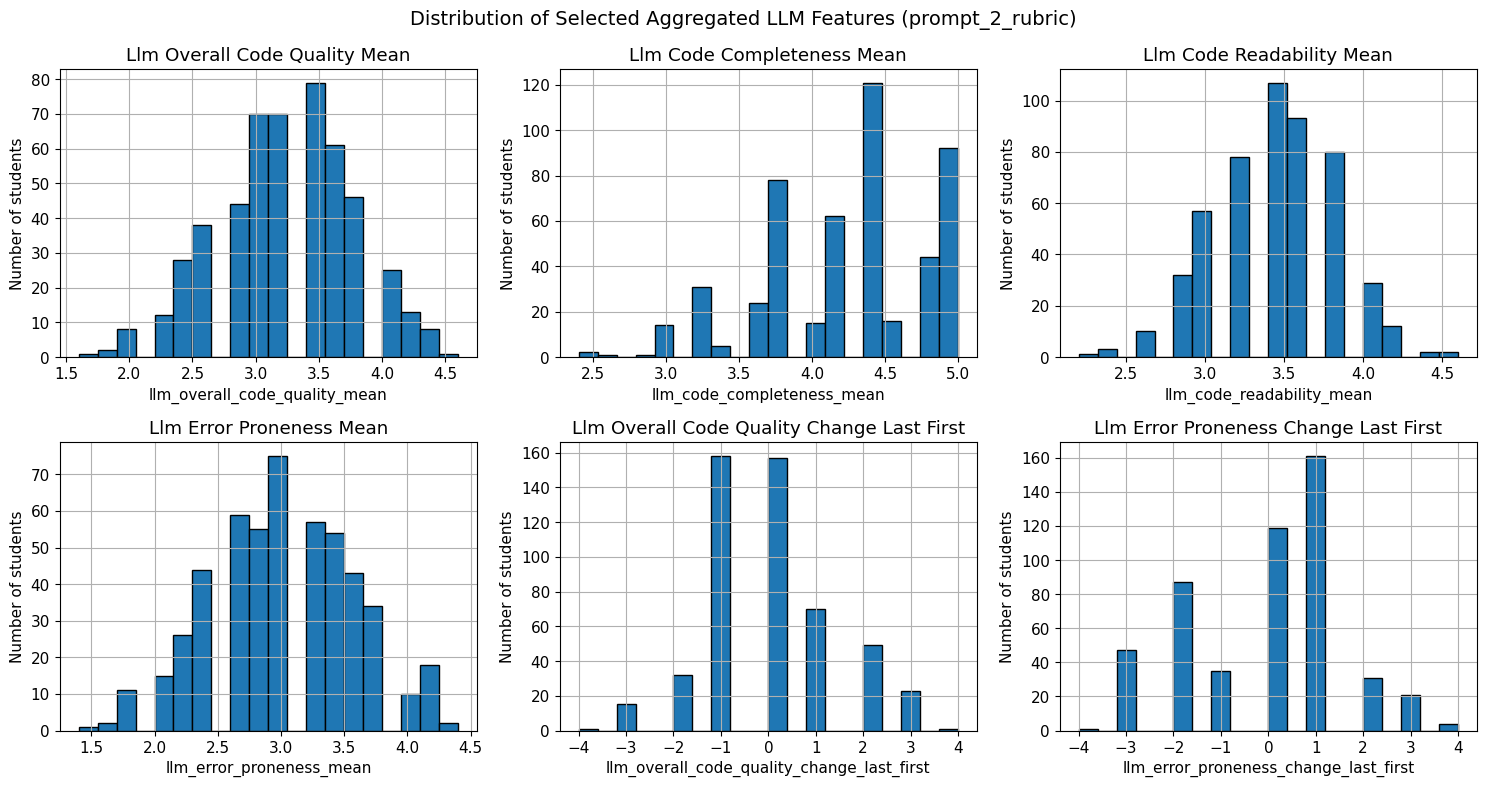

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/aggregated_llm_features_prompt_2_rubric.png


In [93]:
# Visual inspection of selected aggregated LLM features
selected_prompt = "prompt_2_rubric"
selected_llm_df = student_llm_features_by_prompt[selected_prompt]

selected_aggregated_features = [
    "llm_overall_code_quality_mean",
    "llm_code_completeness_mean",
    "llm_code_readability_mean",
    "llm_error_proneness_mean",
    "llm_overall_code_quality_change_last_first",
    "llm_error_proneness_change_last_first"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feature in zip(axes, selected_aggregated_features):
    ax.hist(selected_llm_df[feature], bins=20, edgecolor="black")
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of students")
    ax.grid(True)

plt.suptitle(f"Distribution of Selected Aggregated LLM Features ({selected_prompt})", fontsize=14)
plt.tight_layout()

figure_path = FIGURES_DIR / f"aggregated_llm_features_{selected_prompt}.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

## 9. Feature block definition

At this stage, the project has created several groups of student-level features.

The next step is to organise these variables into clear feature blocks. This is necessary because the main goal of the project is not only to build predictive models, but to compare how different types of information contribute to prediction.

The feature blocks are defined as follows:

1. **Traditional Learning Analytics features**: activity, performance, compilation, temporal, and regularity indicators.
2. **Structural code features**: simple measurable properties of the code, such as code length, number of lines, conditionals, loops, and returns.
3. **LLM semantic features**: semantic code features extracted with each prompt.
4. **Combined feature blocks**: combinations of traditional LA, structural code, and LLM semantic features.

This structure allows the modelling stage to answer the main research question: Do LLM-based semantic features improve predictive performance beyond traditional Learning Analytics features and simple structural code features?

In [94]:
# Common identifier and target columns
ID_COL = "SubjectID"
REGRESSION_TARGET = "X-Grade"
CLASSIFICATION_TARGET = "Pass"

TARGET_COLS = [ID_COL, REGRESSION_TARGET, CLASSIFICATION_TARGET]

print("Identifier and target columns:")
print(TARGET_COLS)

Identifier and target columns:
['SubjectID', 'X-Grade', 'Pass']


### 9.1 Base feature groups

The first step is to define the individual feature groups:

- Traditional Learning Analytics features.
- Structural code features.
- LLM semantic features for each prompt.

These groups will later be combined into modelling datasets.

In [95]:
# Traditional LA feature columns
traditional_la_feature_cols = [
    col for col in student_la_features.columns
    if col not in TARGET_COLS
]

# Structural code feature columns
structural_code_feature_cols = [
    col for col in student_structural_code_features.columns
    if col != ID_COL
]

# LLM feature columns by prompt
llm_feature_cols_by_prompt = {}

for prompt_name, df_prompt in student_llm_features_by_prompt.items():
    llm_feature_cols_by_prompt[prompt_name] = [
        col for col in df_prompt.columns
        if col not in [ID_COL, "prompt_name"]
    ]

print("Traditional LA features:", len(traditional_la_feature_cols))
print("Structural code features:", len(structural_code_feature_cols))

for prompt_name, cols in llm_feature_cols_by_prompt.items():
    print(f"LLM features - {prompt_name}: {len(cols)}")

Traditional LA features: 48
Structural code features: 108
LLM features - prompt_0_minimal: 54
LLM features - prompt_1_structured: 54
LLM features - prompt_2_rubric: 54


### 9.2 Modelling datasets

Several modelling datasets are created from the feature blocks.

Each dataset contains the same 506 students and the same target variables. The only difference between datasets is the group of predictive features included.

This makes the comparison between models fair and easy to interpret.

In [96]:
# Dictionary with all modelling datasets
modelling_datasets = {
    "traditional_LA_only": student_la_features,
    "traditional_LA_plus_structural": student_la_plus_structural
}

# Traditional LA + LLM datasets
for prompt_name, df_prompt in student_la_plus_llm_by_prompt.items():
    modelling_datasets[f"traditional_LA_plus_{prompt_name}"] = df_prompt

# Traditional LA + Structural + LLM datasets
for prompt_name, df_prompt in student_la_structural_plus_llm_by_prompt.items():
    modelling_datasets[f"traditional_LA_structural_plus_{prompt_name}"] = df_prompt

print("Modelling datasets:")
for name, df in modelling_datasets.items():
    print(name, df.shape)

Modelling datasets:
traditional_LA_only (506, 51)
traditional_LA_plus_structural (506, 159)
traditional_LA_plus_prompt_0_minimal (506, 105)
traditional_LA_plus_prompt_1_structured (506, 105)
traditional_LA_plus_prompt_2_rubric (506, 105)
traditional_LA_structural_plus_prompt_0_minimal (506, 213)
traditional_LA_structural_plus_prompt_1_structured (506, 213)
traditional_LA_structural_plus_prompt_2_rubric (506, 213)


In [97]:
# Feature columns for each modelling dataset
modelling_feature_sets = {}

for dataset_name, df_dataset in modelling_datasets.items():
    feature_cols = [
        col for col in df_dataset.columns
        if col not in TARGET_COLS
    ]
    
    modelling_feature_sets[dataset_name] = feature_cols

# Quick check
for dataset_name, cols in modelling_feature_sets.items():
    print(f"{dataset_name}: {len(cols)} predictive features")

traditional_LA_only: 48 predictive features
traditional_LA_plus_structural: 156 predictive features
traditional_LA_plus_prompt_0_minimal: 102 predictive features
traditional_LA_plus_prompt_1_structured: 102 predictive features
traditional_LA_plus_prompt_2_rubric: 102 predictive features
traditional_LA_structural_plus_prompt_0_minimal: 210 predictive features
traditional_LA_structural_plus_prompt_1_structured: 210 predictive features
traditional_LA_structural_plus_prompt_2_rubric: 210 predictive features


In [98]:
# Summary of final feature blocks
feature_block_rows = []

feature_block_rows.append({
    "feature_block": "Traditional LA",
    "description": "Activity, performance, compilation, temporal and regularity features",
    "n_features": len(traditional_la_feature_cols)
})

feature_block_rows.append({
    "feature_block": "Structural code",
    "description": "Simple code size and structure indicators",
    "n_features": len(structural_code_feature_cols)
})

for prompt_name, cols in llm_feature_cols_by_prompt.items():
    feature_block_rows.append({
        "feature_block": f"LLM semantic features ({prompt_name})",
        "description": "Aggregated semantic code features extracted with the LLM",
        "n_features": len(cols)
    })

feature_block_summary = pd.DataFrame(feature_block_rows)

feature_block_summary

,feature_block,description,n_features
0,Traditional LA,"Activity, performance, compilation, temporal a...",48
1,Structural code,Simple code size and structure indicators,108
2,LLM semantic features (prompt_0_minimal),Aggregated semantic code features extracted wi...,54
3,LLM semantic features (prompt_1_structured),Aggregated semantic code features extracted wi...,54
4,LLM semantic features (prompt_2_rubric),Aggregated semantic code features extracted wi...,54


In [99]:
# Summary of modelling datasets
dataset_summary_rows = []

for dataset_name, df_dataset in modelling_datasets.items():
    dataset_summary_rows.append({
        "dataset": dataset_name,
        "n_students": df_dataset[ID_COL].nunique(),
        "n_total_columns": df_dataset.shape[1],
        "n_predictive_features": len(modelling_feature_sets[dataset_name]),
        "missing_values": df_dataset.isna().sum().sum()
    })

modelling_dataset_summary = pd.DataFrame(dataset_summary_rows)

modelling_dataset_summary

,dataset,n_students,n_total_columns,n_predictive_features,missing_values
0,traditional_LA_only,506,51,48,0
1,traditional_LA_plus_structural,506,159,156,0
2,traditional_LA_plus_prompt_0_minimal,506,105,102,0
3,traditional_LA_plus_prompt_1_structured,506,105,102,0
4,traditional_LA_plus_prompt_2_rubric,506,105,102,0
5,traditional_LA_structural_plus_prompt_0_minimal,506,213,210,0
6,traditional_LA_structural_plus_prompt_1_struct...,506,213,210,0
7,traditional_LA_structural_plus_prompt_2_rubric,506,213,210,0


### 9.3 Safety checks before modelling

Before training models, several checks are performed.

These checks confirm that:

- All modelling datasets contain the same students.
- Target columns are not included as predictive features.
- There are no missing values.
- All predictive features are numeric.

This is important to avoid data leakage and technical problems during model training.

In [100]:
# Check that all datasets contain the same students
reference_students = set(student_la_features[ID_COL])

student_consistency_rows = []

for dataset_name, df_dataset in modelling_datasets.items():
    dataset_students = set(df_dataset[ID_COL])
    
    student_consistency_rows.append({
        "dataset": dataset_name,
        "same_students_as_baseline": dataset_students == reference_students,
        "n_students": len(dataset_students),
        "missing_students_vs_baseline": len(reference_students - dataset_students),
        "extra_students_vs_baseline": len(dataset_students - reference_students)
    })

student_consistency_check = pd.DataFrame(student_consistency_rows)

student_consistency_check

,dataset,same_students_as_baseline,n_students,missing_students_vs_baseline,extra_students_vs_baseline
0,traditional_LA_only,True,506,0,0
1,traditional_LA_plus_structural,True,506,0,0
2,traditional_LA_plus_prompt_0_minimal,True,506,0,0
3,traditional_LA_plus_prompt_1_structured,True,506,0,0
4,traditional_LA_plus_prompt_2_rubric,True,506,0,0
5,traditional_LA_structural_plus_prompt_0_minimal,True,506,0,0
6,traditional_LA_structural_plus_prompt_1_struct...,True,506,0,0
7,traditional_LA_structural_plus_prompt_2_rubric,True,506,0,0


In [101]:
# Check that targets are not included in predictive feature columns
leakage_check_rows = []

for dataset_name, feature_cols in modelling_feature_sets.items():
    forbidden_cols_present = [
        col for col in [ID_COL, REGRESSION_TARGET, CLASSIFICATION_TARGET]
        if col in feature_cols
    ]
    
    leakage_check_rows.append({
        "dataset": dataset_name,
        "forbidden_columns_in_features": forbidden_cols_present,
        "leakage_check_passed": len(forbidden_cols_present) == 0
    })

leakage_check = pd.DataFrame(leakage_check_rows)

leakage_check

,dataset,forbidden_columns_in_features,leakage_check_passed
0,traditional_LA_only,[],True
1,traditional_LA_plus_structural,[],True
2,traditional_LA_plus_prompt_0_minimal,[],True
3,traditional_LA_plus_prompt_1_structured,[],True
4,traditional_LA_plus_prompt_2_rubric,[],True
5,traditional_LA_structural_plus_prompt_0_minimal,[],True
6,traditional_LA_structural_plus_prompt_1_struct...,[],True
7,traditional_LA_structural_plus_prompt_2_rubric,[],True


In [102]:
# Check that all predictive features are numeric
numeric_check_rows = []

for dataset_name, df_dataset in modelling_datasets.items():
    feature_cols = modelling_feature_sets[dataset_name]
    
    non_numeric_cols = [
        col for col in feature_cols
        if not pd.api.types.is_numeric_dtype(df_dataset[col])
    ]
    
    numeric_check_rows.append({
        "dataset": dataset_name,
        "n_predictive_features": len(feature_cols),
        "n_non_numeric_features": len(non_numeric_cols),
        "non_numeric_features": non_numeric_cols[:10]
    })

numeric_check = pd.DataFrame(numeric_check_rows)

numeric_check

,dataset,n_predictive_features,n_non_numeric_features,non_numeric_features
0,traditional_LA_only,48,0,[]
1,traditional_LA_plus_structural,156,0,[]
2,traditional_LA_plus_prompt_0_minimal,102,0,[]
3,traditional_LA_plus_prompt_1_structured,102,0,[]
4,traditional_LA_plus_prompt_2_rubric,102,0,[]
5,traditional_LA_structural_plus_prompt_0_minimal,210,0,[]
6,traditional_LA_structural_plus_prompt_1_struct...,210,0,[]
7,traditional_LA_structural_plus_prompt_2_rubric,210,0,[]


In [103]:
# Save summaries for documentation
feature_block_summary.to_csv(
    TABLES_DIR / "feature_block_summary.csv",
    index=False
)

modelling_dataset_summary.to_csv(
    TABLES_DIR / "modelling_dataset_summary.csv",
    index=False
)

student_consistency_check.to_csv(
    TABLES_DIR / "student_consistency_check.csv",
    index=False
)

leakage_check.to_csv(
    TABLES_DIR / "leakage_check.csv",
    index=False
)

numeric_check.to_csv(
    TABLES_DIR / "numeric_feature_check.csv",
    index=False
)

print("Feature block summaries saved.")

Feature block summaries saved.


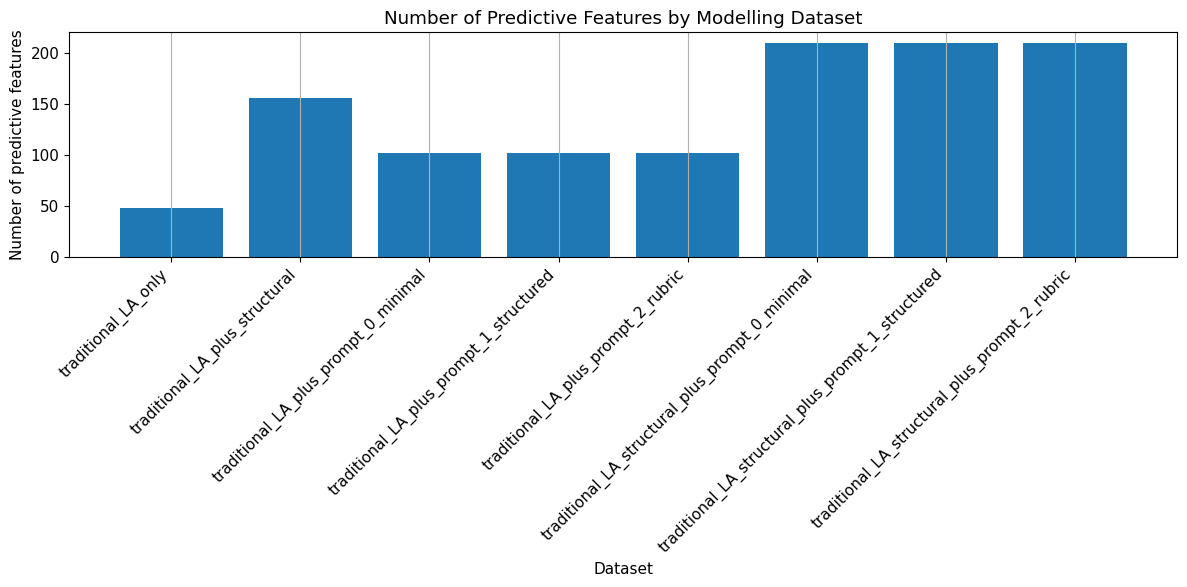

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/predictive_features_by_dataset.png


In [104]:
# Visual comparison of the number of predictive features per modelling dataset
plt.figure(figsize=(12, 6))

plt.bar(
    modelling_dataset_summary["dataset"],
    modelling_dataset_summary["n_predictive_features"]
)

plt.title("Number of Predictive Features by Modelling Dataset")
plt.xlabel("Dataset")
plt.ylabel("Number of predictive features")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()

figure_path = FIGURES_DIR / "predictive_features_by_dataset.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

## 10. Fixed-point predictive modelling

This section evaluates the predictive performance of the different feature blocks created in the previous sections.

The goal is to compare whether adding structural code features and LLM-based semantic features improves prediction compared with the traditional Learning Analytics baseline.

Two prediction tasks are evaluated:

1. **Regression task**: predicting the final numerical grade (`X-Grade`).
2. **Classification task**: predicting whether the student passes or fails (`Pass`).

Before comparing models, the student-level dataset is divided into a training set and a hold-out test set. The training set is used in this section for model and prompt comparison through cross-validation. The hold-out test set is kept untouched and will only be used later for final validation.

This avoids using the same data both to select the best model and to report the final performance.

The modelling datasets compared in this section are:

- Traditional Learning Analytics only.
- Traditional Learning Analytics + structural code features.
- Traditional Learning Analytics + LLM features from each prompt.
- Traditional Learning Analytics + structural code features + LLM features from each prompt.

This section is called a fixed-point evaluation because it uses the student-level features computed from the available course data. Later, the temporal evaluation will analyse how performance evolves at different moments of the learning trajectory.

### 10.0 Train-test split for model comparison

Before comparing predictive models, the student-level dataset is divided into a training set and a hold-out test set.

The training set is used in this section to compare models and feature blocks through cross-validation. The hold-out test set is kept untouched and will only be used later for the final validation.

The split is stratified using the `Pass` variable. This keeps a similar proportion of passing and failing students in both train and test sets.

In [105]:
# Train-test split based on students
train_ids, test_ids = train_test_split(
    student_la_features["SubjectID"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=student_la_features[CLASSIFICATION_TARGET]
)

train_ids = set(train_ids)
test_ids = set(test_ids)

print("Train students:", len(train_ids))
print("Test students:", len(test_ids))
print("Total students:", len(train_ids) + len(test_ids))

Train students: 404
Test students: 102
Total students: 506


In [106]:
# Create train and test versions of all modelling datasets
modelling_datasets_train = {}
modelling_datasets_test = {}

for dataset_name, df_dataset in modelling_datasets.items():
    modelling_datasets_train[dataset_name] = (
        df_dataset[df_dataset["SubjectID"].isin(train_ids)]
        .reset_index(drop=True)
    )
    
    modelling_datasets_test[dataset_name] = (
        df_dataset[df_dataset["SubjectID"].isin(test_ids)]
        .reset_index(drop=True)
    )

# Check split dimensions
split_summary_rows = []

for dataset_name in modelling_datasets.keys():
    split_summary_rows.append({
        "dataset": dataset_name,
        "train_students": modelling_datasets_train[dataset_name]["SubjectID"].nunique(),
        "test_students": modelling_datasets_test[dataset_name]["SubjectID"].nunique(),
        "train_rows": modelling_datasets_train[dataset_name].shape[0],
        "test_rows": modelling_datasets_test[dataset_name].shape[0]
    })

split_summary = pd.DataFrame(split_summary_rows)

split_summary

,dataset,train_students,test_students,train_rows,test_rows
0,traditional_LA_only,404,102,404,102
1,traditional_LA_plus_structural,404,102,404,102
2,traditional_LA_plus_prompt_0_minimal,404,102,404,102
3,traditional_LA_plus_prompt_1_structured,404,102,404,102
4,traditional_LA_plus_prompt_2_rubric,404,102,404,102
5,traditional_LA_structural_plus_prompt_0_minimal,404,102,404,102
6,traditional_LA_structural_plus_prompt_1_struct...,404,102,404,102
7,traditional_LA_structural_plus_prompt_2_rubric,404,102,404,102


In [107]:
# Check class balance in train and test
split_balance = pd.DataFrame({
    "split": ["train", "test"],
    "n_students": [
        len(train_ids),
        len(test_ids)
    ],
    "pass_rate": [
        student_la_features[student_la_features["SubjectID"].isin(train_ids)][CLASSIFICATION_TARGET].mean(),
        student_la_features[student_la_features["SubjectID"].isin(test_ids)][CLASSIFICATION_TARGET].mean()
    ]
})

split_balance["pass_rate"] = split_balance["pass_rate"] * 100

split_balance

,split,n_students,pass_rate
0,train,404,52.2277
1,test,102,51.9608


### 10.1 Model setup

Several regression and classification algorithms are compared.

- For **regression**, the target is the final numerical grade `X-Grade`.

- For **classification**, the target is the binary variable `Pass`.

The models include both simple and more flexible algorithms. Linear models provide a useful baseline, while tree-based models can capture non-linear relationships between features.

A dummy model is also included in each task. This gives a basic reference point to check whether the real models are learning useful information.

In [108]:
# Regression and classification models
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.base import clone
from sklearn.model_selection import RepeatedKFold, RepeatedStratifiedKFold

# Cross-validation settings on the training set
N_SPLITS = 5
N_REPEATS = 3

regression_cv = RepeatedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

classification_cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

# Regression models
regression_models = {
    "Dummy Mean": DummyRegressor(strategy="mean"),
    
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, max_iter=10000, random_state=RANDOM_STATE))
    ]),
    
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=1.0, epsilon=0.1))
    ]),
    
    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE
    ),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

# Classification models
classification_models = {
    "Dummy Most Frequent": DummyClassifier(strategy="most_frequent"),
    
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
    ]),
    
    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

print("Regression models:", list(regression_models.keys()))
print("Classification models:", list(classification_models.keys()))

Regression models: ['Dummy Mean', 'Linear Regression', 'Ridge', 'Lasso', 'SVR', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
Classification models: ['Dummy Most Frequent', 'Logistic Regression', 'SVC', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


### 10.2 Evaluation functions

The following functions evaluate the models using cross-validation on the training set.

For **regression**, the metrics are:

- $`R^2`$: proportion of variance explained by the model.
- `MAE`: mean absolute error.
- `RMSE`: root mean squared error.

For **classification**, the metrics are:

- `AUC`: area under the ROC curve.
- `Accuracy`: proportion of correct predictions.
- `Precision`: proportion of predicted passing students who actually pass.
- `Recall`: proportion of passing students correctly detected.
- `F1`: harmonic mean of precision and recall.

In [109]:
def prepare_X_y(df, feature_cols, target_col):
    """Prepare feature matrix and target vector."""
    
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    
    # Replace infinite values and fill possible missing values
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)
    
    return X, y


def evaluate_regression_model(model, X, y, cv):
    """Evaluate one regression model with cross-validation."""
    
    r2_scores = []
    mae_scores = []
    rmse_scores = []
    
    for train_idx, val_idx in cv.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
        
        fitted_model = clone(model)
        fitted_model.fit(X_train_cv, y_train_cv)
        
        y_pred = fitted_model.predict(X_val_cv)
        
        r2_scores.append(r2_score(y_val_cv, y_pred))
        mae_scores.append(mean_absolute_error(y_val_cv, y_pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val_cv, y_pred)))
    
    return {
        "r2_mean": np.mean(r2_scores),
        "r2_std": np.std(r2_scores),
        "mae_mean": np.mean(mae_scores),
        "mae_std": np.std(mae_scores),
        "rmse_mean": np.mean(rmse_scores),
        "rmse_std": np.std(rmse_scores)
    }


def get_classification_scores(fitted_model, X_val):
    """Get probability-like scores for AUC calculation."""
    
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X_val)[:, 1]
    
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X_val)
    
    return fitted_model.predict(X_val)


def evaluate_classification_model(model, X, y, cv):
    """Evaluate one classification model with cross-validation."""
    
    auc_scores = []
    accuracy_scores_list = []
    precision_scores_list = []
    recall_scores_list = []
    f1_scores_list = []
    
    for train_idx, val_idx in cv.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
        
        fitted_model = clone(model)
        fitted_model.fit(X_train_cv, y_train_cv)
        
        y_pred = fitted_model.predict(X_val_cv)
        y_score = get_classification_scores(fitted_model, X_val_cv)
        
        auc_scores.append(roc_auc_score(y_val_cv, y_score))
        accuracy_scores_list.append(accuracy_score(y_val_cv, y_pred))
        precision_scores_list.append(precision_score(y_val_cv, y_pred, zero_division=0))
        recall_scores_list.append(recall_score(y_val_cv, y_pred, zero_division=0))
        f1_scores_list.append(f1_score(y_val_cv, y_pred, zero_division=0))
    
    return {
        "auc_mean": np.mean(auc_scores),
        "auc_std": np.std(auc_scores),
        "accuracy_mean": np.mean(accuracy_scores_list),
        "accuracy_std": np.std(accuracy_scores_list),
        "precision_mean": np.mean(precision_scores_list),
        "precision_std": np.std(precision_scores_list),
        "recall_mean": np.mean(recall_scores_list),
        "recall_std": np.std(recall_scores_list),
        "f1_mean": np.mean(f1_scores_list),
        "f1_std": np.std(f1_scores_list)
    }

### 10.3 Regression comparison on the training set

The regression task predicts the final numerical grade `X-Grade`.

Each regression model is trained and evaluated using repeated cross-validation on the training set only. This allows us to compare how the feature blocks affect the prediction of final grades without using the hold-out test set.

In [ ]:
# Fixed-point regression results
# Load saved results if available; otherwise compute them

from pathlib import Path
import pandas as pd

TABLES_DIR = Path("outputs/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

regression_results_path = TABLES_DIR / "fixed_point_regression_results_train_cv.csv"

# 1. Load saved regression results if they already exist

if regression_results_path.exists():
    
    regression_results = pd.read_csv(regression_results_path)
    print(f"Loaded regression results from: {regression_results_path}")

else:
    
    # 2. Otherwise, compute regression results from scratch
    
    
    required_objects = [
        "modelling_datasets_train",
        "modelling_feature_sets",
        "prepare_X_y",
        "REGRESSION_TARGET",
        "regression_models",
        "regression_cv",
        "evaluate_regression_model"
    ]
    
    missing_objects = [
        obj for obj in required_objects
        if obj not in globals()
    ]
    
    if missing_objects:
        raise NameError(
            "Cannot compute regression results because these objects are missing: "
            + ", ".join(missing_objects)
            + ". Either run the modelling setup cells first or keep the saved CSV file."
        )
    
    regression_results_rows = []
    
    for dataset_name, df_dataset in modelling_datasets_train.items():
        
        feature_cols = modelling_feature_sets[dataset_name]
        X, y = prepare_X_y(df_dataset, feature_cols, REGRESSION_TARGET)
        
        print(f"Evaluating regression dataset: {dataset_name}")
        
        for model_name, model in regression_models.items():
            
            metrics = evaluate_regression_model(
                model=model,
                X=X,
                y=y,
                cv=regression_cv
            )
            
            regression_results_rows.append({
                "dataset": dataset_name,
                "model": model_name,
                "n_features": len(feature_cols),
                **metrics
            })
    
    regression_results = pd.DataFrame(regression_results_rows)
    
    regression_results = regression_results.sort_values(
        ["rmse_mean", "mae_mean"],
        ascending=[True, True]
    ).reset_index(drop=True)
    
    regression_results.to_csv(regression_results_path, index=False)
    print(f"Computed and saved regression results to: {regression_results_path}")


# 3. Display top results

display(regression_results.head(15))

NameError: name 'modelling_datasets_train' is not defined

In [111]:
# Best regression model per dataset
best_regression_by_dataset = (
    regression_results
    .sort_values(["dataset", "rmse_mean"])
    .groupby("dataset")
    .first()
    .reset_index()
    .sort_values("rmse_mean")
)

best_regression_by_dataset

,dataset,model,n_features,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
0,traditional_LA_only,Ridge,48,0.3611,0.1056,12.3726,1.1101,15.4071,1.5039
2,traditional_LA_plus_prompt_1_structured,Random Forest,102,0.3319,0.0824,12.2043,1.0883,15.7854,1.3265
5,traditional_LA_structural_plus_prompt_0_minimal,Random Forest,210,0.3299,0.0809,12.1904,0.9353,15.8062,1.2469
1,traditional_LA_plus_prompt_0_minimal,Gradient Boosting,102,0.3294,0.0872,12.4758,1.0116,15.8099,1.3574
7,traditional_LA_structural_plus_prompt_2_rubric,Random Forest,210,0.3272,0.0820,12.2065,0.8826,15.8360,1.2333
6,traditional_LA_structural_plus_prompt_1_struct...,Random Forest,210,0.3271,0.0819,12.2113,0.8770,15.8362,1.2230
4,traditional_LA_plus_structural,Random Forest,156,0.3272,0.0790,12.1997,0.9238,15.8395,1.2292
3,traditional_LA_plus_prompt_2_rubric,Random Forest,102,0.3229,0.0810,12.3007,1.1182,15.8981,1.3785


In [112]:
# Save regression results
regression_results_path = TABLES_DIR / "fixed_point_regression_results_train_cv.csv"
best_regression_path = TABLES_DIR / "fixed_point_best_regression_by_dataset_train_cv.csv"

regression_results.to_csv(regression_results_path, index=False)
best_regression_by_dataset.to_csv(best_regression_path, index=False)

print(f"Regression results saved in: {regression_results_path}")
print(f"Best regression results saved in: {best_regression_path}")

Regression results saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/fixed_point_regression_results_train_cv.csv
Best regression results saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/fixed_point_best_regression_by_dataset_train_cv.csv


### 10.4 Classification comparison on the training set

The classification task predicts whether a student passes or fails.

The target variable is `Pass`, where:

- `1` means the student passed.
- `0` means the student did not pass.

Each classification model is trained and evaluated using repeated stratified cross-validation on the training set only.

The main metric used to compare models is AUC, because it evaluates how well the model separates passing and failing students across different decision thresholds.

In [113]:
# Run classification comparison on the training set
classification_results_rows = []

for dataset_name, df_dataset in modelling_datasets_train.items():
    
    feature_cols = modelling_feature_sets[dataset_name]
    X, y = prepare_X_y(df_dataset, feature_cols, CLASSIFICATION_TARGET)
    y = y.astype(int)
    
    print(f"Evaluating classification dataset: {dataset_name}")
    
    for model_name, model in classification_models.items():
        print(f"  Model: {model_name}")
        
        metrics = evaluate_classification_model(
            model=model,
            X=X,
            y=y,
            cv=classification_cv
        )
        
        classification_results_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "n_features": len(feature_cols),
            **metrics
        })

classification_results = pd.DataFrame(classification_results_rows)

classification_results = classification_results.sort_values(
    ["auc_mean", "f1_mean"],
    ascending=[False, False]
).reset_index(drop=True)

classification_results.head(15)

Evaluating classification dataset: traditional_LA_only
  Model: Dummy Most Frequent
  Model: Logistic Regression
  Model: SVC
  Model: Decision Tree
  Model: Random Forest
  Model: Gradient Boosting
Evaluating classification dataset: traditional_LA_plus_structural
  Model: Dummy Most Frequent
  Model: Logistic Regression
  Model: SVC
  Model: Decision Tree
  Model: Random Forest
  Model: Gradient Boosting
Evaluating classification dataset: traditional_LA_plus_prompt_0_minimal
  Model: Dummy Most Frequent
  Model: Logistic Regression
  Model: SVC
  Model: Decision Tree
  Model: Random Forest
  Model: Gradient Boosting
Evaluating classification dataset: traditional_LA_plus_prompt_1_structured
  Model: Dummy Most Frequent
  Model: Logistic Regression
  Model: SVC
  Model: Decision Tree
  Model: Random Forest
  Model: Gradient Boosting
Evaluating classification dataset: traditional_LA_plus_prompt_2_rubric
  Model: Dummy Most Frequent
  Model: Logistic Regression
  Model: SVC
  Model: Decis

,dataset,model,n_features,auc_mean,auc_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,traditional_LA_structural_plus_prompt_1_struct...,Random Forest,210,0.8149,0.0500,0.7516,0.0408,0.7789,0.0427,0.7379,0.0853,0.7544,0.0471
1,traditional_LA_only,SVC,48,0.8139,0.0488,0.7450,0.0471,0.7581,0.0607,0.7632,0.0716,0.7573,0.0436
2,traditional_LA_plus_structural,Random Forest,156,0.8128,0.0529,0.7624,0.0541,0.7865,0.0480,0.7522,0.0971,0.7654,0.0601
3,traditional_LA_structural_plus_prompt_0_minimal,Random Forest,210,0.8095,0.0510,0.7516,0.0503,0.7780,0.0432,0.7379,0.1041,0.7532,0.0600
4,traditional_LA_structural_plus_prompt_2_rubric,Random Forest,210,0.8087,0.0525,0.7566,0.0495,0.7817,0.0456,0.7458,0.0956,0.7595,0.0568
5,traditional_LA_structural_plus_prompt_0_minimal,SVC,210,0.8067,0.0563,0.7426,0.0532,0.7753,0.0538,0.7193,0.0936,0.7427,0.0602
6,traditional_LA_plus_structural,SVC,156,0.8057,0.0504,0.7418,0.0475,0.7733,0.0470,0.7193,0.0860,0.7424,0.0538
7,traditional_LA_plus_prompt_0_minimal,SVC,102,0.8050,0.0501,0.7458,0.0520,0.7574,0.0584,0.7663,0.0958,0.7570,0.0568
8,traditional_LA_only,Logistic Regression,48,0.8044,0.0564,0.7293,0.0642,0.7489,0.0655,0.7330,0.0961,0.7372,0.0653
9,traditional_LA_structural_plus_prompt_2_rubric,SVC,210,0.8033,0.0520,0.7369,0.0488,0.7773,0.0519,0.7002,0.0843,0.7337,0.0543


In [114]:
# Best classification model per dataset
best_classification_by_dataset = (
    classification_results
    .sort_values(["dataset", "auc_mean"], ascending=[True, False])
    .groupby("dataset")
    .first()
    .reset_index()
    .sort_values("auc_mean", ascending=False)
)

best_classification_by_dataset

,dataset,model,n_features,auc_mean,auc_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
6,traditional_LA_structural_plus_prompt_1_struct...,Random Forest,210,0.8149,0.0500,0.7516,0.0408,0.7789,0.0427,0.7379,0.0853,0.7544,0.0471
0,traditional_LA_only,SVC,48,0.8139,0.0488,0.7450,0.0471,0.7581,0.0607,0.7632,0.0716,0.7573,0.0436
4,traditional_LA_plus_structural,Random Forest,156,0.8128,0.0529,0.7624,0.0541,0.7865,0.0480,0.7522,0.0971,0.7654,0.0601
5,traditional_LA_structural_plus_prompt_0_minimal,Random Forest,210,0.8095,0.0510,0.7516,0.0503,0.7780,0.0432,0.7379,0.1041,0.7532,0.0600
7,traditional_LA_structural_plus_prompt_2_rubric,Random Forest,210,0.8087,0.0525,0.7566,0.0495,0.7817,0.0456,0.7458,0.0956,0.7595,0.0568
1,traditional_LA_plus_prompt_0_minimal,SVC,102,0.8050,0.0501,0.7458,0.0520,0.7574,0.0584,0.7663,0.0958,0.7570,0.0568
3,traditional_LA_plus_prompt_2_rubric,SVC,102,0.8000,0.0509,0.7194,0.0528,0.7430,0.0623,0.7205,0.0943,0.7265,0.0574
2,traditional_LA_plus_prompt_1_structured,Random Forest,102,0.7988,0.0459,0.7458,0.0480,0.7546,0.0439,0.7647,0.0871,0.7569,0.0518


In [115]:
# Save classification results
classification_results_path = TABLES_DIR / "fixed_point_classification_results_train_cv.csv"
best_classification_path = TABLES_DIR / "fixed_point_best_classification_by_dataset_train_cv.csv"

classification_results.to_csv(classification_results_path, index=False)
best_classification_by_dataset.to_csv(best_classification_path, index=False)

print(f"Classification results saved in: {classification_results_path}")
print(f"Best classification results saved in: {best_classification_path}")

Classification results saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/fixed_point_classification_results_train_cv.csv
Best classification results saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/fixed_point_best_classification_by_dataset_train_cv.csv


### 10.5 Visual comparison of best results

The following plots compare the best model obtained for each feature block.

- For **regression**, lower RMSE indicates better performance.

- For **classification**, higher AUC indicates better performance.

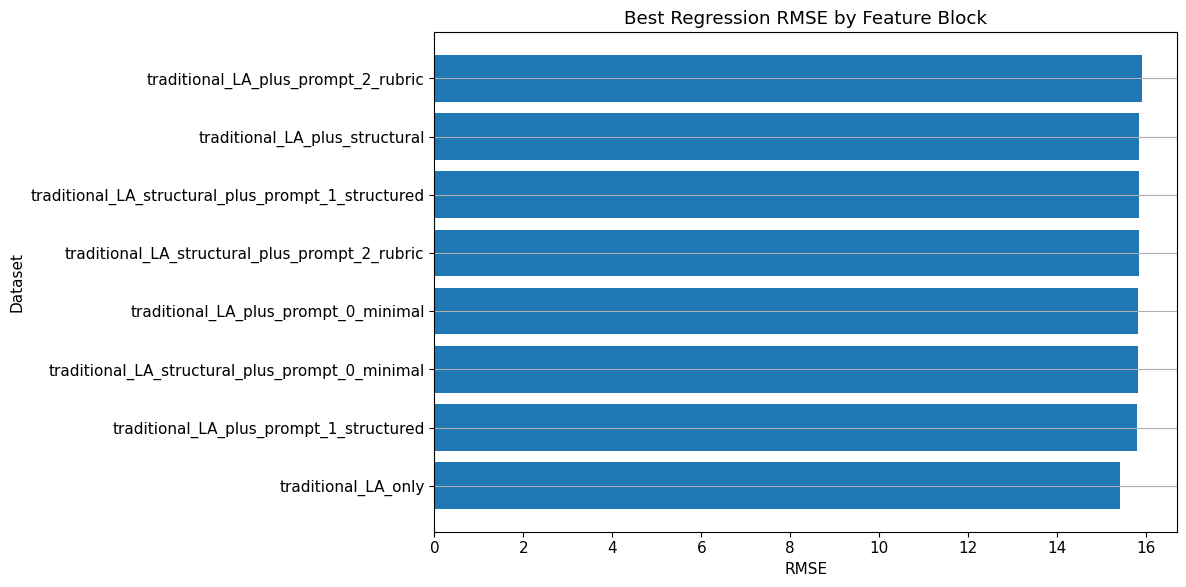

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/fixed_point_best_regression_rmse_train_cv.png


In [116]:
# Plot best regression RMSE by dataset
plot_df = best_regression_by_dataset.sort_values("rmse_mean", ascending=True)

plt.figure(figsize=(12, 6))

plt.barh(
    plot_df["dataset"],
    plot_df["rmse_mean"]
)

plt.xlabel("RMSE")
plt.ylabel("Dataset")
plt.title("Best Regression RMSE by Feature Block")
plt.grid(axis="x")
plt.tight_layout()

figure_path = FIGURES_DIR / "fixed_point_best_regression_rmse_train_cv.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

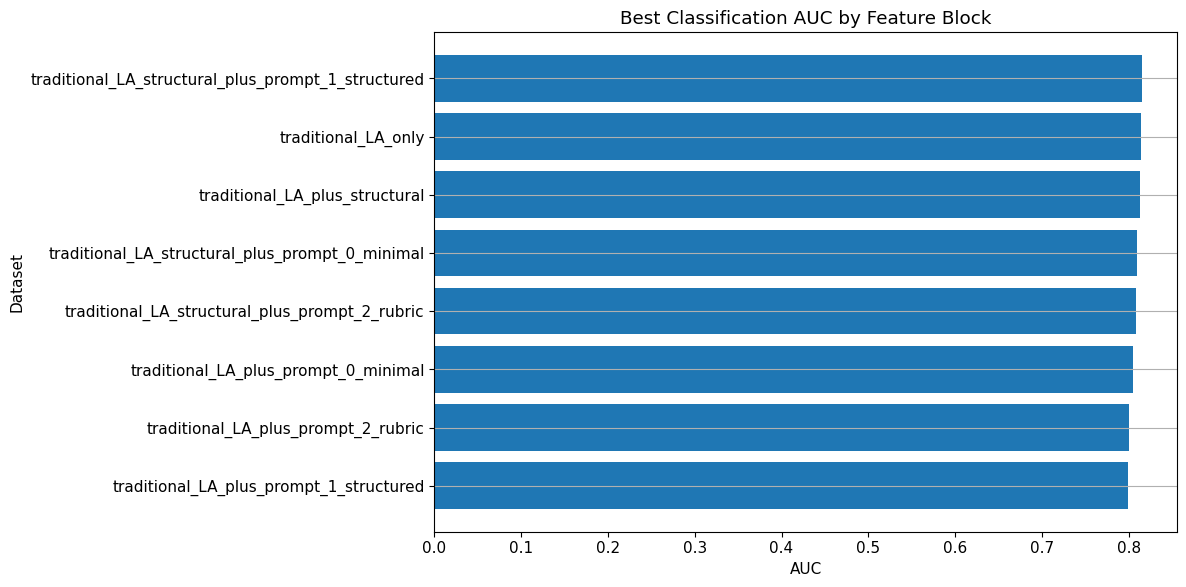

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/fixed_point_best_classification_auc_train_cv.png


In [117]:
# Plot best classification AUC by dataset
plot_df = best_classification_by_dataset.sort_values("auc_mean", ascending=True)

plt.figure(figsize=(12, 6))

plt.barh(
    plot_df["dataset"],
    plot_df["auc_mean"]
)

plt.xlabel("AUC")
plt.ylabel("Dataset")
plt.title("Best Classification AUC by Feature Block")
plt.grid(axis="x")
plt.tight_layout()

figure_path = FIGURES_DIR / "fixed_point_best_classification_auc_train_cv.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

### 10.6 Prompt comparison

The LLM features were generated using three different prompt designs. This section compares the best fixed-point performance obtained by each prompt.

This comparison helps identify which prompt produces the most useful semantic features for prediction.

The prompt comparison is still based only on the training set. The hold-out test set will be used later for final validation.

In [118]:
# Extract best results for prompt-specific datasets
prompt_comparison_rows = []

prompt_names = sorted(student_llm_features_by_prompt.keys())

for prompt_name in prompt_names:
    
    la_llm_dataset = f"traditional_LA_plus_{prompt_name}"
    full_dataset = f"traditional_LA_structural_plus_{prompt_name}"
    
    # Regression
    reg_la_llm = best_regression_by_dataset[
        best_regression_by_dataset["dataset"] == la_llm_dataset
    ].iloc[0]
    
    reg_full = best_regression_by_dataset[
        best_regression_by_dataset["dataset"] == full_dataset
    ].iloc[0]
    
    # Classification
    clf_la_llm = best_classification_by_dataset[
        best_classification_by_dataset["dataset"] == la_llm_dataset
    ].iloc[0]
    
    clf_full = best_classification_by_dataset[
        best_classification_by_dataset["dataset"] == full_dataset
    ].iloc[0]
    
    prompt_comparison_rows.append({
        "prompt_name": prompt_name,
        "LA_plus_LLM_best_regression_model": reg_la_llm["model"],
        "LA_plus_LLM_RMSE": reg_la_llm["rmse_mean"],
        "LA_plus_LLM_R2": reg_la_llm["r2_mean"],
        "Full_best_regression_model": reg_full["model"],
        "Full_RMSE": reg_full["rmse_mean"],
        "Full_R2": reg_full["r2_mean"],
        "LA_plus_LLM_best_classification_model": clf_la_llm["model"],
        "LA_plus_LLM_AUC": clf_la_llm["auc_mean"],
        "LA_plus_LLM_F1": clf_la_llm["f1_mean"],
        "Full_best_classification_model": clf_full["model"],
        "Full_AUC": clf_full["auc_mean"],
        "Full_F1": clf_full["f1_mean"]
    })

prompt_fixed_point_comparison = pd.DataFrame(prompt_comparison_rows)

prompt_fixed_point_comparison

,prompt_name,LA_plus_LLM_best_regression_model,LA_plus_LLM_RMSE,LA_plus_LLM_R2,Full_best_regression_model,Full_RMSE,Full_R2,LA_plus_LLM_best_classification_model,LA_plus_LLM_AUC,LA_plus_LLM_F1,Full_best_classification_model,Full_AUC,Full_F1
0,prompt_0_minimal,Gradient Boosting,15.8099,0.3294,Random Forest,15.8062,0.3299,SVC,0.8050,0.7570,Random Forest,0.8095,0.7532
1,prompt_1_structured,Random Forest,15.7854,0.3319,Random Forest,15.8362,0.3271,Random Forest,0.7988,0.7569,Random Forest,0.8149,0.7544
2,prompt_2_rubric,Random Forest,15.8981,0.3229,Random Forest,15.8360,0.3272,SVC,0.8000,0.7265,Random Forest,0.8087,0.7595


In [119]:
# Save prompt fixed-point comparison
prompt_fixed_point_path = TABLES_DIR / "fixed_point_prompt_comparison_train_cv.csv"

prompt_fixed_point_comparison.to_csv(
    prompt_fixed_point_path,
    index=False
)

print(f"Prompt comparison saved in: {prompt_fixed_point_path}")

Prompt comparison saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/fixed_point_prompt_comparison_train_cv.csv


### 10.7 Improvement over the traditional Learning Analytics baseline

This section compares each enriched dataset against the traditional Learning Analytics baseline.

- For **regression**, improvement is measured as the reduction in RMSE.

- For **classification**, improvement is measured as the increase in AUC.

Positive values indicate improvement over the traditional Learning Analytics baseline.

In [122]:
# Baseline performance
baseline_regression = best_regression_by_dataset[
    best_regression_by_dataset["dataset"] == "traditional_LA_only"
].iloc[0]

baseline_classification = best_classification_by_dataset[
    best_classification_by_dataset["dataset"] == "traditional_LA_only"
].iloc[0]

baseline_rmse = baseline_regression["rmse_mean"]
baseline_auc = baseline_classification["auc_mean"]

# Improvement table
improvement_rows = []

for _, row in best_regression_by_dataset.iterrows():
    dataset_name = row["dataset"]
    
    clf_row = best_classification_by_dataset[
        best_classification_by_dataset["dataset"] == dataset_name
    ].iloc[0]
    
    improvement_rows.append({
        "dataset": dataset_name,
        "best_regression_model": row["model"],
        "rmse_mean": row["rmse_mean"],
        "rmse_improvement_vs_LA": baseline_rmse - row["rmse_mean"],
        "r2_mean": row["r2_mean"],
        "best_classification_model": clf_row["model"],
        "auc_mean": clf_row["auc_mean"],
        "auc_improvement_vs_LA": clf_row["auc_mean"] - baseline_auc,
        "f1_mean": clf_row["f1_mean"]
    })

fixed_point_improvement = pd.DataFrame(improvement_rows)

fixed_point_improvement = fixed_point_improvement.sort_values(
    ["rmse_improvement_vs_LA", "auc_improvement_vs_LA"],
    ascending=[False, False]
).reset_index(drop=True)

fixed_point_improvement

,dataset,best_regression_model,rmse_mean,rmse_improvement_vs_LA,r2_mean,best_classification_model,auc_mean,auc_improvement_vs_LA,f1_mean
0,traditional_LA_only,Ridge,15.4071,0.0000,0.3611,SVC,0.8139,0.0000,0.7573
1,traditional_LA_plus_prompt_1_structured,Random Forest,15.7854,-0.3783,0.3319,Random Forest,0.7988,-0.0151,0.7569
2,traditional_LA_structural_plus_prompt_0_minimal,Random Forest,15.8062,-0.3991,0.3299,Random Forest,0.8095,-0.0044,0.7532
3,traditional_LA_plus_prompt_0_minimal,Gradient Boosting,15.8099,-0.4028,0.3294,SVC,0.8050,-0.0090,0.7570
4,traditional_LA_structural_plus_prompt_2_rubric,Random Forest,15.8360,-0.4289,0.3272,Random Forest,0.8087,-0.0052,0.7595
5,traditional_LA_structural_plus_prompt_1_struct...,Random Forest,15.8362,-0.4291,0.3271,Random Forest,0.8149,0.0010,0.7544
6,traditional_LA_plus_structural,Random Forest,15.8395,-0.4325,0.3272,Random Forest,0.8128,-0.0011,0.7654
7,traditional_LA_plus_prompt_2_rubric,Random Forest,15.8981,-0.4910,0.3229,SVC,0.8000,-0.0139,0.7265


In [121]:
# Save improvement summary
fixed_point_improvement_path = TABLES_DIR / "fixed_point_improvement_vs_baseline_train_cv.csv"

fixed_point_improvement.to_csv(
    fixed_point_improvement_path,
    index=False
)

print(f"Fixed-point improvement summary saved in: {fixed_point_improvement_path}")

Fixed-point improvement summary saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/tables/fixed_point_improvement_vs_baseline_train_cv.csv


### 10.8 Select best candidates for final validation

The best models identified in this section are selected using cross-validation on the training set.

These results are used to decide which model and feature block should be evaluated later on the hold-out test set.

The test set remains untouched at this stage.

In [123]:
# Best overall regression configuration
best_overall_regression = best_regression_by_dataset.sort_values(
    "rmse_mean",
    ascending=True
).iloc[0]

# Best overall classification configuration
best_overall_classification = best_classification_by_dataset.sort_values(
    "auc_mean",
    ascending=False
).iloc[0]

print("Best regression configuration on training CV:")
display(pd.DataFrame([best_overall_regression]))

print("Best classification configuration on training CV:")
display(pd.DataFrame([best_overall_classification]))

Best regression configuration on training CV:


,dataset,model,n_features,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
0,traditional_LA_only,Ridge,48,0.3611,0.1056,12.3726,1.1101,15.4071,1.5039


Best classification configuration on training CV:


,dataset,model,n_features,auc_mean,auc_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
6,traditional_LA_structural_plus_prompt_1_struct...,Random Forest,210,0.8149,0.0500,0.7516,0.0408,0.7789,0.0427,0.7379,0.0853,0.7544,0.0471


In [124]:
# Save selected best configurations
best_fixed_point_candidates = pd.DataFrame([
    {
        "task": "regression",
        "selected_dataset": best_overall_regression["dataset"],
        "selected_model": best_overall_regression["model"],
        "main_metric": "RMSE",
        "main_metric_value": best_overall_regression["rmse_mean"]
    },
    {
        "task": "classification",
        "selected_dataset": best_overall_classification["dataset"],
        "selected_model": best_overall_classification["model"],
        "main_metric": "AUC",
        "main_metric_value": best_overall_classification["auc_mean"]
    }
])

best_fixed_point_candidates_path = TABLES_DIR / "best_fixed_point_candidates_train_cv.csv"

best_fixed_point_candidates.to_csv(
    best_fixed_point_candidates_path,
    index=False
)

best_fixed_point_candidates

,task,selected_dataset,selected_model,main_metric,main_metric_value
0,regression,traditional_LA_only,Ridge,RMSE,15.4071
1,classification,traditional_LA_structural_plus_prompt_1_struct...,Random Forest,AUC,0.8149


## 11. Temporal evaluation across the learning trajectory

The fixed-point evaluation used the student-level features computed with the available course data. However, in a real educational setting, predictions are more useful if they can be made before the end of the course.

For this reason, this section evaluates how predictive performance evolves across the student learning trajectory.

The student trajectory is divided into five checkpoints:

- 20% of the trajectory.
- 40% of the trajectory.
- 60% of the trajectory.
- 80% of the trajectory.
- 100% of the trajectory.

At each checkpoint, features are rebuilt using only the attempts available up to that point in each student's trajectory. This simulates what information would be available at different moments of the course.

The evaluation is performed on the training set using cross-validation. The hold-out test set remains untouched and will be used later for final validation.

The goal is to analyse:

1. How model performance changes as more student activity becomes available.
2. Whether LLM-based semantic features are useful at different moments of the trajectory.
3. Whether structural code and semantic code information provide additional value beyond traditional Learning Analytics features.

In [125]:
# Temporal checkpoints based on each student's attempt trajectory
TEMPORAL_CHECKPOINTS = {
    "20%": 0.20,
    "40%": 0.40,
    "60%": 0.60,
    "80%": 0.80,
    "100%": 1.00
}

# Ensure attempt progress exists
attempts = attempts.sort_values(
    ["SubjectID", "ServerTimestamp_dt", "Order", "EventID"]
).reset_index(drop=True)

attempts["n_attempts_student"] = attempts.groupby("SubjectID")["EventID"].transform("count")

attempts["attempt_progress"] = np.where(
    attempts["n_attempts_student"] > 1,
    (attempts["attempt_number_student"] - 1) / (attempts["n_attempts_student"] - 1),
    1
)

attempts["attempt_progress"].describe()

count   125578.0000
mean         0.5000
std          0.2898
min          0.0000
25%          0.2488
50%          0.5000
75%          0.7512
max          1.0000
Name: attempt_progress, dtype: float64

### 11.1 Rebuilding traditional Learning Analytics features at each checkpoint

For each checkpoint, traditional Learning Analytics features are rebuilt using only the attempts available up to that point.

This avoids using future information when evaluating earlier checkpoints.

In [126]:
def build_temporal_la_features(attempts_subset, student_targets):
    """Build traditional LA features using only attempts available at one checkpoint."""
    
    attempts_subset = attempts_subset.sort_values(
        ["SubjectID", "ServerTimestamp_dt", "Order", "EventID"]
    ).copy()
    
    course_start = attempts["ServerTimestamp_dt"].min()
    
    # Problem-level summary
    student_problem_summary_ckpt = (
        attempts_subset
        .sort_values(["SubjectID", "ProblemKey", "attempt_number_student"])
        .groupby(["SubjectID", "ProblemKey"])
        .agg(
            n_attempts_problem=("EventID", "count"),
            first_score_problem=("Score", "first"),
            last_score_problem=("Score", "last"),
            best_score_problem=("Score", "max"),
            solved_problem=("is_correct_attempt", "max"),
            first_attempt_correct_problem=("is_correct_attempt", "first")
        )
        .reset_index()
    )
    
    student_problem_summary_ckpt["score_improvement_problem"] = (
        student_problem_summary_ckpt["last_score_problem"]
        - student_problem_summary_ckpt["first_score_problem"]
    )
    
    problem_features_ckpt = (
        student_problem_summary_ckpt
        .groupby("SubjectID")
        .agg(
            n_problems_attempted=("ProblemKey", "nunique"),
            n_solved_problems=("solved_problem", "sum"),
            mean_attempts_per_problem=("n_attempts_problem", "mean"),
            median_attempts_per_problem=("n_attempts_problem", "median"),
            max_attempts_single_problem=("n_attempts_problem", "max"),
            mean_first_score_problem=("first_score_problem", "mean"),
            mean_last_score_problem=("last_score_problem", "mean"),
            mean_best_score_problem=("best_score_problem", "mean"),
            mean_score_improvement_problem=("score_improvement_problem", "mean"),
            n_first_attempt_correct=("first_attempt_correct_problem", "sum")
        )
        .reset_index()
    )
    
    problem_features_ckpt["solve_rate"] = (
        problem_features_ckpt["n_solved_problems"]
        / problem_features_ckpt["n_problems_attempted"]
    )
    
    problem_features_ckpt["first_attempt_correct_rate"] = (
        problem_features_ckpt["n_first_attempt_correct"]
        / problem_features_ckpt["n_problems_attempted"]
    )
    
    # Attempt-level features
    attempt_features_ckpt = (
        attempts_subset
        .groupby("SubjectID")
        .agg(
            n_attempts=("EventID", "count"),
            n_assignments_attempted=("AssignmentID", "nunique"),
            n_code_states_attempts=("CodeStateID", "nunique"),
            mean_score_attempt=("Score", "mean"),
            median_score_attempt=("Score", "median"),
            std_score_attempt=("Score", "std"),
            min_score_attempt=("Score", "min"),
            max_score_attempt=("Score", "max"),
            n_correct_attempts=("is_correct_attempt", "sum"),
            first_attempt_time=("ServerTimestamp_dt", "min"),
            last_attempt_time=("ServerTimestamp_dt", "max")
        )
        .reset_index()
    )
    
    attempt_features_ckpt["correct_attempt_rate"] = (
        attempt_features_ckpt["n_correct_attempts"]
        / attempt_features_ckpt["n_attempts"]
    )
    
    attempt_features_ckpt["active_days_attempts"] = (
        attempt_features_ckpt["last_attempt_time"]
        - attempt_features_ckpt["first_attempt_time"]
    ).dt.days
    
    attempt_features_ckpt["first_attempt_day_from_start"] = (
        attempt_features_ckpt["first_attempt_time"] - course_start
    ).dt.total_seconds() / (24 * 3600)
    
    attempt_features_ckpt["last_attempt_day_from_start"] = (
        attempt_features_ckpt["last_attempt_time"] - course_start
    ).dt.total_seconds() / (24 * 3600)
    
    attempt_features_ckpt["attempts_per_active_day"] = (
        attempt_features_ckpt["n_attempts"]
        / (attempt_features_ckpt["active_days_attempts"] + 1)
    )
    
    attempt_features_ckpt = attempt_features_ckpt.drop(
        columns=["first_attempt_time", "last_attempt_time"]
    )
    
    # Compilation features
    compile_features_ckpt = (
        attempts_subset
        .groupby("SubjectID")
        .agg(
            n_compile_events_total=("n_compile_events", "sum"),
            n_compile_success_total=("n_compile_success", "sum"),
            n_compile_errors_total=("n_compile_errors", "sum")
        )
        .reset_index()
    )
    
    compile_features_ckpt["compile_success_rate"] = np.where(
        compile_features_ckpt["n_compile_events_total"] > 0,
        compile_features_ckpt["n_compile_success_total"]
        / compile_features_ckpt["n_compile_events_total"],
        0
    )
    
    compile_features_ckpt["compile_error_rate"] = np.where(
        compile_features_ckpt["n_compile_events_total"] > 0,
        compile_features_ckpt["n_compile_errors_total"]
        / compile_features_ckpt["n_compile_events_total"],
        0
    )
    
    # Phase features inside the available checkpoint trajectory
    phase_attempts = attempts_subset.copy()
    
    phase_attempts["attempt_index_checkpoint"] = (
        phase_attempts
        .groupby("SubjectID")
        .cumcount() + 1
    )
    
    phase_attempts["n_attempts_checkpoint"] = (
        phase_attempts
        .groupby("SubjectID")["EventID"]
        .transform("count")
    )
    
    phase_attempts["checkpoint_phase_progress"] = np.where(
        phase_attempts["n_attempts_checkpoint"] > 1,
        (phase_attempts["attempt_index_checkpoint"] - 1)
        / (phase_attempts["n_attempts_checkpoint"] - 1),
        1
    )
    
    conditions = [
        phase_attempts["checkpoint_phase_progress"] <= 1/3,
        phase_attempts["checkpoint_phase_progress"] <= 2/3
    ]
    
    choices = ["early", "middle"]
    
    phase_attempts["trajectory_phase"] = np.select(
        conditions,
        choices,
        default="late"
    )
    
    phase_features_long = (
        phase_attempts
        .groupby(["SubjectID", "trajectory_phase"])
        .agg(
            phase_n_attempts=("EventID", "count"),
            phase_mean_score=("Score", "mean"),
            phase_correct_rate=("is_correct_attempt", "mean")
        )
        .reset_index()
    )
    
    phase_features_ckpt = phase_features_long.pivot(
        index="SubjectID",
        columns="trajectory_phase"
    )
    
    phase_features_ckpt.columns = [
        f"{metric}_{phase}"
        for metric, phase in phase_features_ckpt.columns
    ]
    
    phase_features_ckpt = phase_features_ckpt.reset_index()
    
    expected_phase_cols = [
        "phase_n_attempts_early", "phase_n_attempts_middle", "phase_n_attempts_late",
        "phase_mean_score_early", "phase_mean_score_middle", "phase_mean_score_late",
        "phase_correct_rate_early", "phase_correct_rate_middle", "phase_correct_rate_late"
    ]
    
    for col in expected_phase_cols:
        if col not in phase_features_ckpt.columns:
            phase_features_ckpt[col] = 0
    
    phase_features_ckpt["score_change_late_early"] = (
        phase_features_ckpt["phase_mean_score_late"]
        - phase_features_ckpt["phase_mean_score_early"]
    )
    
    phase_features_ckpt["correct_rate_change_late_early"] = (
        phase_features_ckpt["phase_correct_rate_late"]
        - phase_features_ckpt["phase_correct_rate_early"]
    )
    
    phase_features_ckpt["attempts_change_late_early"] = (
        phase_features_ckpt["phase_n_attempts_late"]
        - phase_features_ckpt["phase_n_attempts_early"]
    )
    
    # Gap features
    gap_attempts = attempts_subset.copy()
    
    gap_attempts["gap_hours"] = (
        gap_attempts
        .groupby("SubjectID")["ServerTimestamp_dt"]
        .diff()
        .dt.total_seconds() / 3600
    )
    
    gap_features_ckpt = (
        gap_attempts
        .groupby("SubjectID")
        .agg(
            mean_gap_hours=("gap_hours", "mean"),
            median_gap_hours=("gap_hours", "median"),
            max_gap_hours=("gap_hours", "max"),
            n_large_gaps_24h=("gap_hours", lambda x: (x > 24).sum()),
            n_large_gaps_72h=("gap_hours", lambda x: (x > 72).sum())
        )
        .reset_index()
    )
    
    # Merge all temporal LA features
    temporal_la_features = (
        student_targets[[ID_COL, REGRESSION_TARGET, CLASSIFICATION_TARGET]]
        .merge(attempt_features_ckpt, on=ID_COL, how="left")
        .merge(problem_features_ckpt, on=ID_COL, how="left")
        .merge(compile_features_ckpt, on=ID_COL, how="left")
        .merge(phase_features_ckpt, on=ID_COL, how="left")
        .merge(gap_features_ckpt, on=ID_COL, how="left")
    )
    
    numeric_cols = temporal_la_features.select_dtypes(include=[np.number]).columns
    temporal_la_features[numeric_cols] = (
        temporal_la_features[numeric_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )
    
    return temporal_la_features

### 11.2 Rebuilding structural and LLM features at each checkpoint

Structural code features are also rebuilt using only the code submissions available up to each checkpoint.

For the LLM features, only the selected LLM-evaluated submissions that fall before or at the checkpoint are used. This prevents semantic features from future submissions being used in earlier checkpoints.

In [127]:
def build_temporal_structural_features(attempts_subset):
    """Aggregate structural code features using attempts available at one checkpoint."""
    
    event_ids = set(attempts_subset["EventID"])
    
    structural_subset = (
        attempt_structural_features[
            attempt_structural_features["EventID"].isin(event_ids)
        ]
        .sort_values(["SubjectID", "attempt_number_student"])
        .copy()
    )
    
    agg_dict = {}
    
    for feature in structural_base_cols:
        agg_dict[f"{feature}_mean"] = (feature, "mean")
        agg_dict[f"{feature}_std"] = (feature, "std")
        agg_dict[f"{feature}_max"] = (feature, "max")
        agg_dict[f"{feature}_first"] = (feature, "first")
        agg_dict[f"{feature}_last"] = (feature, "last")
    
    temporal_structural_features = (
        structural_subset
        .groupby("SubjectID")
        .agg(**agg_dict)
        .reset_index()
    )
    
    for feature in structural_base_cols:
        temporal_structural_features[f"{feature}_change_last_first"] = (
            temporal_structural_features[f"{feature}_last"]
            - temporal_structural_features[f"{feature}_first"]
        )
    
    numeric_cols = temporal_structural_features.select_dtypes(include=[np.number]).columns
    temporal_structural_features[numeric_cols] = (
        temporal_structural_features[numeric_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )
    
    return temporal_structural_features

In [128]:
# Add attempt progress to LLM outputs
attempt_progress_lookup = attempts[
    ["CodeStateID", "attempt_progress"]
].drop_duplicates("CodeStateID")

llm_valid_temporal = llm_valid.merge(
    attempt_progress_lookup,
    on="CodeStateID",
    how="left"
)

print("LLM outputs with temporal progress:")
print(llm_valid_temporal.shape)
display(llm_valid_temporal[["SubjectID", "CodeStateID", "prompt_name", "attempt_progress"]].head())

LLM outputs with temporal progress:
(7590, 24)


,SubjectID,CodeStateID,prompt_name,attempt_progress
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,prompt_0_minimal,0.0000
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,7984228960da688b71642844995bbe55be37d24dea3f40...,prompt_0_minimal,0.2510
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,4b1aaa25da5cf6577691fceb6368ea0ff26efc5fde4459...,prompt_0_minimal,0.5020
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,5d72310e043befa5250e7babcd3b6a6e23a91d2f80b073...,prompt_0_minimal,0.7490
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,0a72c8d1dc7cab24e3660dfd131dc6af4717e92d3d9734...,prompt_0_minimal,1.0000


### 11.3 Building temporal modelling datasets

For each checkpoint, the same types of modelling datasets are created:

- Traditional LA only.
- Traditional LA + structural code.
- Traditional LA + LLM features for each prompt.
- Traditional LA + structural code + LLM features for each prompt.

This allows the predictive performance of each feature block to be compared over time.

In [129]:
temporal_modelling_datasets = {}
temporal_dataset_summary_rows = []
temporal_llm_coverage_rows = []

for checkpoint_label, checkpoint_value in TEMPORAL_CHECKPOINTS.items():
    
    print(f"Building temporal datasets for checkpoint {checkpoint_label}")
    
    attempts_checkpoint = attempts[
        attempts["attempt_progress"] <= checkpoint_value
    ].copy()
    
    # Build feature blocks
    temporal_la = build_temporal_la_features(
        attempts_checkpoint,
        student_targets
    )
    
    temporal_structural = build_temporal_structural_features(
        attempts_checkpoint
    )
    
    temporal_la_plus_structural = temporal_la.merge(
        temporal_structural,
        on=ID_COL,
        how="left"
    )
    
    numeric_cols = temporal_la_plus_structural.select_dtypes(include=[np.number]).columns
    temporal_la_plus_structural[numeric_cols] = (
        temporal_la_plus_structural[numeric_cols].fillna(0)
    )
    
    # Store datasets for this checkpoint
    temporal_modelling_datasets[checkpoint_label] = {
        "traditional_LA_only": temporal_la,
        "traditional_LA_plus_structural": temporal_la_plus_structural
    }
    
    # LLM features up to checkpoint
    llm_checkpoint = llm_valid_temporal[
        llm_valid_temporal["attempt_progress"] <= checkpoint_value
    ].copy()
    
    for prompt_name in sorted(llm_checkpoint["prompt_name"].unique()):
        
        llm_features_prompt = aggregate_llm_features_for_prompt(
            llm_checkpoint,
            prompt_name
        )
        
        llm_features_clean = llm_features_prompt.drop(columns=["prompt_name"])
        
        # LA + LLM
        temporal_la_plus_llm = temporal_la.merge(
            llm_features_clean,
            on=ID_COL,
            how="left"
        )
        
        numeric_cols = temporal_la_plus_llm.select_dtypes(include=[np.number]).columns
        temporal_la_plus_llm[numeric_cols] = (
            temporal_la_plus_llm[numeric_cols].fillna(0)
        )
        
        dataset_name_la_llm = f"traditional_LA_plus_{prompt_name}"
        temporal_modelling_datasets[checkpoint_label][dataset_name_la_llm] = temporal_la_plus_llm
        
        # LA + Structural + LLM
        temporal_full = temporal_la_plus_structural.merge(
            llm_features_clean,
            on=ID_COL,
            how="left"
        )
        
        numeric_cols = temporal_full.select_dtypes(include=[np.number]).columns
        temporal_full[numeric_cols] = temporal_full[numeric_cols].fillna(0)
        
        dataset_name_full = f"traditional_LA_structural_plus_{prompt_name}"
        temporal_modelling_datasets[checkpoint_label][dataset_name_full] = temporal_full
        
        # LLM coverage summary
        temporal_llm_coverage_rows.append({
            "checkpoint": checkpoint_label,
            "checkpoint_value": checkpoint_value,
            "prompt_name": prompt_name,
            "n_llm_rows": len(llm_checkpoint[llm_checkpoint["prompt_name"] == prompt_name]),
            "n_students_with_llm": llm_features_prompt["SubjectID"].nunique(),
            "mean_llm_submissions_per_student": llm_features_prompt["llm_n_submissions"].mean()
        })
    
    # Dataset summary
    for dataset_name, df_dataset in temporal_modelling_datasets[checkpoint_label].items():
        temporal_dataset_summary_rows.append({
            "checkpoint": checkpoint_label,
            "checkpoint_value": checkpoint_value,
            "dataset": dataset_name,
            "n_students": df_dataset[ID_COL].nunique(),
            "n_columns": df_dataset.shape[1],
            "n_predictive_features": df_dataset.shape[1] - 3,
            "missing_values": df_dataset.isna().sum().sum()
        })

temporal_dataset_summary = pd.DataFrame(temporal_dataset_summary_rows)
temporal_llm_coverage = pd.DataFrame(temporal_llm_coverage_rows)

display(temporal_dataset_summary.head(10))
display(temporal_llm_coverage.head(10))

Building temporal datasets for checkpoint 20%
Building temporal datasets for checkpoint 40%
Building temporal datasets for checkpoint 60%
Building temporal datasets for checkpoint 80%
Building temporal datasets for checkpoint 100%


,checkpoint,checkpoint_value,dataset,n_students,n_columns,n_predictive_features,missing_values
0,20%,0.2000,traditional_LA_only,506,51,48,0
1,20%,0.2000,traditional_LA_plus_structural,506,159,156,0
2,20%,0.2000,traditional_LA_plus_prompt_0_minimal,506,105,102,0
3,20%,0.2000,traditional_LA_structural_plus_prompt_0_minimal,506,213,210,0
4,20%,0.2000,traditional_LA_plus_prompt_1_structured,506,105,102,0
5,20%,0.2000,traditional_LA_structural_plus_prompt_1_struct...,506,213,210,0
6,20%,0.2000,traditional_LA_plus_prompt_2_rubric,506,105,102,0
7,20%,0.2000,traditional_LA_structural_plus_prompt_2_rubric,506,213,210,0
8,40%,0.4000,traditional_LA_only,506,51,48,0
9,40%,0.4000,traditional_LA_plus_structural,506,159,156,0


,checkpoint,checkpoint_value,prompt_name,n_llm_rows,n_students_with_llm,mean_llm_submissions_per_student
0,20%,0.2000,prompt_0_minimal,506,506,1.0000
1,20%,0.2000,prompt_1_structured,506,506,1.0000
2,20%,0.2000,prompt_2_rubric,506,506,1.0000
3,40%,0.4000,prompt_0_minimal,1012,506,2.0000
4,40%,0.4000,prompt_1_structured,1012,506,2.0000
5,40%,0.4000,prompt_2_rubric,1012,506,2.0000
6,60%,0.6000,prompt_0_minimal,1518,506,3.0000
7,60%,0.6000,prompt_1_structured,1518,506,3.0000
8,60%,0.6000,prompt_2_rubric,1518,506,3.0000
9,80%,0.8000,prompt_0_minimal,2024,506,4.0000


The temporal datasets were created correctly for the five trajectory checkpoints: 20%, 40%, 60%, 80% and 100%.

The variable `attempt_progress` represents the relative position of each attempt within the student's own trajectory, from 0 for the first attempt to 1 for the last attempt. This allows the feature tables to be rebuilt using only the information available up to each checkpoint.

All temporal modelling datasets keep the same 506 students and contain no missing values. This ensures that the comparison across checkpoints is fair and that differences in performance are due to the information available at each stage, not to changes in the student sample.

The LLM coverage also follows the expected pattern: one selected LLM-evaluated submission per student at 20%, two at 40%, three at 60%, four at 80% and five at 100%. This confirms that semantic information is added progressively and that future LLM information is not used in earlier checkpoints.

### 11.4 Temporal modelling setup

To isolate the effect of the feature blocks over time, this section uses one representative model for each task:

- Ridge Regression for the regression task.
- Random Forest for the classification task.

Using the same model across checkpoints and feature blocks makes the temporal comparison easier to interpret.

In [130]:
# Representative models for temporal evaluation
temporal_regression_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

temporal_classification_model = RandomForestClassifier(
    n_estimators=150,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Temporal regression model: Ridge Regression")
print("Temporal classification model: Random Forest")

Temporal regression model: Ridge Regression
Temporal classification model: Random Forest


### 11.5 Temporal regression performance

The regression task is evaluated at each checkpoint using cross-validation on the training set.

The main metric is RMSE. Lower RMSE means better prediction of the final numerical grade.

In [131]:
temporal_regression_rows = []

for checkpoint_label, checkpoint_value in TEMPORAL_CHECKPOINTS.items():
    
    print(f"Evaluating temporal regression at checkpoint {checkpoint_label}")
    
    for dataset_name, df_dataset in temporal_modelling_datasets[checkpoint_label].items():
        
        df_train = (
            df_dataset[df_dataset[ID_COL].isin(train_ids)]
            .reset_index(drop=True)
        )
        
        feature_cols = [
            col for col in df_train.columns
            if col not in TARGET_COLS
        ]
        
        X, y = prepare_X_y(df_train, feature_cols, REGRESSION_TARGET)
        
        metrics = evaluate_regression_model(
            model=temporal_regression_model,
            X=X,
            y=y,
            cv=regression_cv
        )
        
        temporal_regression_rows.append({
            "checkpoint": checkpoint_label,
            "checkpoint_value": checkpoint_value,
            "dataset": dataset_name,
            "model": "Ridge",
            "n_features": len(feature_cols),
            **metrics
        })

temporal_regression_results = pd.DataFrame(temporal_regression_rows)

temporal_regression_results.sort_values(
    ["checkpoint_value", "rmse_mean"]
).head(20)

Evaluating temporal regression at checkpoint 20%
Evaluating temporal regression at checkpoint 40%
Evaluating temporal regression at checkpoint 60%
Evaluating temporal regression at checkpoint 80%
Evaluating temporal regression at checkpoint 100%


,checkpoint,checkpoint_value,dataset,model,n_features,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
0,20%,0.2000,traditional_LA_only,Ridge,48,0.2367,0.1061,12.8457,1.1580,16.8250,1.0769
6,20%,0.2000,traditional_LA_plus_prompt_2_rubric,Ridge,102,0.2053,0.1206,13.1105,1.2514,17.1558,1.1694
2,20%,0.2000,traditional_LA_plus_prompt_0_minimal,Ridge,102,0.2034,0.1138,13.0753,1.0570,17.1764,1.0016
4,20%,0.2000,traditional_LA_plus_prompt_1_structured,Ridge,102,0.2002,0.1111,13.2039,1.2376,17.2276,1.1444
1,20%,0.2000,traditional_LA_plus_structural,Ridge,156,-0.0503,0.2093,15.4271,1.0930,19.6511,1.3141
7,20%,0.2000,traditional_LA_structural_plus_prompt_2_rubric,Ridge,210,-0.1127,0.2562,15.6686,1.4209,20.2024,1.8300
5,20%,0.2000,traditional_LA_structural_plus_prompt_1_struct...,Ridge,210,-0.1269,0.2416,15.9357,1.3042,20.3285,1.5191
3,20%,0.2000,traditional_LA_structural_plus_prompt_0_minimal,Ridge,210,-0.1336,0.2419,15.9240,1.0846,20.3898,1.3589
8,40%,0.4000,traditional_LA_only,Ridge,48,0.2608,0.0647,12.9523,1.1164,16.6092,1.0632
12,40%,0.4000,traditional_LA_plus_prompt_1_structured,Ridge,102,0.1920,0.1265,13.5751,1.0539,17.3007,1.1805


### 11.6 Temporal classification performance

The classification task is evaluated at each checkpoint using cross-validation on the training set.

The main metric is AUC. Higher AUC means better separation between passing and failing students.

In [132]:
temporal_classification_rows = []

for checkpoint_label, checkpoint_value in TEMPORAL_CHECKPOINTS.items():
    
    print(f"Evaluating temporal classification at checkpoint {checkpoint_label}")
    
    for dataset_name, df_dataset in temporal_modelling_datasets[checkpoint_label].items():
        
        df_train = (
            df_dataset[df_dataset[ID_COL].isin(train_ids)]
            .reset_index(drop=True)
        )
        
        feature_cols = [
            col for col in df_train.columns
            if col not in TARGET_COLS
        ]
        
        X, y = prepare_X_y(df_train, feature_cols, CLASSIFICATION_TARGET)
        y = y.astype(int)
        
        metrics = evaluate_classification_model(
            model=temporal_classification_model,
            X=X,
            y=y,
            cv=classification_cv
        )
        
        temporal_classification_rows.append({
            "checkpoint": checkpoint_label,
            "checkpoint_value": checkpoint_value,
            "dataset": dataset_name,
            "model": "Random Forest",
            "n_features": len(feature_cols),
            **metrics
        })

temporal_classification_results = pd.DataFrame(temporal_classification_rows)

temporal_classification_results.sort_values(
    ["checkpoint_value", "auc_mean"],
    ascending=[True, False]
).head(20)

Evaluating temporal classification at checkpoint 20%
Evaluating temporal classification at checkpoint 40%
Evaluating temporal classification at checkpoint 60%
Evaluating temporal classification at checkpoint 80%
Evaluating temporal classification at checkpoint 100%


,checkpoint,checkpoint_value,dataset,model,n_features,auc_mean,auc_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
1,20%,0.2000,traditional_LA_plus_structural,Random Forest,156,0.7789,0.0528,0.7145,0.0496,0.7479,0.0503,0.6890,0.0847,0.7142,0.0559
3,20%,0.2000,traditional_LA_structural_plus_prompt_0_minimal,Random Forest,210,0.7784,0.0504,0.7227,0.0446,0.7603,0.0515,0.6922,0.0802,0.7212,0.0505
7,20%,0.2000,traditional_LA_structural_plus_prompt_2_rubric,Random Forest,210,0.7761,0.0440,0.7252,0.0442,0.7590,0.0512,0.7015,0.0795,0.7257,0.0498
5,20%,0.2000,traditional_LA_structural_plus_prompt_1_struct...,Random Forest,210,0.7750,0.0488,0.7236,0.0410,0.7546,0.0465,0.7031,0.0710,0.7254,0.0449
6,20%,0.2000,traditional_LA_plus_prompt_2_rubric,Random Forest,102,0.7681,0.0522,0.7120,0.0542,0.7416,0.0477,0.6890,0.0862,0.7122,0.0619
0,20%,0.2000,traditional_LA_only,Random Forest,48,0.7629,0.0516,0.6988,0.0457,0.7292,0.0492,0.6794,0.0755,0.7008,0.0498
2,20%,0.2000,traditional_LA_plus_prompt_0_minimal,Random Forest,102,0.7595,0.0540,0.7046,0.0495,0.7337,0.0496,0.6873,0.0814,0.7068,0.0548
4,20%,0.2000,traditional_LA_plus_prompt_1_structured,Random Forest,102,0.7594,0.0540,0.7079,0.0518,0.7362,0.0510,0.6921,0.0906,0.7101,0.0592
13,40%,0.4000,traditional_LA_structural_plus_prompt_1_struct...,Random Forest,210,0.7956,0.0440,0.7392,0.0401,0.7631,0.0421,0.7315,0.0795,0.7440,0.0461
11,40%,0.4000,traditional_LA_structural_plus_prompt_0_minimal,Random Forest,210,0.7919,0.0473,0.7450,0.0411,0.7716,0.0441,0.7331,0.0913,0.7478,0.0500


In [133]:
# Save temporal evaluation results
temporal_regression_results.to_csv(
    TABLES_DIR / "temporal_regression_results_train_cv.csv",
    index=False
)

temporal_classification_results.to_csv(
    TABLES_DIR / "temporal_classification_results_train_cv.csv",
    index=False
)

temporal_dataset_summary.to_csv(
    TABLES_DIR / "temporal_dataset_summary.csv",
    index=False
)

temporal_llm_coverage.to_csv(
    TABLES_DIR / "temporal_llm_coverage.csv",
    index=False
)

print("Temporal evaluation results saved.")

Temporal evaluation results saved.


### 11.7 Labelling temporal results by feature block and prompt

Before visualising the temporal results, the datasets are labelled according to their feature block and prompt.

This makes it possible to compare:

- Traditional Learning Analytics only.
- Traditional Learning Analytics plus structural code features.
- Traditional Learning Analytics plus LLM semantic features.
- Traditional Learning Analytics plus structural code and LLM semantic features.

It also allows the analysis to identify which prompt works best at each checkpoint.

In [134]:
def get_feature_block_label(dataset_name):
    """Assign a readable feature block label to each dataset."""
    
    if dataset_name == "traditional_LA_only":
        return "Traditional LA"
    
    if dataset_name == "traditional_LA_plus_structural":
        return "Traditional LA + Structural"
    
    if dataset_name.startswith("traditional_LA_plus_prompt"):
        return "Traditional LA + LLM"
    
    if dataset_name.startswith("traditional_LA_structural_plus_prompt"):
        return "Traditional LA + Structural + LLM"
    
    return "Other"


def get_prompt_label(dataset_name):
    """Extract prompt label from dataset name."""
    
    if "prompt_0_minimal" in dataset_name:
        return "prompt_0_minimal"
    
    if "prompt_1_structured" in dataset_name:
        return "prompt_1_structured"
    
    if "prompt_2_rubric" in dataset_name:
        return "prompt_2_rubric"
    
    return "no_prompt"


# Add labels to temporal results
temporal_regression_results["feature_block"] = temporal_regression_results["dataset"].apply(
    get_feature_block_label
)

temporal_regression_results["prompt_name"] = temporal_regression_results["dataset"].apply(
    get_prompt_label
)

temporal_classification_results["feature_block"] = temporal_classification_results["dataset"].apply(
    get_feature_block_label
)

temporal_classification_results["prompt_name"] = temporal_classification_results["dataset"].apply(
    get_prompt_label
)

display(temporal_regression_results.head())
display(temporal_classification_results.head())

,checkpoint,checkpoint_value,dataset,model,n_features,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std,feature_block,prompt_name
0,20%,0.2000,traditional_LA_only,Ridge,48,0.2367,0.1061,12.8457,1.1580,16.8250,1.0769,Traditional LA,no_prompt
1,20%,0.2000,traditional_LA_plus_structural,Ridge,156,-0.0503,0.2093,15.4271,1.0930,19.6511,1.3141,Traditional LA + Structural,no_prompt
2,20%,0.2000,traditional_LA_plus_prompt_0_minimal,Ridge,102,0.2034,0.1138,13.0753,1.0570,17.1764,1.0016,Traditional LA + LLM,prompt_0_minimal
3,20%,0.2000,traditional_LA_structural_plus_prompt_0_minimal,Ridge,210,-0.1336,0.2419,15.9240,1.0846,20.3898,1.3589,Traditional LA + Structural + LLM,prompt_0_minimal
4,20%,0.2000,traditional_LA_plus_prompt_1_structured,Ridge,102,0.2002,0.1111,13.2039,1.2376,17.2276,1.1444,Traditional LA + LLM,prompt_1_structured


,checkpoint,checkpoint_value,dataset,model,n_features,auc_mean,auc_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,feature_block,prompt_name
0,20%,0.2000,traditional_LA_only,Random Forest,48,0.7629,0.0516,0.6988,0.0457,0.7292,0.0492,0.6794,0.0755,0.7008,0.0498,Traditional LA,no_prompt
1,20%,0.2000,traditional_LA_plus_structural,Random Forest,156,0.7789,0.0528,0.7145,0.0496,0.7479,0.0503,0.6890,0.0847,0.7142,0.0559,Traditional LA + Structural,no_prompt
2,20%,0.2000,traditional_LA_plus_prompt_0_minimal,Random Forest,102,0.7595,0.0540,0.7046,0.0495,0.7337,0.0496,0.6873,0.0814,0.7068,0.0548,Traditional LA + LLM,prompt_0_minimal
3,20%,0.2000,traditional_LA_structural_plus_prompt_0_minimal,Random Forest,210,0.7784,0.0504,0.7227,0.0446,0.7603,0.0515,0.6922,0.0802,0.7212,0.0505,Traditional LA + Structural + LLM,prompt_0_minimal
4,20%,0.2000,traditional_LA_plus_prompt_1_structured,Random Forest,102,0.7594,0.0540,0.7079,0.0518,0.7362,0.0510,0.6921,0.0906,0.7101,0.0592,Traditional LA + LLM,prompt_1_structured


### 11.8 Temporal performance by feature block

This section compares the best performance of each feature block at every checkpoint.

For the LLM-based blocks, the best prompt at each checkpoint is selected. This allows the analysis to focus on whether LLM semantic features add predictive value over time, independently of the specific prompt used.

In [135]:
# Best regression result by checkpoint and feature block
temporal_regression_block_best = (
    temporal_regression_results
    .sort_values(
        ["checkpoint_value", "feature_block", "rmse_mean"],
        ascending=[True, True, True]
    )
    .groupby(["checkpoint", "checkpoint_value", "feature_block"])
    .first()
    .reset_index()
    .sort_values(["checkpoint_value", "rmse_mean"])
)

temporal_regression_block_best[
    [
        "checkpoint", "feature_block", "dataset", "prompt_name",
        "rmse_mean", "r2_mean", "mae_mean"
    ]
]

,checkpoint,feature_block,dataset,prompt_name,rmse_mean,r2_mean,mae_mean
4,20%,Traditional LA,traditional_LA_only,no_prompt,16.8250,0.2367,12.8457
5,20%,Traditional LA + LLM,traditional_LA_plus_prompt_2_rubric,prompt_2_rubric,17.1558,0.2053,13.1105
6,20%,Traditional LA + Structural,traditional_LA_plus_structural,no_prompt,19.6511,-0.0503,15.4271
7,20%,Traditional LA + Structural + LLM,traditional_LA_structural_plus_prompt_2_rubric,prompt_2_rubric,20.2024,-0.1127,15.6686
8,40%,Traditional LA,traditional_LA_only,no_prompt,16.6092,0.2608,12.9523
9,40%,Traditional LA + LLM,traditional_LA_plus_prompt_1_structured,prompt_1_structured,17.3007,0.1920,13.5751
10,40%,Traditional LA + Structural,traditional_LA_plus_structural,no_prompt,18.9824,0.0251,15.1058
11,40%,Traditional LA + Structural + LLM,traditional_LA_structural_plus_prompt_0_minimal,prompt_0_minimal,20.4555,-0.1377,16.0623
12,60%,Traditional LA,traditional_LA_only,no_prompt,17.1282,0.1940,12.9615
13,60%,Traditional LA + LLM,traditional_LA_plus_prompt_1_structured,prompt_1_structured,18.2017,0.0753,13.7281


In [136]:
# Best classification result by checkpoint and feature block
temporal_classification_block_best = (
    temporal_classification_results
    .sort_values(
        ["checkpoint_value", "feature_block", "auc_mean"],
        ascending=[True, True, False]
    )
    .groupby(["checkpoint", "checkpoint_value", "feature_block"])
    .first()
    .reset_index()
    .sort_values(["checkpoint_value", "auc_mean"], ascending=[True, False])
)

temporal_classification_block_best[
    [
        "checkpoint", "feature_block", "dataset", "prompt_name",
        "auc_mean", "accuracy_mean", "f1_mean"
    ]
]

,checkpoint,feature_block,dataset,prompt_name,auc_mean,accuracy_mean,f1_mean
6,20%,Traditional LA + Structural,traditional_LA_plus_structural,no_prompt,0.7789,0.7145,0.7142
7,20%,Traditional LA + Structural + LLM,traditional_LA_structural_plus_prompt_0_minimal,prompt_0_minimal,0.7784,0.7227,0.7212
5,20%,Traditional LA + LLM,traditional_LA_plus_prompt_2_rubric,prompt_2_rubric,0.7681,0.7120,0.7122
4,20%,Traditional LA,traditional_LA_only,no_prompt,0.7629,0.6988,0.7008
11,40%,Traditional LA + Structural + LLM,traditional_LA_structural_plus_prompt_1_struct...,prompt_1_structured,0.7956,0.7392,0.7440
10,40%,Traditional LA + Structural,traditional_LA_plus_structural,no_prompt,0.7843,0.7376,0.7412
9,40%,Traditional LA + LLM,traditional_LA_plus_prompt_1_structured,prompt_1_structured,0.7815,0.7210,0.7272
8,40%,Traditional LA,traditional_LA_only,no_prompt,0.7663,0.7145,0.7254
14,60%,Traditional LA + Structural,traditional_LA_plus_structural,no_prompt,0.8005,0.7524,0.7580
15,60%,Traditional LA + Structural + LLM,traditional_LA_structural_plus_prompt_0_minimal,prompt_0_minimal,0.7964,0.7533,0.7594


### 11.9 Visualising temporal performance by feature block

The following plots show how predictive performance evolves across the learning trajectory for each feature block.

For the LLM-based feature blocks, the plotted value corresponds to the best prompt at each checkpoint. This makes the plot useful for analysing whether LLM semantic features improve prediction at different moments of the course.

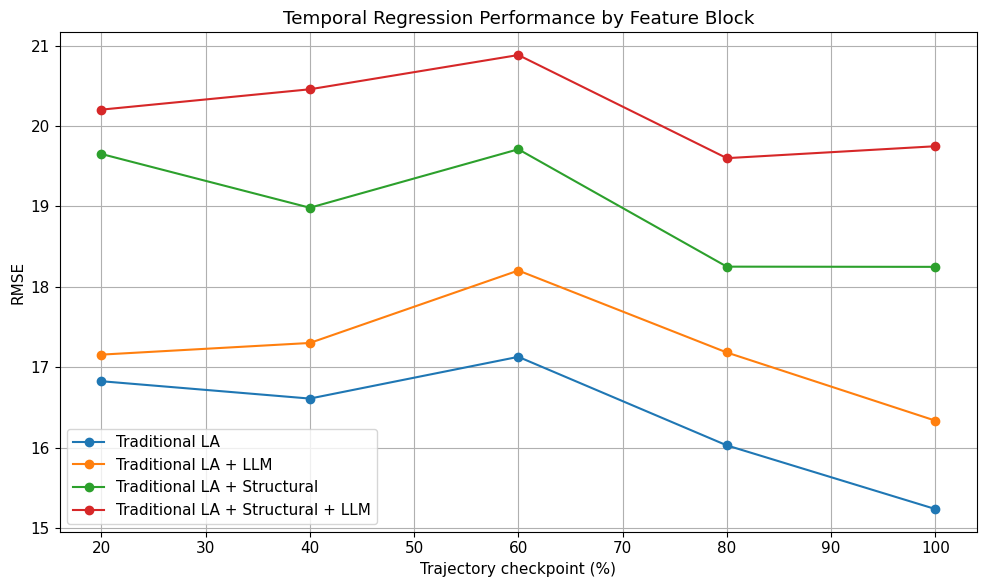

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/temporal_regression_rmse_by_feature_block.png


In [137]:
# Plot temporal RMSE by best feature block
plt.figure(figsize=(10, 6))

for feature_block in temporal_regression_block_best["feature_block"].unique():
    plot_df = (
        temporal_regression_block_best[
            temporal_regression_block_best["feature_block"] == feature_block
        ]
        .sort_values("checkpoint_value")
    )
    
    plt.plot(
        plot_df["checkpoint_value"] * 100,
        plot_df["rmse_mean"],
        marker="o",
        label=feature_block
    )

plt.xlabel("Trajectory checkpoint (%)")
plt.ylabel("RMSE")
plt.title("Temporal Regression Performance by Feature Block")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "temporal_regression_rmse_by_feature_block.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

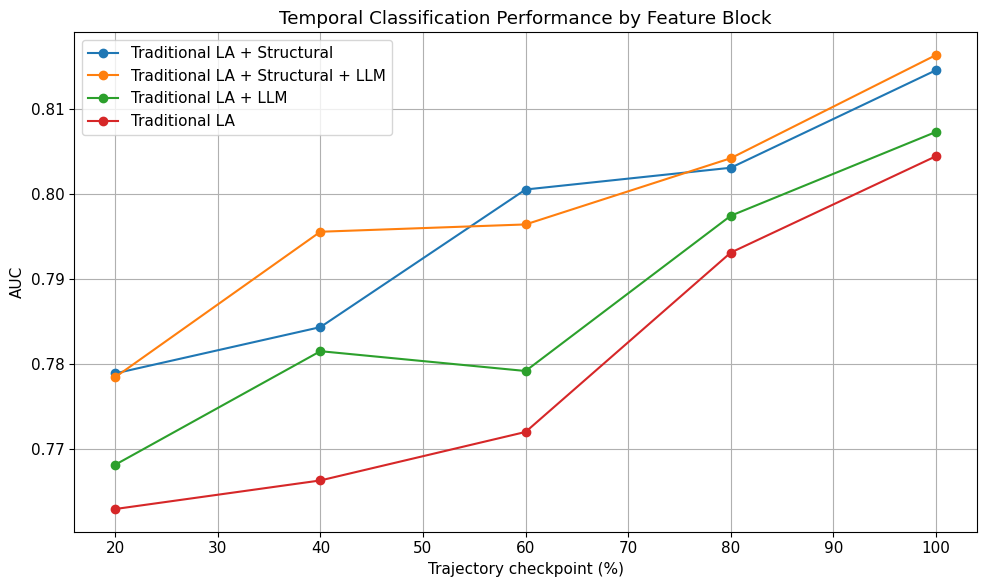

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/temporal_classification_auc_by_feature_block.png


In [138]:
# Plot temporal AUC by best feature block
plt.figure(figsize=(10, 6))

for feature_block in temporal_classification_block_best["feature_block"].unique():
    plot_df = (
        temporal_classification_block_best[
            temporal_classification_block_best["feature_block"] == feature_block
        ]
        .sort_values("checkpoint_value")
    )
    
    plt.plot(
        plot_df["checkpoint_value"] * 100,
        plot_df["auc_mean"],
        marker="o",
        label=feature_block
    )

plt.xlabel("Trajectory checkpoint (%)")
plt.ylabel("AUC")
plt.title("Temporal Classification Performance by Feature Block")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "temporal_classification_auc_by_feature_block.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

### 11.10 Best feature block at each checkpoint

This section identifies the best performing feature block at each checkpoint. 

In [139]:
# Best regression dataset overall at each checkpoint
best_temporal_regression = (
    temporal_regression_results
    .sort_values(["checkpoint_value", "rmse_mean"], ascending=[True, True])
    .groupby("checkpoint")
    .first()
    .reset_index()
    .sort_values("checkpoint_value")
)

best_temporal_regression[
    [
        "checkpoint", "dataset", "feature_block", "prompt_name",
        "model", "n_features", "rmse_mean", "r2_mean", "mae_mean"
    ]
]

,checkpoint,dataset,feature_block,prompt_name,model,n_features,rmse_mean,r2_mean,mae_mean
1,20%,traditional_LA_only,Traditional LA,no_prompt,Ridge,48,16.8250,0.2367,12.8457
2,40%,traditional_LA_only,Traditional LA,no_prompt,Ridge,48,16.6092,0.2608,12.9523
3,60%,traditional_LA_only,Traditional LA,no_prompt,Ridge,48,17.1282,0.1940,12.9615
4,80%,traditional_LA_only,Traditional LA,no_prompt,Ridge,48,16.0271,0.3079,12.5883
0,100%,traditional_LA_only,Traditional LA,no_prompt,Ridge,48,15.2356,0.3756,12.2857


In [140]:
# Best classification dataset overall at each checkpoint
best_temporal_classification = (
    temporal_classification_results
    .sort_values(["checkpoint_value", "auc_mean"], ascending=[True, False])
    .groupby("checkpoint")
    .first()
    .reset_index()
    .sort_values("checkpoint_value")
)

best_temporal_classification[
    [
        "checkpoint", "dataset", "feature_block", "prompt_name",
        "model", "n_features", "auc_mean", "accuracy_mean", "f1_mean"
    ]
]

,checkpoint,dataset,feature_block,prompt_name,model,n_features,auc_mean,accuracy_mean,f1_mean
1,20%,traditional_LA_plus_structural,Traditional LA + Structural,no_prompt,Random Forest,156,0.7789,0.7145,0.7142
2,40%,traditional_LA_structural_plus_prompt_1_struct...,Traditional LA + Structural + LLM,prompt_1_structured,Random Forest,210,0.7956,0.7392,0.7440
3,60%,traditional_LA_plus_structural,Traditional LA + Structural,no_prompt,Random Forest,156,0.8005,0.7524,0.7580
4,80%,traditional_LA_structural_plus_prompt_2_rubric,Traditional LA + Structural + LLM,prompt_2_rubric,Random Forest,210,0.8042,0.7475,0.7483
0,100%,traditional_LA_structural_plus_prompt_0_minimal,Traditional LA + Structural + LLM,prompt_0_minimal,Random Forest,210,0.8164,0.7566,0.7622


### 11.12 Prompt comparison across checkpoints

The next comparison focuses only on the LLM-based datasets.

The goal is to identify which prompt produces the most useful semantic features at each checkpoint. This is evaluated separately for:

- Traditional LA + LLM.
- Traditional LA + Structural code + LLM.

This distinction is useful because a prompt may work better alone, while another prompt may complement structural code features more effectively.

In [141]:
# Prompt comparison for regression: LA + LLM only
temporal_regression_prompt_la_llm = (
    temporal_regression_results[
        temporal_regression_results["feature_block"] == "Traditional LA + LLM"
    ]
    .sort_values(["checkpoint_value", "rmse_mean"], ascending=[True, True])
)

best_regression_prompt_la_llm = (
    temporal_regression_prompt_la_llm
    .groupby("checkpoint")
    .first()
    .reset_index()
    .sort_values("checkpoint_value")
)

best_regression_prompt_la_llm[
    [
        "checkpoint", "prompt_name", "dataset",
        "rmse_mean", "r2_mean", "mae_mean"
    ]
]

,checkpoint,prompt_name,dataset,rmse_mean,r2_mean,mae_mean
1,20%,prompt_2_rubric,traditional_LA_plus_prompt_2_rubric,17.1558,0.2053,13.1105
2,40%,prompt_1_structured,traditional_LA_plus_prompt_1_structured,17.3007,0.1920,13.5751
3,60%,prompt_1_structured,traditional_LA_plus_prompt_1_structured,18.2017,0.0753,13.7281
4,80%,prompt_2_rubric,traditional_LA_plus_prompt_2_rubric,17.1823,0.1996,13.4084
0,100%,prompt_2_rubric,traditional_LA_plus_prompt_2_rubric,16.3348,0.2795,12.9837


In [142]:
# Prompt comparison for regression: LA + Structural + LLM
temporal_regression_prompt_full = (
    temporal_regression_results[
        temporal_regression_results["feature_block"] == "Traditional LA + Structural + LLM"
    ]
    .sort_values(["checkpoint_value", "rmse_mean"], ascending=[True, True])
)

best_regression_prompt_full = (
    temporal_regression_prompt_full
    .groupby("checkpoint")
    .first()
    .reset_index()
    .sort_values("checkpoint_value")
)

best_regression_prompt_full[
    [
        "checkpoint", "prompt_name", "dataset",
        "rmse_mean", "r2_mean", "mae_mean"
    ]
]

,checkpoint,prompt_name,dataset,rmse_mean,r2_mean,mae_mean
1,20%,prompt_2_rubric,traditional_LA_structural_plus_prompt_2_rubric,20.2024,-0.1127,15.6686
2,40%,prompt_0_minimal,traditional_LA_structural_plus_prompt_0_minimal,20.4555,-0.1377,16.0623
3,60%,prompt_1_structured,traditional_LA_structural_plus_prompt_1_struct...,20.8815,-0.2114,15.8364
4,80%,prompt_1_structured,traditional_LA_structural_plus_prompt_1_struct...,19.5990,-0.0623,15.4409
0,100%,prompt_1_structured,traditional_LA_structural_plus_prompt_1_struct...,19.7472,-0.0599,15.5317


In [143]:
# Prompt comparison for classification: LA + LLM only
temporal_classification_prompt_la_llm = (
    temporal_classification_results[
        temporal_classification_results["feature_block"] == "Traditional LA + LLM"
    ]
    .sort_values(["checkpoint_value", "auc_mean"], ascending=[True, False])
)

best_classification_prompt_la_llm = (
    temporal_classification_prompt_la_llm
    .groupby("checkpoint")
    .first()
    .reset_index()
    .sort_values("checkpoint_value")
)

best_classification_prompt_la_llm[
    [
        "checkpoint", "prompt_name", "dataset",
        "auc_mean", "accuracy_mean", "f1_mean"
    ]
]

,checkpoint,prompt_name,dataset,auc_mean,accuracy_mean,f1_mean
1,20%,prompt_2_rubric,traditional_LA_plus_prompt_2_rubric,0.7681,0.7120,0.7122
2,40%,prompt_1_structured,traditional_LA_plus_prompt_1_structured,0.7815,0.7210,0.7272
3,60%,prompt_2_rubric,traditional_LA_plus_prompt_2_rubric,0.7792,0.7194,0.7285
4,80%,prompt_2_rubric,traditional_LA_plus_prompt_2_rubric,0.7975,0.7309,0.7366
0,100%,prompt_0_minimal,traditional_LA_plus_prompt_0_minimal,0.8073,0.7524,0.7584


In [144]:
# Prompt comparison for classification: LA + Structural + LLM
temporal_classification_prompt_full = (
    temporal_classification_results[
        temporal_classification_results["feature_block"] == "Traditional LA + Structural + LLM"
    ]
    .sort_values(["checkpoint_value", "auc_mean"], ascending=[True, False])
)

best_classification_prompt_full = (
    temporal_classification_prompt_full
    .groupby("checkpoint")
    .first()
    .reset_index()
    .sort_values("checkpoint_value")
)

best_classification_prompt_full[
    [
        "checkpoint", "prompt_name", "dataset",
        "auc_mean", "accuracy_mean", "f1_mean"
    ]
]

,checkpoint,prompt_name,dataset,auc_mean,accuracy_mean,f1_mean
1,20%,prompt_0_minimal,traditional_LA_structural_plus_prompt_0_minimal,0.7784,0.7227,0.7212
2,40%,prompt_1_structured,traditional_LA_structural_plus_prompt_1_struct...,0.7956,0.7392,0.7440
3,60%,prompt_0_minimal,traditional_LA_structural_plus_prompt_0_minimal,0.7964,0.7533,0.7594
4,80%,prompt_2_rubric,traditional_LA_structural_plus_prompt_2_rubric,0.8042,0.7475,0.7483
0,100%,prompt_0_minimal,traditional_LA_structural_plus_prompt_0_minimal,0.8164,0.7566,0.7622


### 11.13 Visualising prompt performance over time

The following plots compare the three prompts across checkpoints.

This helps analyse whether one prompt consistently performs better, or whether prompt usefulness changes depending on the stage of the student trajectory.

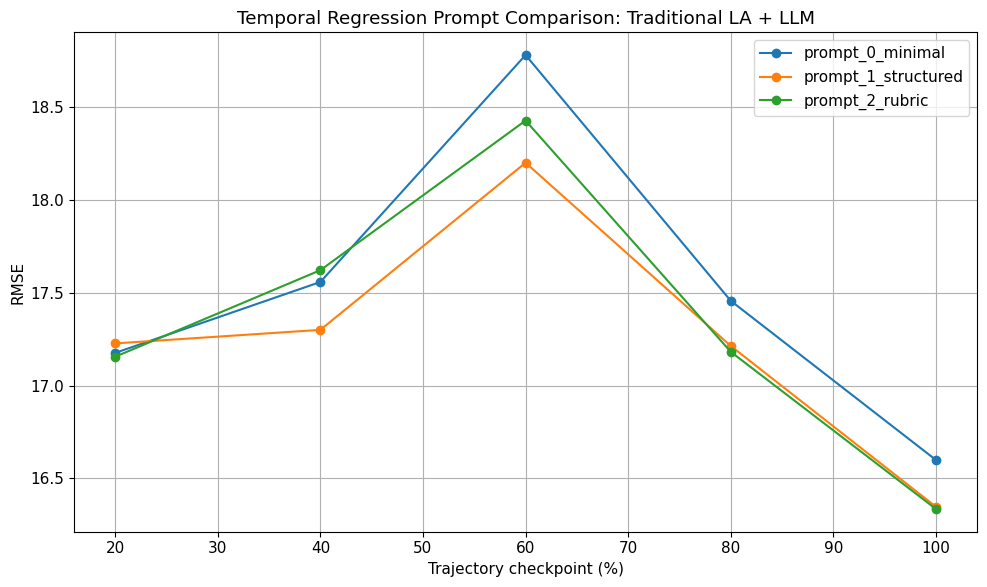

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/temporal_regression_prompt_comparison_la_llm.png


In [145]:
# Regression prompt comparison: LA + LLM
plt.figure(figsize=(10, 6))

for prompt_name in sorted(temporal_regression_prompt_la_llm["prompt_name"].unique()):
    plot_df = (
        temporal_regression_prompt_la_llm[
            temporal_regression_prompt_la_llm["prompt_name"] == prompt_name
        ]
        .sort_values("checkpoint_value")
    )
    
    plt.plot(
        plot_df["checkpoint_value"] * 100,
        plot_df["rmse_mean"],
        marker="o",
        label=prompt_name
    )

plt.xlabel("Trajectory checkpoint (%)")
plt.ylabel("RMSE")
plt.title("Temporal Regression Prompt Comparison: Traditional LA + LLM")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "temporal_regression_prompt_comparison_la_llm.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

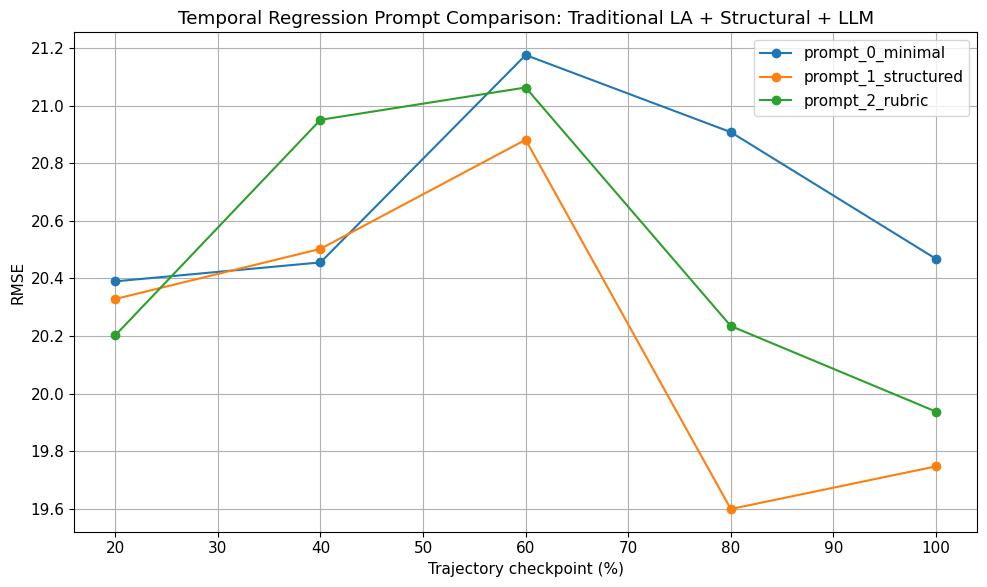

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/temporal_regression_prompt_comparison_full.png


In [146]:
# Regression prompt comparison: LA + Structural + LLM
plt.figure(figsize=(10, 6))

for prompt_name in sorted(temporal_regression_prompt_full["prompt_name"].unique()):
    plot_df = (
        temporal_regression_prompt_full[
            temporal_regression_prompt_full["prompt_name"] == prompt_name
        ]
        .sort_values("checkpoint_value")
    )
    
    plt.plot(
        plot_df["checkpoint_value"] * 100,
        plot_df["rmse_mean"],
        marker="o",
        label=prompt_name
    )

plt.xlabel("Trajectory checkpoint (%)")
plt.ylabel("RMSE")
plt.title("Temporal Regression Prompt Comparison: Traditional LA + Structural + LLM")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "temporal_regression_prompt_comparison_full.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

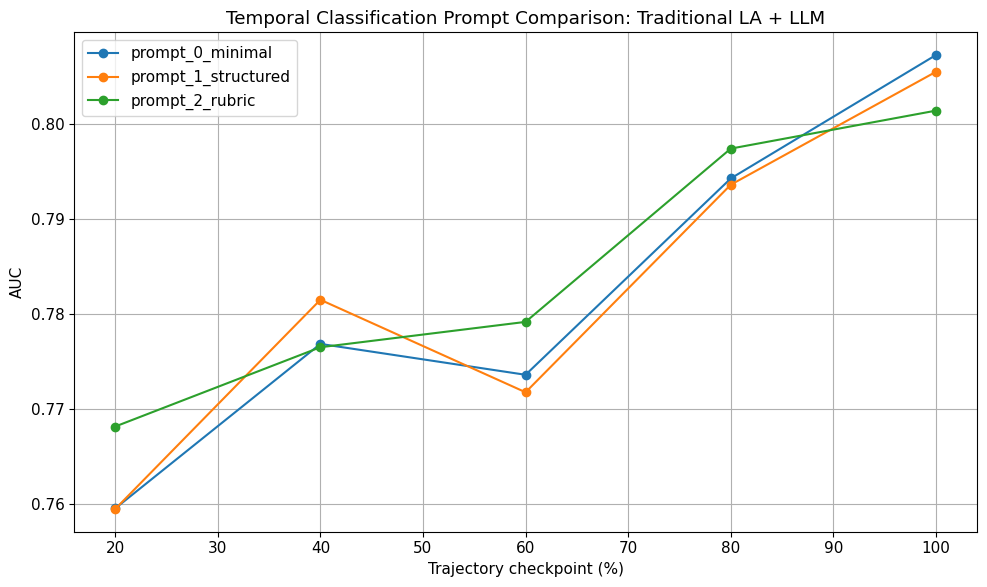

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/temporal_classification_prompt_comparison_la_llm.png


In [147]:
# Classification prompt comparison: LA + LLM
plt.figure(figsize=(10, 6))

for prompt_name in sorted(temporal_classification_prompt_la_llm["prompt_name"].unique()):
    plot_df = (
        temporal_classification_prompt_la_llm[
            temporal_classification_prompt_la_llm["prompt_name"] == prompt_name
        ]
        .sort_values("checkpoint_value")
    )
    
    plt.plot(
        plot_df["checkpoint_value"] * 100,
        plot_df["auc_mean"],
        marker="o",
        label=prompt_name
    )

plt.xlabel("Trajectory checkpoint (%)")
plt.ylabel("AUC")
plt.title("Temporal Classification Prompt Comparison: Traditional LA + LLM")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "temporal_classification_prompt_comparison_la_llm.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

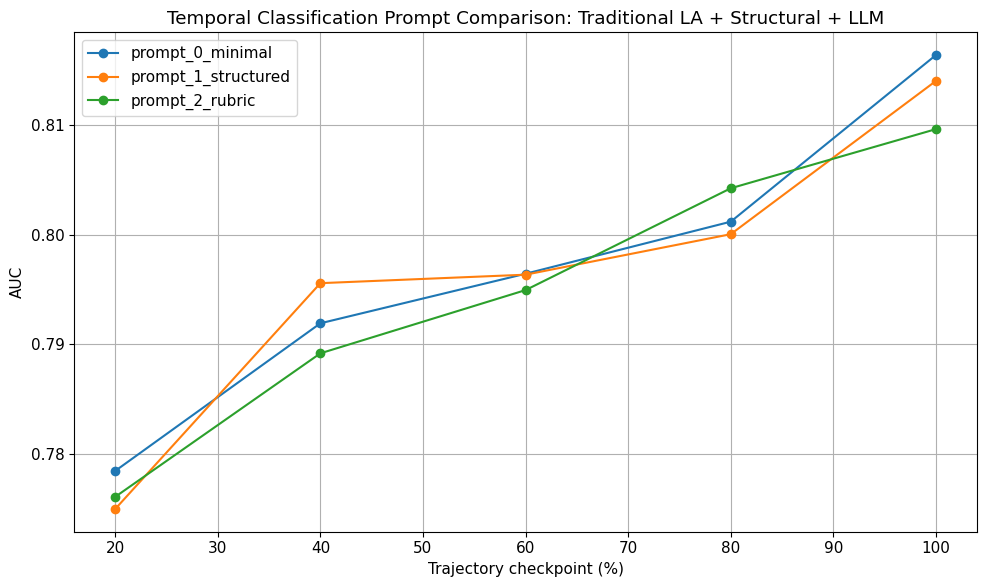

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/temporal_classification_prompt_comparison_full.png


In [148]:
# Classification prompt comparison: LA + Structural + LLM
plt.figure(figsize=(10, 6))

for prompt_name in sorted(temporal_classification_prompt_full["prompt_name"].unique()):
    plot_df = (
        temporal_classification_prompt_full[
            temporal_classification_prompt_full["prompt_name"] == prompt_name
        ]
        .sort_values("checkpoint_value")
    )
    
    plt.plot(
        plot_df["checkpoint_value"] * 100,
        plot_df["auc_mean"],
        marker="o",
        label=prompt_name
    )

plt.xlabel("Trajectory checkpoint (%)")
plt.ylabel("AUC")
plt.title("Temporal Classification Prompt Comparison: Traditional LA + Structural + LLM")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "temporal_classification_prompt_comparison_full.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

### 11.15 Improvement over the temporal baseline

This section measures whether each enriched feature block improves over the traditional Learning Analytics baseline at each checkpoint.

In [149]:
# Regression improvement over temporal LA baseline
temporal_regression_baseline = temporal_regression_results[
    temporal_regression_results["dataset"] == "traditional_LA_only"
][["checkpoint", "checkpoint_value", "rmse_mean"]].rename(
    columns={"rmse_mean": "baseline_rmse"}
)

temporal_regression_improvement = temporal_regression_results.merge(
    temporal_regression_baseline,
    on=["checkpoint", "checkpoint_value"],
    how="left"
)

temporal_regression_improvement["rmse_improvement_vs_LA"] = (
    temporal_regression_improvement["baseline_rmse"]
    - temporal_regression_improvement["rmse_mean"]
)

temporal_regression_improvement = temporal_regression_improvement.sort_values(
    ["checkpoint_value", "rmse_improvement_vs_LA"],
    ascending=[True, False]
)

temporal_regression_improvement[
    [
        "checkpoint", "dataset", "feature_block", "prompt_name",
        "rmse_mean", "baseline_rmse", "rmse_improvement_vs_LA"
    ]
].head(20)

,checkpoint,dataset,feature_block,prompt_name,rmse_mean,baseline_rmse,rmse_improvement_vs_LA
0,20%,traditional_LA_only,Traditional LA,no_prompt,16.8250,16.8250,0.0000
6,20%,traditional_LA_plus_prompt_2_rubric,Traditional LA + LLM,prompt_2_rubric,17.1558,16.8250,-0.3308
2,20%,traditional_LA_plus_prompt_0_minimal,Traditional LA + LLM,prompt_0_minimal,17.1764,16.8250,-0.3514
4,20%,traditional_LA_plus_prompt_1_structured,Traditional LA + LLM,prompt_1_structured,17.2276,16.8250,-0.4027
1,20%,traditional_LA_plus_structural,Traditional LA + Structural,no_prompt,19.6511,16.8250,-2.8262
7,20%,traditional_LA_structural_plus_prompt_2_rubric,Traditional LA + Structural + LLM,prompt_2_rubric,20.2024,16.8250,-3.3775
5,20%,traditional_LA_structural_plus_prompt_1_struct...,Traditional LA + Structural + LLM,prompt_1_structured,20.3285,16.8250,-3.5035
3,20%,traditional_LA_structural_plus_prompt_0_minimal,Traditional LA + Structural + LLM,prompt_0_minimal,20.3898,16.8250,-3.5648
8,40%,traditional_LA_only,Traditional LA,no_prompt,16.6092,16.6092,0.0000
12,40%,traditional_LA_plus_prompt_1_structured,Traditional LA + LLM,prompt_1_structured,17.3007,16.6092,-0.6915


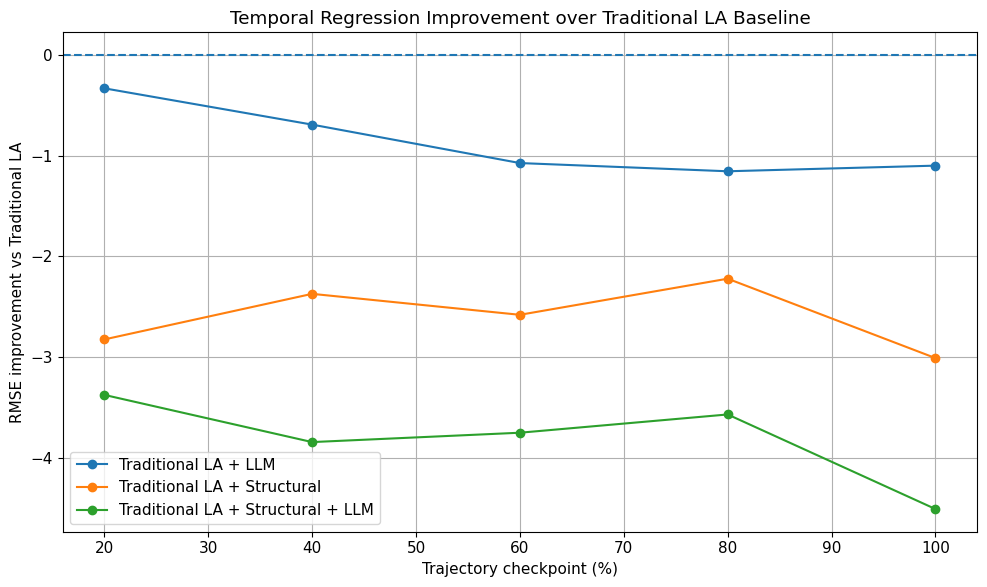

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/temporal_regression_improvement_vs_LA.png


In [152]:
# Best regression improvement by checkpoint and feature block
regression_improvement_plot = (
    temporal_regression_improvement[
        temporal_regression_improvement["feature_block"] != "Traditional LA"
    ]
    .sort_values(
        ["checkpoint_value", "feature_block", "rmse_improvement_vs_LA"],
        ascending=[True, True, False]
    )
    .groupby(["checkpoint", "checkpoint_value", "feature_block"])
    .first()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for feature_block in regression_improvement_plot["feature_block"].unique():
    plot_df = (
        regression_improvement_plot[
            regression_improvement_plot["feature_block"] == feature_block
        ]
        .sort_values("checkpoint_value")
    )
    
    plt.plot(
        plot_df["checkpoint_value"] * 100,
        plot_df["rmse_improvement_vs_LA"],
        marker="o",
        label=feature_block
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Trajectory checkpoint (%)")
plt.ylabel("RMSE improvement vs Traditional LA")
plt.title("Temporal Regression Improvement over Traditional LA Baseline")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "temporal_regression_improvement_vs_LA.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

In [150]:
# Classification improvement over temporal LA baseline
temporal_classification_baseline = temporal_classification_results[
    temporal_classification_results["dataset"] == "traditional_LA_only"
][["checkpoint", "checkpoint_value", "auc_mean"]].rename(
    columns={"auc_mean": "baseline_auc"}
)

temporal_classification_improvement = temporal_classification_results.merge(
    temporal_classification_baseline,
    on=["checkpoint", "checkpoint_value"],
    how="left"
)

temporal_classification_improvement["auc_improvement_vs_LA"] = (
    temporal_classification_improvement["auc_mean"]
    - temporal_classification_improvement["baseline_auc"]
)

temporal_classification_improvement = temporal_classification_improvement.sort_values(
    ["checkpoint_value", "auc_improvement_vs_LA"],
    ascending=[True, False]
)

temporal_classification_improvement[
    [
        "checkpoint", "dataset", "feature_block", "prompt_name",
        "auc_mean", "baseline_auc", "auc_improvement_vs_LA"
    ]
].head(20)

,checkpoint,dataset,feature_block,prompt_name,auc_mean,baseline_auc,auc_improvement_vs_LA
1,20%,traditional_LA_plus_structural,Traditional LA + Structural,no_prompt,0.7789,0.7629,0.0160
3,20%,traditional_LA_structural_plus_prompt_0_minimal,Traditional LA + Structural + LLM,prompt_0_minimal,0.7784,0.7629,0.0155
7,20%,traditional_LA_structural_plus_prompt_2_rubric,Traditional LA + Structural + LLM,prompt_2_rubric,0.7761,0.7629,0.0132
5,20%,traditional_LA_structural_plus_prompt_1_struct...,Traditional LA + Structural + LLM,prompt_1_structured,0.7750,0.7629,0.0120
6,20%,traditional_LA_plus_prompt_2_rubric,Traditional LA + LLM,prompt_2_rubric,0.7681,0.7629,0.0052
0,20%,traditional_LA_only,Traditional LA,no_prompt,0.7629,0.7629,0.0000
2,20%,traditional_LA_plus_prompt_0_minimal,Traditional LA + LLM,prompt_0_minimal,0.7595,0.7629,-0.0034
4,20%,traditional_LA_plus_prompt_1_structured,Traditional LA + LLM,prompt_1_structured,0.7594,0.7629,-0.0035
13,40%,traditional_LA_structural_plus_prompt_1_struct...,Traditional LA + Structural + LLM,prompt_1_structured,0.7956,0.7663,0.0293
11,40%,traditional_LA_structural_plus_prompt_0_minimal,Traditional LA + Structural + LLM,prompt_0_minimal,0.7919,0.7663,0.0256


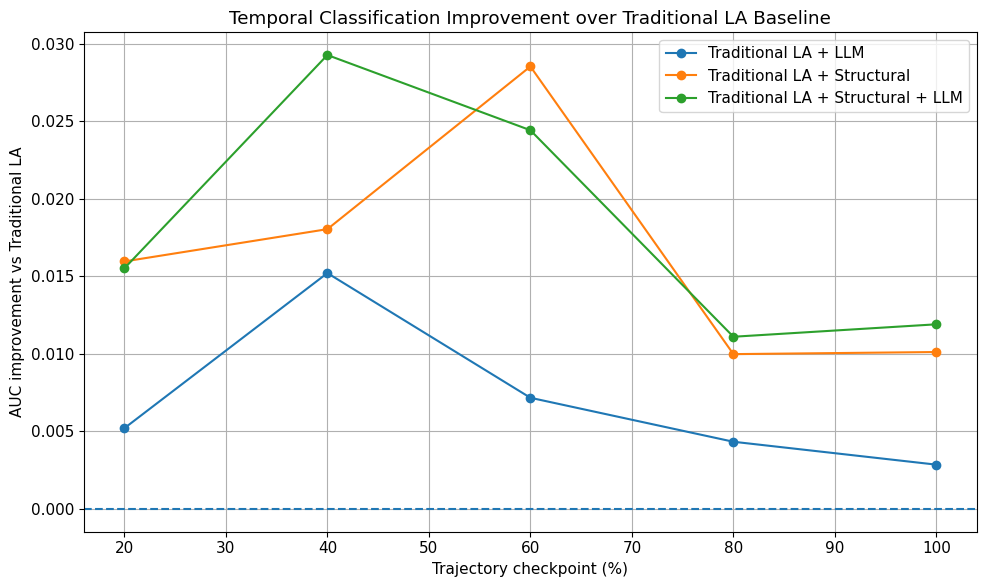

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/temporal_classification_improvement_vs_LA.png


In [153]:
# Best classification improvement by checkpoint and feature block
classification_improvement_plot = (
    temporal_classification_improvement[
        temporal_classification_improvement["feature_block"] != "Traditional LA"
    ]
    .sort_values(
        ["checkpoint_value", "feature_block", "auc_improvement_vs_LA"],
        ascending=[True, True, False]
    )
    .groupby(["checkpoint", "checkpoint_value", "feature_block"])
    .first()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for feature_block in classification_improvement_plot["feature_block"].unique():
    plot_df = (
        classification_improvement_plot[
            classification_improvement_plot["feature_block"] == feature_block
        ]
        .sort_values("checkpoint_value")
    )
    
    plt.plot(
        plot_df["checkpoint_value"] * 100,
        plot_df["auc_improvement_vs_LA"],
        marker="o",
        label=feature_block
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Trajectory checkpoint (%)")
plt.ylabel("AUC improvement vs Traditional LA")
plt.title("Temporal Classification Improvement over Traditional LA Baseline")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "temporal_classification_improvement_vs_LA.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

In [151]:
# Save temporal comparison summaries
temporal_regression_block_best.to_csv(
    TABLES_DIR / "temporal_regression_block_best.csv",
    index=False
)

temporal_classification_block_best.to_csv(
    TABLES_DIR / "temporal_classification_block_best.csv",
    index=False
)

best_temporal_regression.to_csv(
    TABLES_DIR / "best_temporal_regression_by_checkpoint.csv",
    index=False
)

best_temporal_classification.to_csv(
    TABLES_DIR / "best_temporal_classification_by_checkpoint.csv",
    index=False
)

best_regression_prompt_la_llm.to_csv(
    TABLES_DIR / "best_temporal_regression_prompt_la_llm.csv",
    index=False
)

best_regression_prompt_full.to_csv(
    TABLES_DIR / "best_temporal_regression_prompt_full.csv",
    index=False
)

best_classification_prompt_la_llm.to_csv(
    TABLES_DIR / "best_temporal_classification_prompt_la_llm.csv",
    index=False
)

best_classification_prompt_full.to_csv(
    TABLES_DIR / "best_temporal_classification_prompt_full.csv",
    index=False
)

temporal_regression_improvement.to_csv(
    TABLES_DIR / "temporal_regression_improvement_vs_LA.csv",
    index=False
)

temporal_classification_improvement.to_csv(
    TABLES_DIR / "temporal_classification_improvement_vs_LA.csv",
    index=False
)

print("Temporal comparison summaries saved.")

Temporal comparison summaries saved.


## 12. Feature importance analysis

After comparing predictive performance, this section analyses which variables contribute most to the models.

This step is important because predictive performance alone does not explain how the models use the different types of information. Feature importance helps identify whether the models rely mainly on traditional Learning Analytics variables, structural code variables, or LLM-based semantic variables.

The analysis focuses on three levels:

1. **Feature block importance**: importance of traditional LA, structural code, and LLM semantic features.
2. **Individual feature importance**: most relevant variables within the selected models.
3. **Temporal feature importance**: how the importance of feature blocks changes across trajectory checkpoints.

The analysis is performed only on the training set. The hold-out test set remains untouched and will be used later for final validation.

### 12.1 Feature block labels

Before computing feature importance, each variable is assigned to a feature block.

The main blocks are:

- Traditional Learning Analytics features.
- Structural code features.
- LLM semantic features.

Traditional Learning Analytics variables are also divided into subgroups such as activity, problem performance, compilation behaviour, temporal phase, and regularity.

The main feature importance analysis is performed using `prompt_1_structured`, because this prompt showed the most balanced performance in the fixed-point comparison and achieved the best overall classification AUC when combined with traditional LA and structural code features. It is also conceptually interpretable, since it provides clear feature definitions without imposing a very rigid rubric.

In [154]:
# Prompt selected for the main feature importance analysis
selected_importance_prompt = "prompt_1_structured"

# Main full dataset for feature importance
selected_full_dataset_name = f"traditional_LA_structural_plus_{selected_importance_prompt}"

print("Selected prompt:", selected_importance_prompt)
print("Selected full dataset:", selected_full_dataset_name)

Selected prompt: prompt_1_structured
Selected full dataset: traditional_LA_structural_plus_prompt_1_structured


In [155]:
def get_feature_block(feature):
    """Assign each feature to a main feature block."""
    
    if feature in traditional_la_feature_cols:
        return "Traditional LA"
    
    if feature in structural_code_feature_cols:
        return "Structural code"
    
    if feature in llm_feature_cols_by_prompt[selected_importance_prompt]:
        return "LLM semantic"
    
    return "Other"


def get_traditional_la_subblock(feature):
    """Assign traditional LA features to a more specific subgroup."""
    
    activity_keywords = [
        "n_attempts", "n_assignments", "n_code_states", "score_attempt",
        "n_correct_attempts", "correct_attempt_rate", "active_days",
        "first_attempt_day", "last_attempt_day", "attempts_per_active_day"
    ]
    
    problem_keywords = [
        "n_problems", "n_solved", "attempts_per_problem",
        "first_score_problem", "last_score_problem", "best_score_problem",
        "score_improvement_problem", "first_attempt_correct",
        "solve_rate"
    ]
    
    compile_keywords = [
        "compile"
    ]
    
    phase_keywords = [
        "phase_", "score_change_late_early",
        "correct_rate_change_late_early", "attempts_change_late_early"
    ]
    
    regularity_keywords = [
        "gap", "large_gaps"
    ]
    
    if any(keyword in feature for keyword in activity_keywords):
        return "Activity and attempts"
    
    if any(keyword in feature for keyword in problem_keywords):
        return "Problem performance"
    
    if any(keyword in feature for keyword in compile_keywords):
        return "Compilation behaviour"
    
    if any(keyword in feature for keyword in phase_keywords):
        return "Temporal phase"
    
    if any(keyword in feature for keyword in regularity_keywords):
        return "Regularity and inactivity"
    
    return "Traditional LA other"


def get_feature_subblock(feature):
    """Assign a detailed feature subblock."""
    
    main_block = get_feature_block(feature)
    
    if main_block == "Traditional LA":
        return get_traditional_la_subblock(feature)
    
    if main_block == "Structural code":
        return "Structural code"
    
    if main_block == "LLM semantic":
        if feature.startswith("llm_strategy_prop_"):
            return "LLM strategy proportions"
        if feature in ["llm_n_submissions", "llm_valid_json_rate"]:
            return "LLM coverage"
        return "LLM semantic scores"
    
    return "Other"

### 12.2 Feature block importance through ablation

The first importance analysis compares feature blocks by removing or adding groups of variables.

This is not exactly the same as individual feature importance. Instead, it asks a broader question: How much predictive performance is lost or gained when a feature block is included or removed?

In [156]:
# Feature groups for the selected full dataset
selected_full_train = modelling_datasets_train[selected_full_dataset_name]

selected_traditional_cols = traditional_la_feature_cols
selected_structural_cols = structural_code_feature_cols
selected_llm_cols = llm_feature_cols_by_prompt[selected_importance_prompt]

ablation_feature_sets = {
    "Traditional LA only": selected_traditional_cols,
    "Traditional LA + Structural": selected_traditional_cols + selected_structural_cols,
    "Traditional LA + LLM": selected_traditional_cols + selected_llm_cols,
    "Traditional LA + Structural + LLM": (
        selected_traditional_cols + selected_structural_cols + selected_llm_cols
    )
}

ablation_summary = pd.DataFrame({
    "feature_set": list(ablation_feature_sets.keys()),
    "n_features": [len(cols) for cols in ablation_feature_sets.values()]
})

ablation_summary

,feature_set,n_features
0,Traditional LA only,48
1,Traditional LA + Structural,156
2,Traditional LA + LLM,102
3,Traditional LA + Structural + LLM,210


In [157]:
# Regression ablation using Ridge
regression_ablation_rows = []

for feature_set_name, feature_cols in ablation_feature_sets.items():
    
    X, y = prepare_X_y(
        selected_full_train,
        feature_cols,
        REGRESSION_TARGET
    )
    
    metrics = evaluate_regression_model(
        model=temporal_regression_model,
        X=X,
        y=y,
        cv=regression_cv
    )
    
    regression_ablation_rows.append({
        "feature_set": feature_set_name,
        "n_features": len(feature_cols),
        **metrics
    })

regression_ablation_results = pd.DataFrame(regression_ablation_rows)

regression_ablation_results = regression_ablation_results.sort_values(
    "rmse_mean",
    ascending=True
).reset_index(drop=True)

regression_ablation_results

,feature_set,n_features,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
0,Traditional LA only,48,0.3611,0.1056,12.3726,1.1101,15.4071,1.5039
1,Traditional LA + LLM,102,0.2598,0.1342,13.2651,1.1700,16.5534,1.5343
2,Traditional LA + Structural,156,0.0925,0.1774,14.4960,1.2985,18.3005,1.6663
3,Traditional LA + Structural + LLM,210,-0.0816,0.2325,15.6231,1.3782,19.9146,1.6814


In [158]:
# Classification ablation using Random Forest
classification_ablation_rows = []

for feature_set_name, feature_cols in ablation_feature_sets.items():
    
    X, y = prepare_X_y(
        selected_full_train,
        feature_cols,
        CLASSIFICATION_TARGET
    )
    
    y = y.astype(int)
    
    metrics = evaluate_classification_model(
        model=temporal_classification_model,
        X=X,
        y=y,
        cv=classification_cv
    )
    
    classification_ablation_rows.append({
        "feature_set": feature_set_name,
        "n_features": len(feature_cols),
        **metrics
    })

classification_ablation_results = pd.DataFrame(classification_ablation_rows)

classification_ablation_results = classification_ablation_results.sort_values(
    "auc_mean",
    ascending=False
).reset_index(drop=True)

classification_ablation_results

,feature_set,n_features,auc_mean,auc_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Traditional LA + Structural + LLM,210,0.8149,0.0500,0.7516,0.0408,0.7789,0.0427,0.7379,0.0853,0.7544,0.0471
1,Traditional LA + Structural,156,0.8128,0.0529,0.7624,0.0541,0.7865,0.0480,0.7522,0.0971,0.7654,0.0601
2,Traditional LA + LLM,102,0.7988,0.0459,0.7458,0.0480,0.7546,0.0439,0.7647,0.0871,0.7569,0.0518
3,Traditional LA only,48,0.7842,0.0494,0.7408,0.0469,0.7564,0.0483,0.7489,0.0883,0.7493,0.0524


In [159]:
# Save ablation results
regression_ablation_results.to_csv(
    TABLES_DIR / "feature_block_ablation_regression.csv",
    index=False
)

classification_ablation_results.to_csv(
    TABLES_DIR / "feature_block_ablation_classification.csv",
    index=False
)

print("Feature block ablation results saved.")

Feature block ablation results saved.


### 12.3 Feature importance for classification

The classification task is especially relevant because the previous results showed that LLM-based features provide additional value for predicting pass/fail outcomes.

For this reason, a Random Forest classifier is trained on the full feature set using the selected prompt. The model-based feature importances are then extracted and grouped by feature block and subblocks.

This analysis helps identify whether LLM-based semantic variables appear among the relevant predictors.

In [160]:
# Prepare full classification dataset
X_class_full, y_class_full = prepare_X_y(
    selected_full_train,
    ablation_feature_sets["Traditional LA + Structural + LLM"],
    CLASSIFICATION_TARGET
)

y_class_full = y_class_full.astype(int)

# Fit Random Forest classifier on the training set
rf_class_importance_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_class_importance_model.fit(X_class_full, y_class_full)

classification_feature_importance = pd.DataFrame({
    "feature": X_class_full.columns,
    "importance": rf_class_importance_model.feature_importances_
})

classification_feature_importance["feature_block"] = classification_feature_importance["feature"].apply(
    get_feature_block
)

classification_feature_importance["feature_subblock"] = classification_feature_importance["feature"].apply(
    get_feature_subblock
)

classification_feature_importance = classification_feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

classification_feature_importance.head(25)

,feature,importance,feature_block,feature_subblock
0,code_has_loop_mean,0.0321,Structural code,Structural code
1,code_n_assignments_mean,0.0318,Structural code,Structural code
2,code_n_loops_mean,0.0288,Structural code,Structural code
3,correct_rate_change_late_early,0.0279,Traditional LA,Temporal phase
4,code_n_semicolons_mean,0.0243,Structural code,Structural code
5,n_compile_success_total,0.0232,Traditional LA,Compilation behaviour
6,compile_error_rate,0.0223,Traditional LA,Compilation behaviour
7,phase_correct_rate_late,0.0205,Traditional LA,Temporal phase
8,compile_success_rate,0.0202,Traditional LA,Compilation behaviour
9,code_n_for_mean,0.0170,Structural code,Structural code


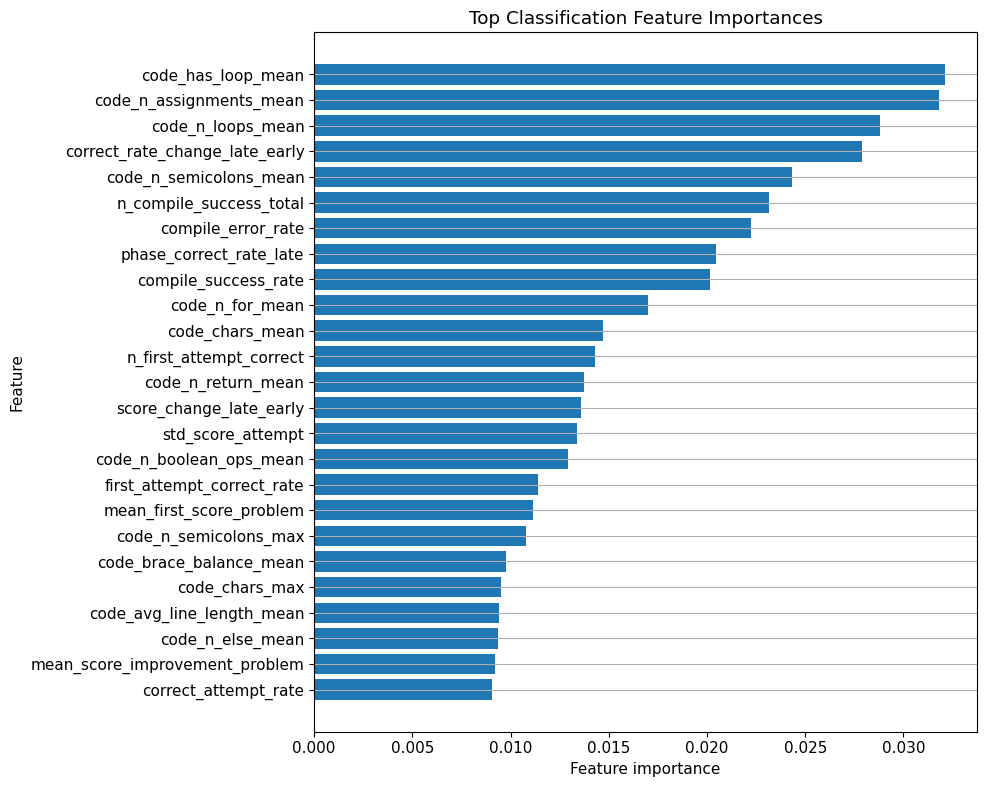

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/top_classification_feature_importances.png


In [161]:
# Plot top classification features
top_n = 25

plot_df = classification_feature_importance.head(top_n).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["feature"],
    plot_df["importance"]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top Classification Feature Importances")
plt.grid(axis="x")
plt.tight_layout()

figure_path = FIGURES_DIR / "top_classification_feature_importances.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

Individual feature importances are aggregated by feature block and subblock.

This gives a clearer view of the relative contribution of traditional LA, structural code and LLM semantic variables in the classification model.

In [162]:
# Aggregate classification feature importance by main block
classification_importance_by_block = (
    classification_feature_importance
    .groupby("feature_block")
    .agg(
        total_importance=("importance", "sum"),
        mean_importance=("importance", "mean"),
        n_features=("feature", "count")
    )
    .reset_index()
    .sort_values("total_importance", ascending=False)
)

classification_importance_by_block

,feature_block,total_importance,mean_importance,n_features
1,Structural code,0.5270,0.0049,108
2,Traditional LA,0.3733,0.0078,48
0,LLM semantic,0.0998,0.0018,54


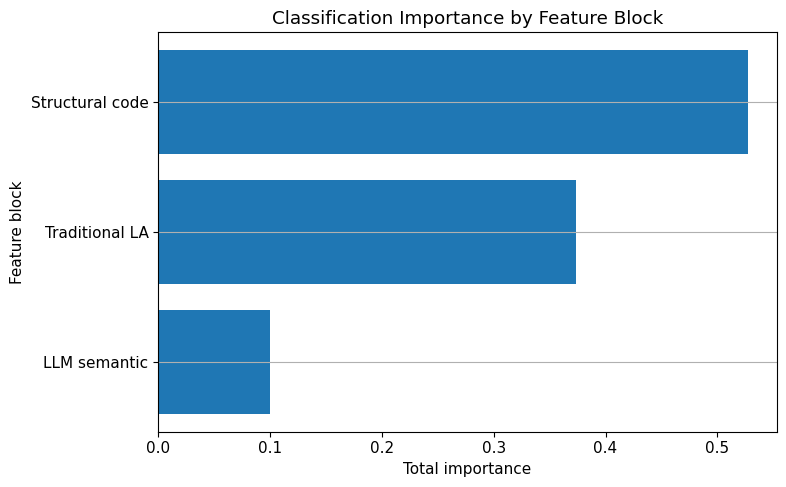

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/classification_importance_by_feature_block.png


In [166]:
# Plot importance by main block
plot_df = classification_importance_by_block.sort_values(
    "total_importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["feature_block"],
    plot_df["total_importance"]
)

plt.xlabel("Total importance")
plt.ylabel("Feature block")
plt.title("Classification Importance by Feature Block")
plt.grid(axis="x")
plt.tight_layout()

figure_path = FIGURES_DIR / "classification_importance_by_feature_block.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

In [163]:
# Aggregate classification feature importance by detailed subblock
classification_importance_by_subblock = (
    classification_feature_importance
    .groupby("feature_subblock")
    .agg(
        total_importance=("importance", "sum"),
        mean_importance=("importance", "mean"),
        n_features=("feature", "count")
    )
    .reset_index()
    .sort_values("total_importance", ascending=False)
)

classification_importance_by_subblock

,feature_subblock,total_importance,mean_importance,n_features
7,Structural code,0.5270,0.0049,108
0,Activity and attempts,0.1059,0.0056,19
8,Temporal phase,0.0976,0.0108,9
3,LLM semantic scores,0.0949,0.0021,45
1,Compilation behaviour,0.0778,0.0156,5
5,Problem performance,0.0624,0.0069,9
6,Regularity and inactivity,0.0244,0.0049,5
9,Traditional LA other,0.0051,0.0051,1
4,LLM strategy proportions,0.0048,0.0007,7
2,LLM coverage,0.0000,0.0000,2


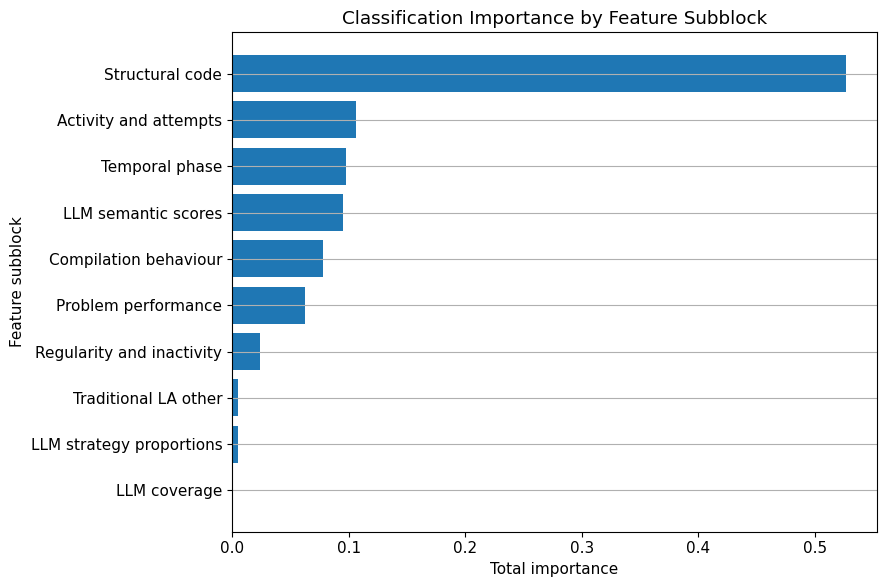

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/classification_importance_by_feature_subblock.png


In [165]:
# Plot importance by subblock
plot_df = classification_importance_by_subblock.sort_values(
    "total_importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["feature_subblock"],
    plot_df["total_importance"]
)

plt.xlabel("Total importance")
plt.ylabel("Feature subblock")
plt.title("Classification Importance by Feature Subblock")
plt.grid(axis="x")
plt.tight_layout()

figure_path = FIGURES_DIR / "classification_importance_by_feature_subblock.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

### 12.4 Feature importance for regression

The previous regression results showed that the Traditional Learning Analytics baseline performs best for predicting the final numerical grade.

For this reason, the regression feature importance analysis focuses on the Traditional LA feature block using Ridge Regression.

Since Ridge Regression is trained with standardised features, the absolute value of each coefficient is used as an indicator of relative importance. A larger absolute coefficient means that the variable has a stronger influence on the prediction of the final grade.

In [169]:
# Prepare traditional LA regression dataset
regression_importance_train = modelling_datasets_train["traditional_LA_only"]

X_reg_la, y_reg_la = prepare_X_y(
    regression_importance_train,
    traditional_la_feature_cols,
    REGRESSION_TARGET
)

# Fit Ridge model with standardised features
ridge_importance_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

ridge_importance_model.fit(X_reg_la, y_reg_la)

ridge_coefficients = ridge_importance_model.named_steps["model"].coef_

regression_feature_importance = pd.DataFrame({
    "feature": X_reg_la.columns,
    "coefficient": ridge_coefficients,
    "absolute_importance": np.abs(ridge_coefficients)
})

regression_feature_importance["feature_block"] = "Traditional LA"

regression_feature_importance["feature_subblock"] = regression_feature_importance["feature"].apply(
    get_traditional_la_subblock
)

regression_feature_importance = regression_feature_importance.sort_values(
    "absolute_importance",
    ascending=False
).reset_index(drop=True)

regression_feature_importance.head(25)

,feature,coefficient,absolute_importance,feature_block,feature_subblock
0,solve_rate,11.6184,11.6184,Traditional LA,Problem performance
1,n_solved_problems,-10.1736,10.1736,Traditional LA,Problem performance
2,compile_error_rate,-8.7806,8.7806,Traditional LA,Compilation behaviour
3,compile_success_rate,8.7806,8.7806,Traditional LA,Compilation behaviour
4,mean_attempts_per_problem,-7.8409,7.8409,Traditional LA,Activity and attempts
5,active_days_attempts,7.6432,7.6432,Traditional LA,Activity and attempts
6,first_attempt_correct_rate,-7.6268,7.6268,Traditional LA,Problem performance
7,n_compile_errors_total,6.8772,6.8772,Traditional LA,Compilation behaviour
8,n_problems_attempted,6.8039,6.8039,Traditional LA,Problem performance
9,last_attempt_day_from_start,-5.9495,5.9495,Traditional LA,Activity and attempts


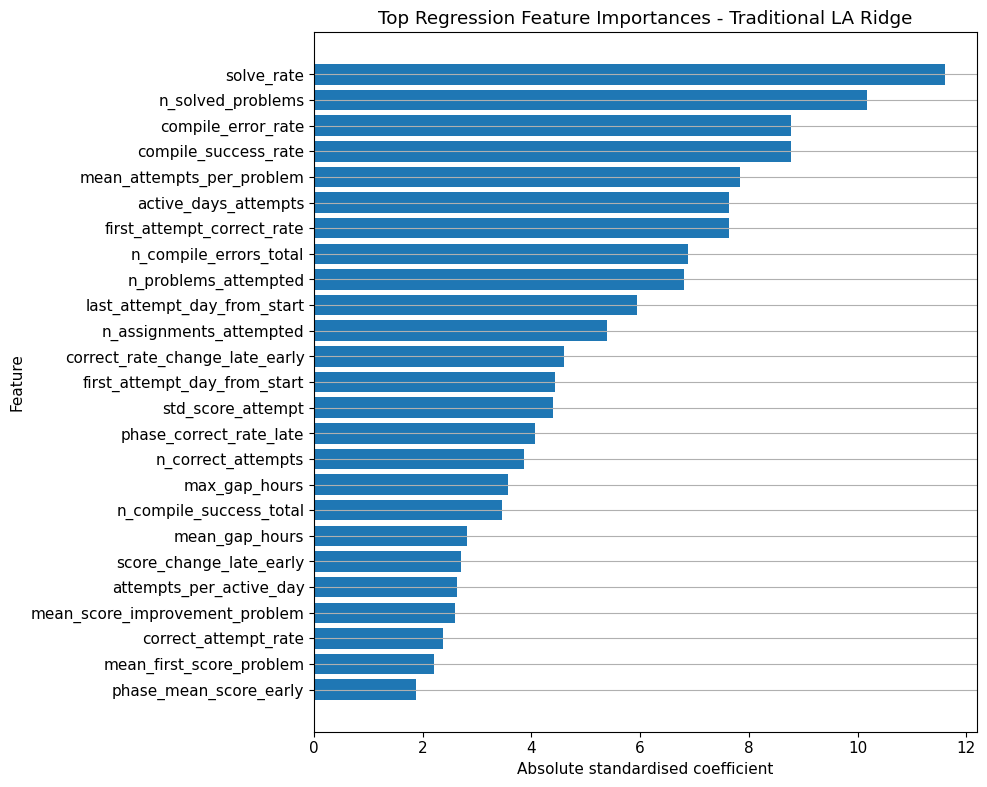

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/top_regression_feature_importances_ridge.png


In [170]:
# Plot top regression features
top_n = 25

plot_df = regression_feature_importance.head(top_n).sort_values(
    "absolute_importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["feature"],
    plot_df["absolute_importance"]
)

plt.xlabel("Absolute standardised coefficient")
plt.ylabel("Feature")
plt.title("Top Regression Feature Importances - Traditional LA Ridge")
plt.grid(axis="x")
plt.tight_layout()

figure_path = FIGURES_DIR / "top_regression_feature_importances_ridge.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

The individual regression importances are also aggregated by Traditional LA subblock.

This helps identify which types of traditional behavioural variables are most relevant for predicting the final numerical grade.

The subblocks include activity and attempts, problem performance, compilation behaviour, temporal phase features, and regularity indicators.

In [171]:
# Aggregate regression feature importance by Traditional LA subblock
regression_importance_by_subblock = (
    regression_feature_importance
    .groupby("feature_subblock")
    .agg(
        total_importance=("absolute_importance", "sum"),
        mean_importance=("absolute_importance", "mean"),
        n_features=("feature", "count")
    )
    .reset_index()
    .sort_values("total_importance", ascending=False)
)

regression_importance_by_subblock

,feature_subblock,total_importance,mean_importance,n_features
0,Activity and attempts,53.6873,2.8256,19
2,Problem performance,44.0991,4.8999,9
1,Compilation behaviour,29.1609,5.8322,5
4,Temporal phase,15.9626,1.7736,9
3,Regularity and inactivity,8.8047,1.7609,5
5,Traditional LA other,1.5970,1.5970,1


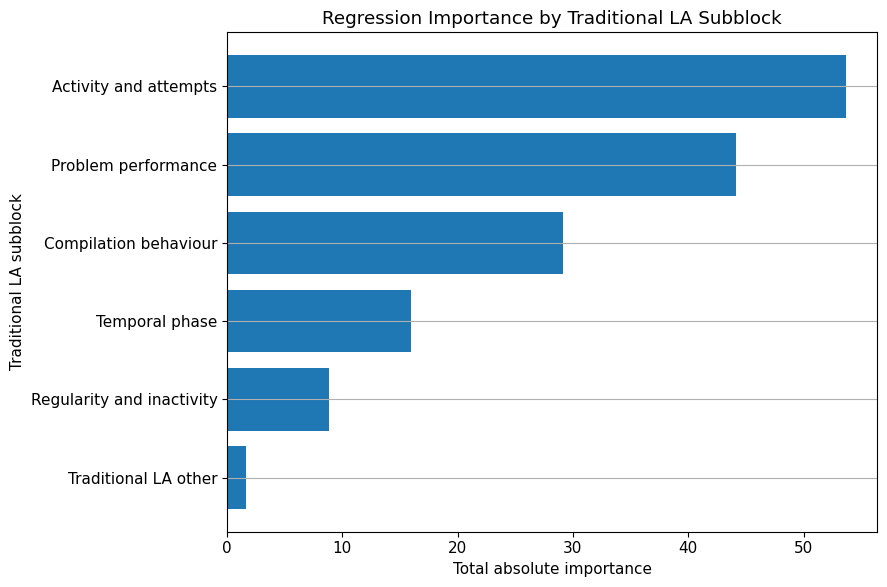

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/regression_importance_by_traditional_la_subblock.png


In [172]:
# Plot regression importance by subblock
plot_df = regression_importance_by_subblock.sort_values(
    "total_importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["feature_subblock"],
    plot_df["total_importance"]
)

plt.xlabel("Total absolute importance")
plt.ylabel("Traditional LA subblock")
plt.title("Regression Importance by Traditional LA Subblock")
plt.grid(axis="x")
plt.tight_layout()

figure_path = FIGURES_DIR / "regression_importance_by_traditional_la_subblock.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

### 12.5 Temporal feature importance for classification

This section analyses how feature block importance changes across the trajectory.

The focus is classification, because previous results showed that structural and LLM-based features add value for the pass/fail task.

At each checkpoint, a Random Forest classifier is trained using the full feature block with `prompt_1_structured`. Feature importances are then extracted and aggregated by feature block.

This allows us to see whether the model relies more on traditional Learning Analytics, structural code features, or LLM semantic features at different moments of the course.

In [173]:
temporal_importance_rows = []
temporal_top_features_rows = []

for checkpoint_label, checkpoint_value in TEMPORAL_CHECKPOINTS.items():
    
    dataset_name = f"traditional_LA_structural_plus_{selected_importance_prompt}"
    
    df_checkpoint = temporal_modelling_datasets[checkpoint_label][dataset_name]
    
    df_train_checkpoint = (
        df_checkpoint[df_checkpoint[ID_COL].isin(train_ids)]
        .reset_index(drop=True)
    )
    
    feature_cols = [
        col for col in df_train_checkpoint.columns
        if col not in TARGET_COLS
    ]
    
    X_checkpoint, y_checkpoint = prepare_X_y(
        df_train_checkpoint,
        feature_cols,
        CLASSIFICATION_TARGET
    )
    
    y_checkpoint = y_checkpoint.astype(int)
    
    model_checkpoint = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    model_checkpoint.fit(X_checkpoint, y_checkpoint)
    
    checkpoint_importance = pd.DataFrame({
        "checkpoint": checkpoint_label,
        "checkpoint_value": checkpoint_value,
        "feature": X_checkpoint.columns,
        "importance": model_checkpoint.feature_importances_
    })
    
    checkpoint_importance["feature_block"] = checkpoint_importance["feature"].apply(
        get_feature_block
    )
    
    checkpoint_importance["feature_subblock"] = checkpoint_importance["feature"].apply(
        get_feature_subblock
    )
    
    # Aggregate importance by feature block
    block_importance = (
        checkpoint_importance
        .groupby(["checkpoint", "checkpoint_value", "feature_block"])
        .agg(
            total_importance=("importance", "sum"),
            mean_importance=("importance", "mean"),
            n_features=("feature", "count")
        )
        .reset_index()
    )
    
    temporal_importance_rows.append(block_importance)
    
    # Keep top features for this checkpoint
    top_features_checkpoint = (
        checkpoint_importance
        .sort_values("importance", ascending=False)
        .head(15)
        .copy()
    )
    
    temporal_top_features_rows.append(top_features_checkpoint)

temporal_classification_importance_by_block = pd.concat(
    temporal_importance_rows,
    ignore_index=True
)

temporal_top_classification_features = pd.concat(
    temporal_top_features_rows,
    ignore_index=True
)

display(temporal_classification_importance_by_block)
display(temporal_top_classification_features.head(20))

,checkpoint,checkpoint_value,feature_block,total_importance,mean_importance,n_features
0,20%,0.2000,LLM semantic,0.0373,0.0007,54
1,20%,0.2000,Structural code,0.4447,0.0041,108
2,20%,0.2000,Traditional LA,0.5180,0.0108,48
3,40%,0.4000,LLM semantic,0.0909,0.0017,54
4,40%,0.4000,Structural code,0.5519,0.0051,108
5,40%,0.4000,Traditional LA,0.3572,0.0074,48
6,60%,0.6000,LLM semantic,0.0902,0.0017,54
7,60%,0.6000,Structural code,0.5482,0.0051,108
8,60%,0.6000,Traditional LA,0.3616,0.0075,48
9,80%,0.8000,LLM semantic,0.0990,0.0018,54


,checkpoint,checkpoint_value,feature,importance,feature_block,feature_subblock
0,20%,0.2000,n_problems_attempted,0.0422,Traditional LA,Problem performance
1,20%,0.2000,n_solved_problems,0.0345,Traditional LA,Problem performance
2,20%,0.2000,n_correct_attempts,0.0309,Traditional LA,Activity and attempts
3,20%,0.2000,n_compile_success_total,0.0257,Traditional LA,Compilation behaviour
4,20%,0.2000,last_attempt_day_from_start,0.0170,Traditional LA,Activity and attempts
5,20%,0.2000,max_gap_hours,0.0169,Traditional LA,Regularity and inactivity
6,20%,0.2000,mean_gap_hours,0.0149,Traditional LA,Regularity and inactivity
7,20%,0.2000,code_n_semicolons_mean,0.0136,Structural code,Structural code
8,20%,0.2000,n_assignments_attempted,0.0135,Traditional LA,Activity and attempts
9,20%,0.2000,code_n_boolean_ops_std,0.0134,Structural code,Structural code


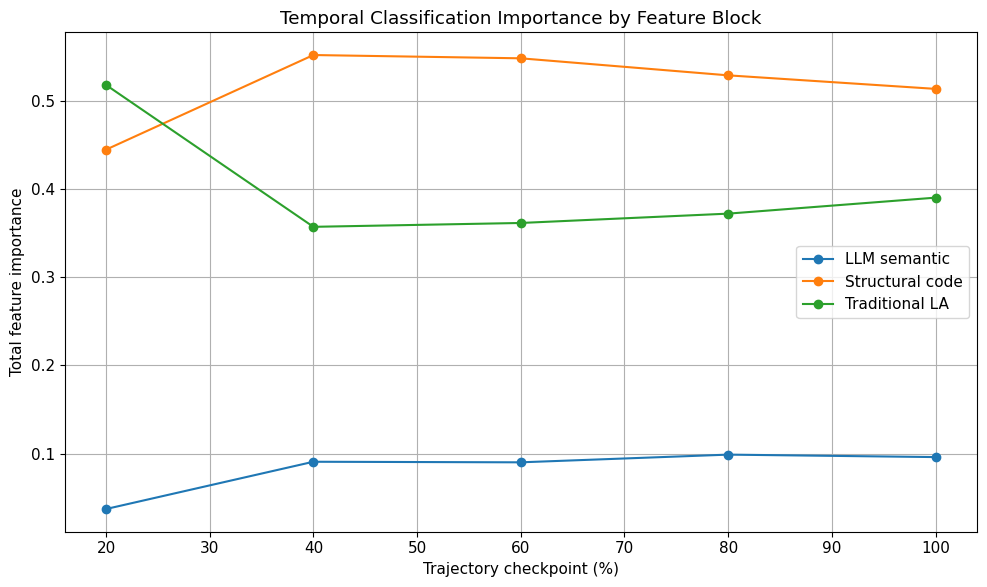

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/temporal_classification_importance_by_block.png


In [174]:
# Plot temporal importance by feature block
plt.figure(figsize=(10, 6))

for feature_block in temporal_classification_importance_by_block["feature_block"].unique():
    plot_df = (
        temporal_classification_importance_by_block[
            temporal_classification_importance_by_block["feature_block"] == feature_block
        ]
        .sort_values("checkpoint_value")
    )
    
    plt.plot(
        plot_df["checkpoint_value"] * 100,
        plot_df["total_importance"],
        marker="o",
        label=feature_block
    )

plt.xlabel("Trajectory checkpoint (%)")
plt.ylabel("Total feature importance")
plt.title("Temporal Classification Importance by Feature Block")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "temporal_classification_importance_by_block.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

### 12.6 Temporal feature importance for regression

The temporal regression results showed that the Traditional Learning Analytics block performs best at every checkpoint.

For this reason, the temporal regression importance analysis focuses only on the Traditional LA feature block. At each checkpoint, a Ridge Regression model is trained using the Traditional LA features available up to that point.

Since the model uses standardised features, the absolute value of the coefficients is used as an importance measure. The importances are then aggregated by Traditional LA subblock to analyse which types of behavioural variables are most relevant over time.

In [178]:
# Temporal regression importance by Traditional LA subblock
temporal_regression_importance_rows = []

for checkpoint_label, checkpoint_value in TEMPORAL_CHECKPOINTS.items():
    
    df_checkpoint = temporal_modelling_datasets[checkpoint_label]["traditional_LA_only"]
    
    df_train_checkpoint = (
        df_checkpoint[df_checkpoint[ID_COL].isin(train_ids)]
        .reset_index(drop=True)
    )
    
    feature_cols = [
        col for col in df_train_checkpoint.columns
        if col not in TARGET_COLS
    ]
    
    X_checkpoint, y_checkpoint = prepare_X_y(
        df_train_checkpoint,
        feature_cols,
        REGRESSION_TARGET
    )
    
    ridge_model_checkpoint = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ])
    
    ridge_model_checkpoint.fit(X_checkpoint, y_checkpoint)
    
    coefficients = ridge_model_checkpoint.named_steps["model"].coef_
    
    checkpoint_importance = pd.DataFrame({
        "checkpoint": checkpoint_label,
        "checkpoint_value": checkpoint_value,
        "feature": X_checkpoint.columns,
        "coefficient": coefficients,
        "absolute_importance": np.abs(coefficients)
    })
    
    checkpoint_importance["feature_subblock"] = checkpoint_importance["feature"].apply(
        get_traditional_la_subblock
    )
    
    subblock_importance = (
        checkpoint_importance
        .groupby(["checkpoint", "checkpoint_value", "feature_subblock"])
        .agg(
            total_importance=("absolute_importance", "sum"),
            mean_importance=("absolute_importance", "mean"),
            n_features=("feature", "count")
        )
        .reset_index()
    )
    
    temporal_regression_importance_rows.append(subblock_importance)

temporal_regression_importance_by_subblock = pd.concat(
    temporal_regression_importance_rows,
    ignore_index=True
)

temporal_regression_importance_by_subblock

,checkpoint,checkpoint_value,feature_subblock,total_importance,mean_importance,n_features
0,20%,0.2000,Activity and attempts,51.2561,2.6977,19
1,20%,0.2000,Compilation behaviour,13.3934,2.6787,5
2,20%,0.2000,Problem performance,32.8338,3.6482,9
3,20%,0.2000,Regularity and inactivity,9.8461,1.9692,5
4,20%,0.2000,Temporal phase,7.1890,0.7988,9
5,20%,0.2000,Traditional LA other,1.6117,1.6117,1
6,40%,0.4000,Activity and attempts,50.6786,2.6673,19
7,40%,0.4000,Compilation behaviour,16.8756,3.3751,5
8,40%,0.4000,Problem performance,42.0651,4.6739,9
9,40%,0.4000,Regularity and inactivity,6.1561,1.2312,5


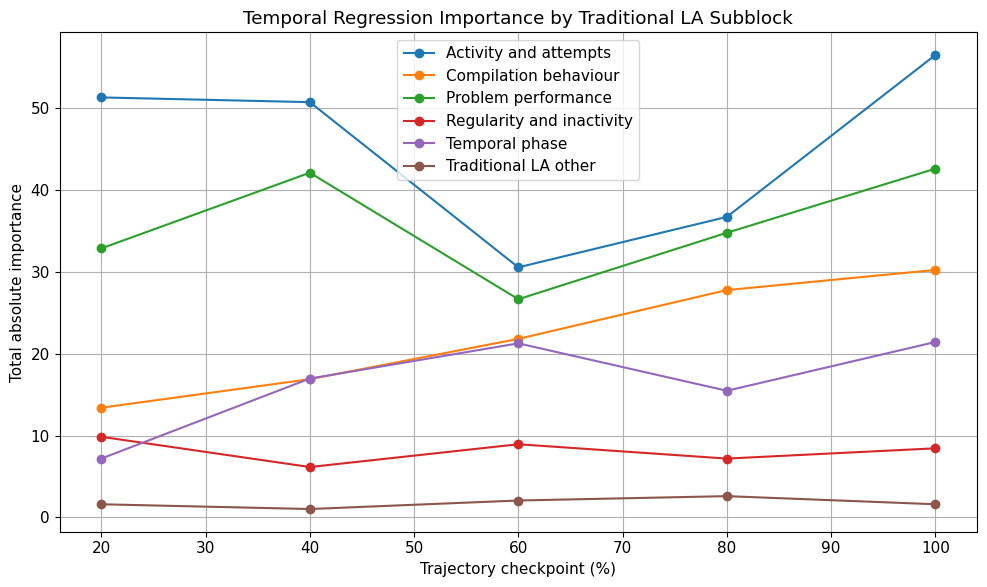

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/temporal_regression_importance_by_la_subblock.png


In [179]:
# Plot temporal regression importance by Traditional LA subblock
plt.figure(figsize=(10, 6))

for subblock in temporal_regression_importance_by_subblock["feature_subblock"].unique():
    plot_df = (
        temporal_regression_importance_by_subblock[
            temporal_regression_importance_by_subblock["feature_subblock"] == subblock
        ]
        .sort_values("checkpoint_value")
    )
    
    plt.plot(
        plot_df["checkpoint_value"] * 100,
        plot_df["total_importance"],
        marker="o",
        label=subblock
    )

plt.xlabel("Trajectory checkpoint (%)")
plt.ylabel("Total absolute importance")
plt.title("Temporal Regression Importance by Traditional LA Subblock")
plt.grid(True)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "temporal_regression_importance_by_la_subblock.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

In [180]:
# Save feature importance outputs
classification_feature_importance.to_csv(
    TABLES_DIR / "classification_feature_importance_fixed_point.csv",
    index=False
)

classification_importance_by_block.to_csv(
    TABLES_DIR / "classification_importance_by_block.csv",
    index=False
)

classification_importance_by_subblock.to_csv(
    TABLES_DIR / "classification_importance_by_subblock.csv",
    index=False
)

regression_feature_importance.to_csv(
    TABLES_DIR / "regression_feature_importance_ridge.csv",
    index=False
)

regression_importance_by_subblock.to_csv(
    TABLES_DIR / "regression_importance_by_traditional_la_subblock.csv",
    index=False
)

temporal_classification_importance_by_block.to_csv(
    TABLES_DIR / "temporal_classification_importance_by_block.csv",
    index=False
)

temporal_top_classification_features.to_csv(
    TABLES_DIR / "temporal_top_classification_features.csv",
    index=False
)

temporal_regression_importance_by_subblock.to_csv(
    TABLES_DIR / "temporal_regression_importance_by_la_subblock.csv",
    index=False
)

print("Feature importance outputs saved.")

Feature importance outputs saved.


## 13. Final hold-out validation

The previous modelling sections used only the training set. Models, feature blocks and prompts were compared using cross-validation on the training data.

In this section, the hold-out test set is used for the first time.

The goal is to evaluate whether the selected models generalise to unseen students. This is important because cross-validation results can guide model selection, but the final performance should be reported on data that was not used during model comparison.

The validation follows this logic:

1. Select the best candidate models using training cross-validation results.
2. Train each selected model on the full training set.
3. Evaluate the trained model on the untouched hold-out test set.
4. Compare the final performance of the main feature blocks.

The test set is not used to choose the model. It is only used for final evaluation.

### 13.1 Selection of final candidate models

The final validation compares a small number of candidate configurations.

The selected candidates represent the main feature blocks:

- Traditional LA only.
- Traditional LA + Structural code.
- Traditional LA + LLM.
- Traditional LA + Structural code + LLM.

For each task, the model used for each dataset is selected from the previous cross-validation results on the training set.

In [181]:
def get_best_row_for_dataset(results_df, dataset_name, task):
    """Get the best model row for one dataset."""
    
    subset = results_df[results_df["dataset"] == dataset_name].copy()
    
    if task == "regression":
        subset = subset.sort_values("rmse_mean", ascending=True)
    elif task == "classification":
        subset = subset.sort_values("auc_mean", ascending=False)
    else:
        raise ValueError("task must be 'regression' or 'classification'")
    
    return subset.iloc[0]


def get_best_row_by_dataset_pattern(results_df, pattern, task):
    """Get the best row among datasets matching a text pattern."""
    
    subset = results_df[results_df["dataset"].str.contains(pattern, regex=False)].copy()
    
    if task == "regression":
        subset = subset.sort_values("rmse_mean", ascending=True)
    elif task == "classification":
        subset = subset.sort_values("auc_mean", ascending=False)
    else:
        raise ValueError("task must be 'regression' or 'classification'")
    
    return subset.iloc[0]

In [182]:
# Regression candidates selected from training CV
final_regression_candidate_rows = [
    get_best_row_for_dataset(
        regression_results,
        "traditional_LA_only",
        task="regression"
    ),
    get_best_row_for_dataset(
        regression_results,
        "traditional_LA_plus_structural",
        task="regression"
    ),
    get_best_row_by_dataset_pattern(
        regression_results,
        "traditional_LA_plus_prompt",
        task="regression"
    ),
    get_best_row_by_dataset_pattern(
        regression_results,
        "traditional_LA_structural_plus_prompt",
        task="regression"
    )
]

final_regression_candidates = pd.DataFrame(final_regression_candidate_rows)

final_regression_candidates[
    ["dataset", "model", "n_features", "rmse_mean", "r2_mean", "mae_mean"]
]

,dataset,model,n_features,rmse_mean,r2_mean,mae_mean
0,traditional_LA_only,Ridge,48,15.4071,0.3611,12.3726
9,traditional_LA_plus_structural,Random Forest,156,15.8395,0.3272,12.1997
2,traditional_LA_plus_prompt_1_structured,Random Forest,102,15.7854,0.3319,12.2043
4,traditional_LA_structural_plus_prompt_0_minimal,Random Forest,210,15.8062,0.3299,12.1904


In [183]:
# Classification candidates selected from training CV
final_classification_candidate_rows = [
    get_best_row_for_dataset(
        classification_results,
        "traditional_LA_only",
        task="classification"
    ),
    get_best_row_for_dataset(
        classification_results,
        "traditional_LA_plus_structural",
        task="classification"
    ),
    get_best_row_by_dataset_pattern(
        classification_results,
        "traditional_LA_plus_prompt",
        task="classification"
    ),
    get_best_row_by_dataset_pattern(
        classification_results,
        "traditional_LA_structural_plus_prompt",
        task="classification"
    )
]

final_classification_candidates = pd.DataFrame(final_classification_candidate_rows)

final_classification_candidates[
    ["dataset", "model", "n_features", "auc_mean", "accuracy_mean", "f1_mean"]
]

,dataset,model,n_features,auc_mean,accuracy_mean,f1_mean
1,traditional_LA_only,SVC,48,0.8139,0.7450,0.7573
2,traditional_LA_plus_structural,Random Forest,156,0.8128,0.7624,0.7654
7,traditional_LA_plus_prompt_0_minimal,SVC,102,0.8050,0.7458,0.7570
0,traditional_LA_structural_plus_prompt_1_struct...,Random Forest,210,0.8149,0.7516,0.7544


### 13.2 Final evaluation functions

The following functions train a selected model on the full training set and evaluate it on the hold-out test set.

- For regression, the reported metrics are $R^2$, MAE and RMSE.

- For classification, the reported metrics are AUC, accuracy, precision, recall and F1.

In [184]:
def evaluate_regression_holdout(dataset_name, model_name):
    """Train a regression model on train and evaluate on test."""
    
    df_train = modelling_datasets_train[dataset_name]
    df_test = modelling_datasets_test[dataset_name]
    
    feature_cols = modelling_feature_sets[dataset_name]
    
    X_train, y_train = prepare_X_y(df_train, feature_cols, REGRESSION_TARGET)
    X_test, y_test = prepare_X_y(df_test, feature_cols, REGRESSION_TARGET)
    
    model = clone(regression_models[model_name])
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    return {
        "dataset": dataset_name,
        "model": model_name,
        "n_features": len(feature_cols),
        "test_r2": r2_score(y_test, y_pred),
        "test_mae": mean_absolute_error(y_test, y_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred))
    }


def evaluate_classification_holdout(dataset_name, model_name):
    """Train a classification model on train and evaluate on test."""
    
    df_train = modelling_datasets_train[dataset_name]
    df_test = modelling_datasets_test[dataset_name]
    
    feature_cols = modelling_feature_sets[dataset_name]
    
    X_train, y_train = prepare_X_y(df_train, feature_cols, CLASSIFICATION_TARGET)
    X_test, y_test = prepare_X_y(df_test, feature_cols, CLASSIFICATION_TARGET)
    
    y_train = y_train.astype(int)
    y_test = y_test.astype(int)
    
    model = clone(classification_models[model_name])
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_score = get_classification_scores(model, X_test)
    
    return {
        "dataset": dataset_name,
        "model": model_name,
        "n_features": len(feature_cols),
        "test_auc": roc_auc_score(y_test, y_score),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0)
    }

### 13.3 Final hold-out regression results

The selected regression candidates are trained on the full training set and evaluated on the hold-out test set.

This provides the final estimate of how well each feature block predicts the numerical final grade for unseen students.

In [185]:
# Evaluate selected regression candidates on hold-out test
final_regression_holdout_rows = []

for _, row in final_regression_candidates.iterrows():
    result = evaluate_regression_holdout(
        dataset_name=row["dataset"],
        model_name=row["model"]
    )
    
    final_regression_holdout_rows.append(result)

final_regression_holdout_results = pd.DataFrame(final_regression_holdout_rows)

final_regression_holdout_results = final_regression_holdout_results.sort_values(
    "test_rmse",
    ascending=True
).reset_index(drop=True)

final_regression_holdout_results

,dataset,model,n_features,test_r2,test_mae,test_rmse
0,traditional_LA_plus_prompt_1_structured,Random Forest,102,0.4224,11.3961,15.9575
1,traditional_LA_plus_structural,Random Forest,156,0.4204,11.3300,15.9853
2,traditional_LA_structural_plus_prompt_0_minimal,Random Forest,210,0.4147,11.2064,16.0634
3,traditional_LA_only,Ridge,48,0.0176,12.6023,20.8116


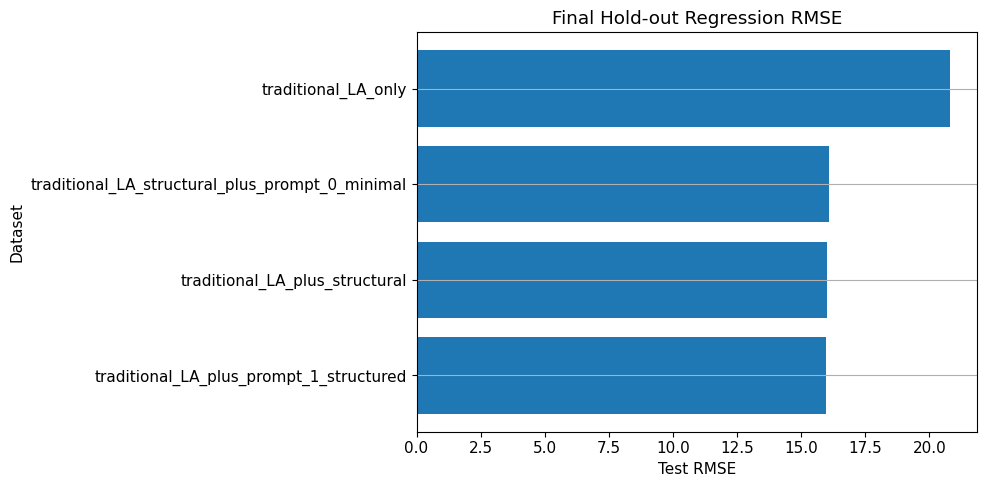

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/final_holdout_regression_rmse.png


In [186]:
# Plot final regression RMSE
plot_df = final_regression_holdout_results.sort_values(
    "test_rmse",
    ascending=True
)

plt.figure(figsize=(10, 5))

plt.barh(
    plot_df["dataset"],
    plot_df["test_rmse"]
)

plt.xlabel("Test RMSE")
plt.ylabel("Dataset")
plt.title("Final Hold-out Regression RMSE")
plt.grid(axis="x")
plt.tight_layout()

figure_path = FIGURES_DIR / "final_holdout_regression_rmse.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

### 13.4 Final hold-out classification results

The selected classification candidates are trained on the full training set and evaluated on the hold-out test set.

This gives the final estimate of how well each feature block identifies passing and failing students.

In [187]:
# Evaluate selected classification candidates on hold-out test
final_classification_holdout_rows = []

for _, row in final_classification_candidates.iterrows():
    result = evaluate_classification_holdout(
        dataset_name=row["dataset"],
        model_name=row["model"]
    )
    
    final_classification_holdout_rows.append(result)

final_classification_holdout_results = pd.DataFrame(final_classification_holdout_rows)

final_classification_holdout_results = final_classification_holdout_results.sort_values(
    "test_auc",
    ascending=False
).reset_index(drop=True)

final_classification_holdout_results

,dataset,model,n_features,test_auc,test_accuracy,test_precision,test_recall,test_f1
0,traditional_LA_plus_structural,Random Forest,156,0.8899,0.8039,0.8000,0.8302,0.8148
1,traditional_LA_structural_plus_prompt_1_struct...,Random Forest,210,0.8816,0.7843,0.8039,0.7736,0.7885
2,traditional_LA_only,SVC,48,0.8787,0.8137,0.8269,0.8113,0.8190
3,traditional_LA_plus_prompt_0_minimal,SVC,102,0.8610,0.8333,0.8214,0.8679,0.8440


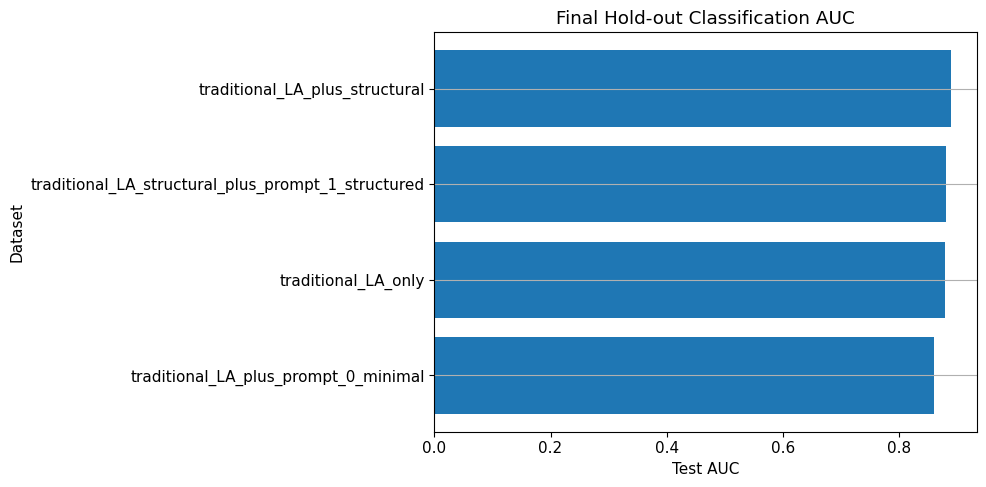

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/final_holdout_classification_auc.png


In [188]:
# Plot final classification AUC
plot_df = final_classification_holdout_results.sort_values(
    "test_auc",
    ascending=True
)

plt.figure(figsize=(10, 5))

plt.barh(
    plot_df["dataset"],
    plot_df["test_auc"]
)

plt.xlabel("Test AUC")
plt.ylabel("Dataset")
plt.title("Final Hold-out Classification AUC")
plt.grid(axis="x")
plt.tight_layout()

figure_path = FIGURES_DIR / "final_holdout_classification_auc.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

### 13.5 Confusion matrix for the best classification model

The confusion matrix shows how the best final classification model performs on the hold-out test set.

It separates the predictions into:

- True negatives: failing students correctly predicted as fail.
- False positives: failing students predicted as pass.
- False negatives: passing students predicted as fail.
- True positives: passing students correctly predicted as pass.

In [190]:
from sklearn.metrics import confusion_matrix

# Best classification model on hold-out test
best_final_classification = final_classification_holdout_results.iloc[0]

best_classification_dataset = best_final_classification["dataset"]
best_classification_model_name = best_final_classification["model"]

df_train = modelling_datasets_train[best_classification_dataset]
df_test = modelling_datasets_test[best_classification_dataset]

feature_cols = modelling_feature_sets[best_classification_dataset]

X_train, y_train = prepare_X_y(df_train, feature_cols, CLASSIFICATION_TARGET)
X_test, y_test = prepare_X_y(df_test, feature_cols, CLASSIFICATION_TARGET)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

best_classification_model = clone(
    classification_models[best_classification_model_name]
)

best_classification_model.fit(X_train, y_train)

y_test_pred = best_classification_model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_test_pred)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual Fail", "Actual Pass"],
    columns=["Predicted Fail", "Predicted Pass"]
)

conf_matrix_df

,Predicted Fail,Predicted Pass
Actual Fail,38,11
Actual Pass,9,44


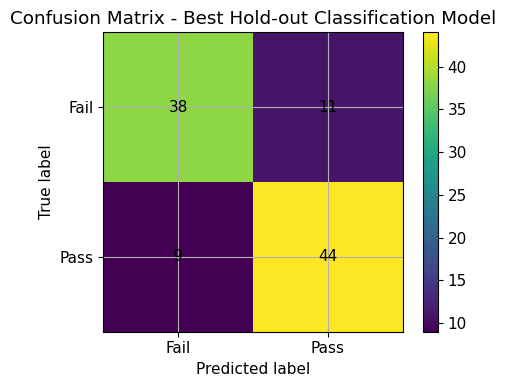

Figure saved in: /Users/martaaznar__/Documents/GitHub/TFM-Marta/outputs/figures/final_holdout_confusion_matrix.png


In [191]:
# Plot confusion matrix
plt.figure(figsize=(5, 4))

plt.imshow(conf_matrix)
plt.title("Confusion Matrix - Best Hold-out Classification Model")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ["Fail", "Pass"])
plt.yticks([0, 1], ["Fail", "Pass"])

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()

figure_path = FIGURES_DIR / "final_holdout_confusion_matrix.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved in: {figure_path}")

The confusion matrix shows that the best hold-out classification model correctly predicts most students in both classes.

The model correctly identifies 38 failing students and 44 passing students. It makes 20 errors in total: 11 failing students are predicted as passing, and 9 passing students are predicted as failing.

This indicates that the model is relatively balanced. It performs well at detecting passing students, while also keeping a reasonable ability to identify students who fail. The presence of both false positives and false negatives shows that the task is not trivial, but the model generalises well to unseen students.

### 13.6 Comparison between cross-validation and hold-out results

The final step compares the training cross-validation results with the hold-out test results.

This helps check whether the selected models generalise well or whether their cross-validation performance was too optimistic.

In [192]:
# Regression: compare train CV and hold-out test
regression_cv_vs_test = final_regression_candidates[
    ["dataset", "model", "rmse_mean", "r2_mean", "mae_mean"]
].merge(
    final_regression_holdout_results,
    on=["dataset", "model"],
    how="left"
)

regression_cv_vs_test["rmse_test_minus_cv"] = (
    regression_cv_vs_test["test_rmse"] - regression_cv_vs_test["rmse_mean"]
)

regression_cv_vs_test["mae_test_minus_cv"] = (
    regression_cv_vs_test["test_mae"] - regression_cv_vs_test["mae_mean"]
)

regression_cv_vs_test = regression_cv_vs_test.sort_values(
    "test_rmse",
    ascending=True
)

regression_cv_vs_test

,dataset,model,rmse_mean,r2_mean,mae_mean,n_features,test_r2,test_mae,test_rmse,rmse_test_minus_cv,mae_test_minus_cv
2,traditional_LA_plus_prompt_1_structured,Random Forest,15.7854,0.3319,12.2043,102,0.4224,11.3961,15.9575,0.1721,-0.8082
1,traditional_LA_plus_structural,Random Forest,15.8395,0.3272,12.1997,156,0.4204,11.3300,15.9853,0.1458,-0.8697
3,traditional_LA_structural_plus_prompt_0_minimal,Random Forest,15.8062,0.3299,12.1904,210,0.4147,11.2064,16.0634,0.2573,-0.9840
0,traditional_LA_only,Ridge,15.4071,0.3611,12.3726,48,0.0176,12.6023,20.8116,5.4046,0.2297


In [193]:
# Classification: compare train CV and hold-out test
classification_cv_vs_test = final_classification_candidates[
    ["dataset", "model", "auc_mean", "accuracy_mean", "f1_mean"]
].merge(
    final_classification_holdout_results,
    on=["dataset", "model"],
    how="left"
)

classification_cv_vs_test["auc_test_minus_cv"] = (
    classification_cv_vs_test["test_auc"] - classification_cv_vs_test["auc_mean"]
)

classification_cv_vs_test["f1_test_minus_cv"] = (
    classification_cv_vs_test["test_f1"] - classification_cv_vs_test["f1_mean"]
)

classification_cv_vs_test = classification_cv_vs_test.sort_values(
    "test_auc",
    ascending=False
)

classification_cv_vs_test

,dataset,model,auc_mean,accuracy_mean,f1_mean,n_features,test_auc,test_accuracy,test_precision,test_recall,test_f1,auc_test_minus_cv,f1_test_minus_cv
1,traditional_LA_plus_structural,Random Forest,0.8128,0.7624,0.7654,156,0.8899,0.8039,0.8000,0.8302,0.8148,0.0770,0.0494
3,traditional_LA_structural_plus_prompt_1_struct...,Random Forest,0.8149,0.7516,0.7544,210,0.8816,0.7843,0.8039,0.7736,0.7885,0.0667,0.0341
0,traditional_LA_only,SVC,0.8139,0.7450,0.7573,48,0.8787,0.8137,0.8269,0.8113,0.8190,0.0648,0.0618
2,traditional_LA_plus_prompt_0_minimal,SVC,0.8050,0.7458,0.7570,102,0.8610,0.8333,0.8214,0.8679,0.8440,0.0560,0.0870


In [194]:
# Save final hold-out validation outputs
final_regression_candidates.to_csv(
    TABLES_DIR / "final_regression_candidates_train_cv.csv",
    index=False
)

final_classification_candidates.to_csv(
    TABLES_DIR / "final_classification_candidates_train_cv.csv",
    index=False
)

final_regression_holdout_results.to_csv(
    TABLES_DIR / "final_regression_holdout_results.csv",
    index=False
)

final_classification_holdout_results.to_csv(
    TABLES_DIR / "final_classification_holdout_results.csv",
    index=False
)

regression_cv_vs_test.to_csv(
    TABLES_DIR / "regression_cv_vs_holdout_test.csv",
    index=False
)

classification_cv_vs_test.to_csv(
    TABLES_DIR / "classification_cv_vs_holdout_test.csv",
    index=False
)

conf_matrix_df.to_csv(
    TABLES_DIR / "final_holdout_confusion_matrix.csv"
)

print("Final hold-out validation results saved.")

Final hold-out validation results saved.


## Appendix. Final extended feature-block comparison

This appendix reports the final comparison across all feature blocks considered in the study, including the original Learning Analytics blocks, the structural code features, the LLM-based features for each prompt, and the standalone structural-only and LLM-only configurations.  

For cross-validation, results are reported as mean +- standard deviation across folds. Hold-out results correspond to the final evaluation on the reserved test set.

In [ ]:
# Appendix table: final extended results

from pathlib import Path
import pandas as pd
import numpy as np

TABLES_DIR = Path("outputs/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)


# 1. Load final all-prompt comparison tables

def load_results_table(variable_name, file_name):
    """
    Load a results table either from memory or from outputs/tables.
    This keeps the appendix cell clean and avoids recalculating models.
    """
    file_path = TABLES_DIR / file_name
    
    if variable_name in globals():
        return globals()[variable_name].copy()
    
    if file_path.exists():
        return pd.read_csv(file_path)
    
    raise FileNotFoundError(
        f"Could not find {file_name}. "
        "Run the final all-prompt validation cell once before this appendix table."
    )


regression_results_full = load_results_table(
    variable_name="regression_cv_vs_holdout_all_prompts",
    file_name="regression_cv_vs_holdout_all_prompts_with_standalone.csv"
)

classification_results_full = load_results_table(
    variable_name="classification_cv_vs_holdout_all_prompts",
    file_name="classification_cv_vs_holdout_all_prompts_with_standalone.csv"
)


# 2. Helper functions

def mean_pm_std(mean_value, std_value, decimals=3):
    """
    Format cross-validation results as mean ± standard deviation.
    """
    if pd.isna(mean_value) or pd.isna(std_value):
        return np.nan
    
    return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"


def clean_prompt_name(prompt):
    """
    Make prompt labels easier to read in the final appendix tables.
    """
    if pd.isna(prompt) or prompt == "no_prompt":
        return "-"
    return prompt


# 3. Compact regression table

appendix_regression_table = regression_results_full.copy()

appendix_regression_table["Prompt"] = appendix_regression_table["prompt_name"].apply(
    clean_prompt_name
)

appendix_regression_table["CV RMSE"] = appendix_regression_table.apply(
    lambda row: mean_pm_std(row["rmse_mean"], row["rmse_std"]),
    axis=1
)

appendix_regression_table["CV R2"] = appendix_regression_table.apply(
    lambda row: mean_pm_std(row["r2_mean"], row["r2_std"]),
    axis=1
)

appendix_regression_table["CV MAE"] = appendix_regression_table.apply(
    lambda row: mean_pm_std(row["mae_mean"], row["mae_std"]),
    axis=1
)

appendix_regression_table = appendix_regression_table.rename(columns={
    "feature_block": "Feature block",
    "model": "Best model",
    "n_features": "N features",
    "test_rmse": "Hold-out RMSE",
    "test_r2": "Hold-out R2",
    "test_mae": "Hold-out MAE"
})

appendix_regression_table = appendix_regression_table[
    [
        "Feature block",
        "Prompt",
        "Best model",
        "N features",
        "CV RMSE",
        "Hold-out RMSE",
        "CV R2",
        "Hold-out R2",
        "CV MAE",
        "Hold-out MAE"
    ]
].copy()

appendix_regression_table = appendix_regression_table.round({
    "Hold-out RMSE": 3,
    "Hold-out R2": 3,
    "Hold-out MAE": 3
})


# 4. Compact classification table

appendix_classification_table = classification_results_full.copy()

appendix_classification_table["Prompt"] = appendix_classification_table["prompt_name"].apply(
    clean_prompt_name
)

appendix_classification_table["CV AUC"] = appendix_classification_table.apply(
    lambda row: mean_pm_std(row["auc_mean"], row["auc_std"]),
    axis=1
)

appendix_classification_table["CV Accuracy"] = appendix_classification_table.apply(
    lambda row: mean_pm_std(row["accuracy_mean"], row["accuracy_std"]),
    axis=1
)

appendix_classification_table["CV F1"] = appendix_classification_table.apply(
    lambda row: mean_pm_std(row["f1_mean"], row["f1_std"]),
    axis=1
)

appendix_classification_table = appendix_classification_table.rename(columns={
    "feature_block": "Feature block",
    "model": "Best model",
    "n_features": "N features",
    "test_auc": "Hold-out AUC",
    "test_accuracy": "Hold-out Accuracy",
    "test_f1": "Hold-out F1"
})

appendix_classification_table = appendix_classification_table[
    [
        "Feature block",
        "Prompt",
        "Best model",
        "N features",
        "CV AUC",
        "Hold-out AUC",
        "CV Accuracy",
        "Hold-out Accuracy",
        "CV F1",
        "Hold-out F1"
    ]
].copy()

appendix_classification_table = appendix_classification_table.round({
    "Hold-out AUC": 3,
    "Hold-out Accuracy": 3,
    "Hold-out F1": 3
})


# 5. Save and display final appendix tables

appendix_regression_table.to_csv(
    TABLES_DIR / "appendix_final_regression_results.csv",
    index=False
)

appendix_classification_table.to_csv(
    TABLES_DIR / "appendix_final_classification_results.csv",
    index=False
)

print("Appendix regression table")
display(appendix_regression_table)

print("Appendix classification table")
display(appendix_classification_table)

print("\nSaved files:")
print(TABLES_DIR / "appendix_final_regression_results.csv")
print(TABLES_DIR / "appendix_final_classification_results.csv")

Appendix regression table


,Feature block,Prompt,Best model,N features,CV RMSE,Hold-out RMSE,CV R2,Hold-out R2,CV MAE,Hold-out MAE
0,Traditional LA only,-,Ridge,48,15.407 ± 1.504,20.812,0.361 ± 0.106,0.018,12.373 ± 1.110,12.602
1,Traditional LA + Structural,-,Random Forest,156,15.840 ± 1.229,15.985,0.327 ± 0.079,0.420,12.200 ± 0.924,11.330
2,Traditional LA + LLM,prompt_0_minimal,Gradient Boosting,102,15.810 ± 1.357,16.759,0.329 ± 0.087,0.363,12.476 ± 1.012,11.696
3,Traditional LA + LLM,prompt_1_structured,Random Forest,102,15.785 ± 1.327,15.957,0.332 ± 0.082,0.422,12.204 ± 1.088,11.396
4,Traditional LA + LLM,prompt_2_rubric,Random Forest,102,15.898 ± 1.378,15.921,0.323 ± 0.081,0.425,12.301 ± 1.118,11.411
5,Traditional LA + Structural + LLM,prompt_0_minimal,Random Forest,210,15.806 ± 1.247,16.063,0.330 ± 0.081,0.415,12.190 ± 0.935,11.206
6,Traditional LA + Structural + LLM,prompt_1_structured,Random Forest,210,15.836 ± 1.223,16.083,0.327 ± 0.082,0.413,12.211 ± 0.877,11.393
7,Traditional LA + Structural + LLM,prompt_2_rubric,Random Forest,210,15.836 ± 1.233,16.059,0.327 ± 0.082,0.415,12.207 ± 0.883,11.389
8,Structural only,-,Random Forest,108,16.480 ± 1.246,16.273,0.270 ± 0.096,0.399,12.685 ± 0.841,11.625
9,LLM only,prompt_0_minimal,Random Forest,54,18.185 ± 1.391,20.561,0.112 ± 0.121,0.041,14.297 ± 1.131,14.586


Appendix classification table


,Feature block,Prompt,Best model,N features,CV AUC,Hold-out AUC,CV Accuracy,Hold-out Accuracy,CV F1,Hold-out F1
0,Traditional LA only,-,SVC,48,0.814 ± 0.049,0.879,0.745 ± 0.047,0.814,0.757 ± 0.044,0.819
1,Traditional LA + Structural,-,Random Forest,156,0.813 ± 0.053,0.890,0.762 ± 0.054,0.804,0.765 ± 0.060,0.815
2,Traditional LA + LLM,prompt_0_minimal,SVC,102,0.805 ± 0.050,0.861,0.746 ± 0.052,0.833,0.757 ± 0.057,0.844
3,Traditional LA + LLM,prompt_1_structured,Random Forest,102,0.799 ± 0.046,0.866,0.746 ± 0.048,0.794,0.757 ± 0.052,0.796
4,Traditional LA + LLM,prompt_2_rubric,SVC,102,0.800 ± 0.051,0.866,0.719 ± 0.053,0.765,0.726 ± 0.057,0.769
5,Traditional LA + Structural + LLM,prompt_0_minimal,Random Forest,210,0.809 ± 0.051,0.876,0.752 ± 0.050,0.794,0.753 ± 0.060,0.804
6,Traditional LA + Structural + LLM,prompt_1_structured,Random Forest,210,0.815 ± 0.050,0.882,0.752 ± 0.041,0.784,0.754 ± 0.047,0.788
7,Traditional LA + Structural + LLM,prompt_2_rubric,Random Forest,210,0.809 ± 0.053,0.877,0.757 ± 0.049,0.804,0.760 ± 0.057,0.811
8,Structural only,-,SVC,108,0.785 ± 0.051,0.826,0.715 ± 0.056,0.755,0.722 ± 0.061,0.775
9,LLM only,prompt_0_minimal,SVC,54,0.692 ± 0.047,0.713,0.639 ± 0.056,0.676,0.656 ± 0.073,0.703



Saved files:
outputs/tables/appendix_final_regression_results.csv
outputs/tables/appendix_final_classification_results.csv


## Appendix. Descriptive summary of the final grade

This appendix also reports a brief descriptive summary of the final grade variable, `X-Grade`, used as the regression target. The mean is calculated at student level using the main modelling table.

In [ ]:
# Appendix table: descriptive summary of X-Grade

from pathlib import Path
import pandas as pd

TABLES_DIR = Path("outputs/tables")


# 1. Load main student-level table

candidate_paths = [
    TABLES_DIR / "student_traditional_la_features.csv",
    TABLES_DIR / "student_la_plus_structural_features.csv",
    TABLES_DIR / "main_table.csv",
    TABLES_DIR / "student_main_table.csv",
    TABLES_DIR / "final_student_table.csv"
]

main_table = None
main_table_path = None

for path in candidate_paths:
    if path.exists():
        candidate = pd.read_csv(path)
        if "X-Grade" in candidate.columns:
            main_table = candidate.copy()
            main_table_path = path
            break

if main_table is None:
    raise FileNotFoundError(
        "No saved student-level table with an 'X-Grade' column was found."
    )


# 2. Calculate descriptive summary

xgrade_summary = pd.DataFrame({
    "table_used": [main_table_path.name],
    "target_variable": ["X-Grade"],
    "n_students": [main_table["X-Grade"].notna().sum()],
    "mean": [main_table["X-Grade"].mean()],
    "standard_deviation": [main_table["X-Grade"].std()],
    "minimum": [main_table["X-Grade"].min()],
    "maximum": [main_table["X-Grade"].max()]
})

xgrade_summary = xgrade_summary.round({
    "mean": 3,
    "standard_deviation": 3,
    "minimum": 3,
    "maximum": 3
})


# 3. Save and display

xgrade_summary.to_csv(
    TABLES_DIR / "appendix_xgrade_descriptive_summary.csv",
    index=False
)

display(xgrade_summary)

print(f"Mean X-Grade: {xgrade_summary.loc[0, 'mean']:.3f}")
print(f"Saved file: {TABLES_DIR / 'appendix_xgrade_descriptive_summary.csv'}")

,table_used,target_variable,n_students,mean,standard_deviation,minimum,maximum
0,student_traditional_la_features.csv,X-Grade,506,60.577,19.886,0.0,100.0


Mean X-Grade: 60.577
Saved file: outputs/tables/appendix_xgrade_descriptive_summary.csv
